# Inférence statistique

## Auto-ML

pycaret ne supporte pas encore officiellement Python 3.14.3 donc on utilise à la place le package flaml

In [35]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from flaml import AutoML

In [36]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test = pd.read_csv("../data_finale/featuring/test_featured.csv")

In [37]:
colonne_cible = "market_value_in_eur"
colonne_joueur = "player"
colonne_team = "team"
colonne_nation = "nation"

df_train = df_train.dropna(subset=[colonne_cible])
df_val = df_val.dropna(subset=[colonne_cible])
df_test = df_test.dropna(subset=[colonne_cible])

# Séparation des features et de la variable cible
joueurs_test = df_test[colonne_joueur]

# On supprime les colonnes texte et la cible pour l'entraînement
X_train = df_train.drop(columns=[colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position",
                                 "market_value_in_eur_nor"])
y_train = df_train[colonne_cible]

X_val = df_val.drop(columns=[colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position",
                                 "market_value_in_eur_nor"])
y_val = df_val[colonne_cible]

X_test = df_test.drop(columns=[colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position",
                                 "market_value_in_eur_nor"])
y_test = df_test[colonne_cible]

In [ ]:
print("--- Entraînement FLAML ---")
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task="regression",
    metric="mae",
    time_budget=300,  # 5 minutes pour FLAML
    estimator_list=["xgboost", "lgbm", "catboost", "rf", "extra_tree", "kneighbor", "enet", "lassolars"],
    seed=1308
)

# Récupération des meilleures prédictions de FLAML
preds_flaml = automl.predict(X_test)
mae_flaml = mean_absolute_error(y_test, preds_flaml)


# Préparation : Sélection dynamique des colonnes sans aucun NaN

# On ne garde que les colonnes où la somme des NaN est égale à 0
colonnes_sans_nan = X_train.columns[X_train.isna().sum() == 0].tolist()

print(f"Filtrage pour les modèles linéaires/SVR :")
print(f" -> {len(colonnes_sans_nan)} colonnes conservées sur {X_train.shape[1]} (0 NaN).")

# Création des sous-ensembles spécifiques "propres"
X_train_sans_nan = X_train[colonnes_sans_nan]
X_test_sans_nan = X_test[colonnes_sans_nan]


print("\n--- Entraînement SVR ---")

# Plus besoin d'imputeur ! On garde juste le StandardScaler (vital pour le SVR)
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# Ajustement de la grille (préfixe svr__ nécessaire à cause du Pipeline)
param_svr = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__kernel': ['rbf', 'linear'],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

grid_svr = GridSearchCV(svr_pipeline, param_svr, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
# On entraîne sur les colonnes sans NaN
grid_svr.fit(X_train_sans_nan, y_train)

preds_svr = grid_svr.predict(X_test_sans_nan)
mae_svr = mean_absolute_error(y_test, preds_svr)


print("--- Entraînement Régression Linéaire ---")

# Optionnel mais recommandé : Mettre un StandardScaler ici aussi si vous utilisez 
# des variables aux échelles très différentes, ou laisser LinearRegression brute.
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# On entraîne également sur les colonnes sans NaN
lr_pipeline.fit(X_train_sans_nan, y_train)

preds_lr = lr_pipeline.predict(X_test_sans_nan)
mae_lr = mean_absolute_error(y_test, preds_lr)



print("\nComparaison des performences (MAE)")
print(f"FLAML : {mae_flaml:,.0f} € (Modèle : {automl.best_estimator})")
print(f"SVR (Optimisé par GridSearch)        : {mae_svr:,.0f} €")
print(f"Régression Linéaire Multiple         : {mae_lr:,.0f} €")

# Trouver le grand gagnant
resultats = {
    "FLAML": (mae_flaml, preds_flaml),
    "SVR": (mae_svr, preds_svr),
    "LinearRegression": (mae_lr, preds_lr)
}
meilleur_approche = min(resultats, key=lambda k: resultats[k][0])
print(f"\nLe meilleur choix final est : {meilleur_approche}")

--- Entraînement FLAML ---
[flaml.automl.logger: 07-01 18:19:07] {2375} INFO - task = regression
[flaml.automl.logger: 07-01 18:19:07] {2383} INFO - Data split method: uniform
[flaml.automl.logger: 07-01 18:19:07] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 07-01 18:19:07] {2489} INFO - Minimizing error metric: mae
[flaml.automl.logger: 07-01 18:19:07] {2606} INFO - List of ML learners in AutoML Run: ['xgboost', 'lgbm', 'catboost', 'rf', 'extra_tree', 'kneighbor', 'enet', 'lassolars']
[flaml.automl.logger: 07-01 18:19:07] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 07-01 18:19:07] {3046} INFO - Estimated sufficient time budget=1149s. Estimated necessary time budget=4s.
[flaml.automl.logger: 07-01 18:19:07] {3097} INFO -  at 0.5s,	estimator xgboost's best error=9.5835e+06,	best estimator xgboost's best error=9.5835e+06
[flaml.automl.logger: 07-01 18:19:07] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-01 18:19:08

In [ ]:
# On extrait le meilleur estimateur trouvé par FLAML
meilleur_modele = automl.model.estimator

# On affiche le nom du modèle pour savoir qui a gagné
print(f"Meilleur modèle trouvé : {type(meilleur_modele).__name__}\n")

# On extrait les hyperparamètres de manière sûre
print("Hyperparamètres finaux :")
if hasattr(meilleur_modele, 'get_all_params'):
    # Si c'est vraiment un CatBoost
    print(meilleur_modele.get_all_params())
else:
    # Si c'est XGBoost, LightGBM ou un autre modèle scikit-learn
    print(meilleur_modele.get_params())

Meilleur modèle trouvé : XGBRegressor

Hyperparamètres finaux :
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': [], 'colsample_bylevel': 1.0, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': 'lossguide', 'importance_type': None, 'interaction_constraints': None, 'learning_rate': np.float64(0.047039577299965676), 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 0, 'max_leaves': 43, 'min_child_weight': np.float64(4.791541868873825), 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 810, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(1.547191718086146), 'sampling_method': None, 'scale_pos_weight': None, 'subsample': np.fl

## Premiers tests de modélisation

In [ ]:
modeles = {
    
    # Forêts (On garde une bonne profondeur)
    "Random Forest": RandomForestRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),
    "Extra Trees": ExtraTreesRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),
    
    # Boosting (Alignés sur la stratégie gagnante de FLAML)
    "XGBoost": XGBRegressor(
    random_state=1308,
    n_jobs=-1,
    
    # Paramètres de structure ajustés par FLAML
    tree_method='hist',
    grow_policy='lossguide',
    max_depth=0,                # Aucune limite de profondeur
    max_leaves=43,              # car on contrôle la complexité par le nombre de feuilles
    enable_categorical=True,    
    
    # Paramètres de régularisation optimisés
    min_child_weight=4.791541868873825,
    subsample=0.7386565774212087,
    reg_alpha=0.0009765625,
    reg_lambda=1.547191718086146,
    
    # Stratégie d'apprentissage
    learning_rate=0.01,         # Plus bas et robuste
    n_estimators=3800,          # Augmenté proportionnellement pour compenser la baisse du learning rate
    
    # Paramètres généraux
    objective='reg:squarederror',
    verbosity=0
),
    "LightGBM": LGBMRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=3000,       # Les arbres de LightGBM sont très rapides à construire
        learning_rate=0.01,
        max_depth=6,
        verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=1308,
        iterations=8192,
        learning_rate=0.005,
        depth=6,
        l2_leaf_reg=3,
        subsample=0.8,
        early_stopping_rounds=100,
        verbose=0                 
    ),
}

In [ ]:
# Entraînement puis évaluation
resultats = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    
    # Entraînement sur le jeu de train uniquement
    modele.fit(X_train, y_train)
    
    # Prédictions
    preds_val = modele.predict(X_val)
    
    mae_val = mean_absolute_error(y_val, preds_val)
    r2_val = r2_score(y_val, preds_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, preds_val))
    mape_val = mean_absolute_percentage_error(y_val, preds_val)

    # R² Ajusté
    n = len(y_val)          # Nombre d'observations
    p = X_val.shape[1]      # Nombre de variables (colonnes)
    r2_ajuste_val = 1 - (1 - r2_val) * (n - 1) / (n - p - 1)
    
    # Sauvegarde pour le tableau final
    resultats[nom] = {
        "MAE Val": mae_val,
        "RMSE Val": rmse_val,
        "MAPE Val": mape_val,
        "R² Val": r2_val,
        "R² Ajusté Val": r2_ajuste_val
    }
    
    print(f"   -> Validation | MAE : {mae_val:,.0f} € | RMSE : {rmse_val:,.0f} € | MAPE : {mape_val:.2%} | R² : {r2_val:.2%} | R² Ajusté : {r2_ajuste_val:.2%}" )

# Comparaion des modèles
print("CLASSEMENT FINAL (Trié par la plus petite erreur sur test)")
tableau_resultats = []
for nom, metrics in resultats.items():
    tableau_resultats.append({
        "Modèle": nom,
        "Erreur moyenne Val (MAE)": f"{metrics['MAE Val']:,.0f} €",
        "Score R² Val": f"{metrics['R² Val']:.2%}",
        "Score R² Ajusté Val": f"{metrics['R² Ajusté Val']:.2%}"
    })

# En régression, le meilleur modèle est celui avec la MAE la plus basse
df_final = pd.DataFrame(tableau_resultats).sort_values(by="Erreur moyenne Val (MAE)", ascending=True)
print(df_final.to_string(index=False))

Entraînement de Random Forest...
   -> Validation | MAE : 5,040,843 € | RMSE : 9,713,330 € | MAPE : 89.33% | R² : 70.90%
Entraînement de Extra Trees...
   -> Validation | MAE : 4,983,436 € | RMSE : 9,540,966 € | MAPE : 91.67% | R² : 71.92%
Entraînement de XGBoost...
   -> Validation | MAE : 4,612,237 € | RMSE : 8,945,683 € | MAPE : 81.67% | R² : 75.31%
Entraînement de LightGBM...
   -> Validation | MAE : 4,782,923 € | RMSE : 9,010,973 € | MAPE : 88.97% | R² : 74.95%
Entraînement de CatBoost...
   -> Validation | MAE : 4,659,503 € | RMSE : 8,835,834 € | MAPE : 91.54% | R² : 75.92%
CLASSEMENT FINAL (Trié par la plus petite erreur sur test)
       Modèle Erreur moyenne Val (MAE) Score R² Val
      XGBoost              4,612,237 €       75.31%
     CatBoost              4,659,503 €       75.92%
     LightGBM              4,782,923 €       74.95%
  Extra Trees              4,983,436 €       71.92%
Random Forest              5,040,843 €       70.90%


In [ ]:
# Entraînement puis évaluation
resultats = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    
    # Entraînement sur le jeu de train uniquement
    modele.fit(X_train, y_train)
    
    # Prédictions
    preds_test = modele.predict(X_test)
    
    mae_test = mean_absolute_error(y_test, preds_test)
    r2_test = r2_score(y_test, preds_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    mape_test = mean_absolute_percentage_error(y_test, preds_test)

    # R² Ajusté
    n = len(y_test)          # Nombre d'observations
    p = X_test.shape[1]      # Nombre de variables (colonnes)
    r2_ajuste_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
    
    # Sauvegarde pour le tableau final
    resultats[nom] = {
        "MAE Test": mae_test,
        "R² Test": r2_test,
        "MAPE Test": mape_test,
        "R² Test": r2_test,
        "R² Ajusté Test": r2_ajuste_test
    }
    
    print(f"   -> Test | MAE : {mae_test:,.0f} € | RMSE : {rmse_test:,.0f} € | MAPE : {mape_test:.2%} | R² : {r2_test:.2%} | R² Ajusté : {r2_ajuste_test:.2%}" )

# Comparaion des modèles
print("CLASSEMENT FINAL (Trié par la plus petite erreur sur test)")
tableau_resultats = []
for nom, metrics in resultats.items():
    tableau_resultats.append({
        "Modèle": nom,
        "Erreur moyenne Test (MAE)": f"{metrics['MAE Test']:,.0f} €",
        "Score R² Test": f"{metrics['R² Test']:.2%}",
        "Score R² Ajusté Test": f"{metrics['R² Ajusté Test']:.2%}"
    })

# En régression, le meilleur modèle est celui avec la MAE la plus basse
df_final = pd.DataFrame(tableau_resultats).sort_values(by="Erreur moyenne Test (MAE)", ascending=True)
print(df_final.to_string(index=False))

Entraînement de Random Forest...
   -> Test | MAE : 5,378,551 € | RMSE : 10,630,318 € | MAPE : 80.18% | R² : 67.69% | R² Ajusté : 65.18%
Entraînement de Extra Trees...
   -> Test | MAE : 5,331,168 € | RMSE : 10,490,978 € | MAPE : 83.06% | R² : 68.53% | R² Ajusté : 66.08%
Entraînement de XGBoost...
   -> Test | MAE : 4,977,951 € | RMSE : 9,748,343 € | MAPE : 77.20% | R² : 72.83% | R² Ajusté : 70.72%
Entraînement de LightGBM...
   -> Test | MAE : 5,073,985 € | RMSE : 9,701,387 € | MAPE : 79.53% | R² : 73.09% | R² Ajusté : 71.00%
Entraînement de CatBoost...
   -> Test | MAE : 5,062,656 € | RMSE : 9,765,905 € | MAPE : 78.63% | R² : 72.73% | R² Ajusté : 70.61%
CLASSEMENT FINAL (Trié par la plus petite erreur sur test)
       Modèle Erreur moyenne Test (MAE) Score R² Test Score R² Ajusté Test
      XGBoost               4,977,951 €        72.83%               70.72%
     CatBoost               5,062,656 €        72.73%               70.61%
     LightGBM               5,073,985 €        73.09

## Tuning des hyperparamètres (Optuna)

On cherche, pour chaque modèle, les hyperparamètres qui **minimisent le MAE sur le jeu de validation** (`X_val` / `y_val`). Le jeu de **test reste intouché** pendant tout le tuning : il ne sert qu'à l'évaluation finale, une seule fois, pour ne pas biaiser l'estimation de la performance réelle.

On utilise [Optuna](https://optuna.org/) (recherche bayésienne / TPE), beaucoup plus efficace qu'un `GridSearchCV` classique pour ce genre d'espaces de recherche (moins d'essais nécessaires pour un résultat équivalent ou meilleur).

In [ ]:
# Installation si nécessaire (à décommenter la première fois)
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 40          # nombre d'essais par modèle : augmentez si vous avez du temps (ex: 100-200)
RANDOM_STATE = 1308

# Sous-ensemble sans NaN pour la validation (nécessaire pour SVR / modèles linéaires)
X_val_sans_nan = X_val[colonnes_sans_nan]


In [ ]:
def tune_forest(model_class, trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning Random Forest ---")
study_rf = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(lambda t: tune_forest(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_rf.best_value)
print("Meilleurs paramètres :", study_rf.best_params)

print("\n--- Tuning Extra Trees ---")
study_et = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et.optimize(lambda t: tune_forest(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_et.best_value)
print("Meilleurs paramètres :", study_et.best_params)


--- Tuning Random Forest ---


Best trial: 34. Best value: 5.00757e+06: 100%|██████████| 40/40 [10:28<00:00, 15.70s/it]


Meilleur MAE : 5007569.87509529
Meilleurs paramètres : {'n_estimators': 1000, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.8}

--- Tuning Extra Trees ---


Best trial: 36. Best value: 4.94011e+06: 100%|██████████| 40/40 [08:29<00:00, 12.74s/it]

Meilleur MAE : 4940109.586605793
Meilleurs paramètres : {'n_estimators': 1000, 'max_depth': 36, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 1.0}


In [ ]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method": "hist",
        "enable_categorical": True,
        "objective": "reg:squarederror",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning XGBoost ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_xgb.best_value)
print("Meilleurs paramètres :", study_xgb.best_params)


--- Tuning XGBoost ---


Best trial: 33. Best value: 4.61382e+06: 100%|██████████| 40/40 [20:31<00:00, 30.79s/it]

Meilleur MAE : 4613818.206812449
Meilleurs paramètres : {'n_estimators': 1750, 'max_depth': 10, 'learning_rate': 0.008495483131938328, 'subsample': 0.5134049773318177, 'colsample_bytree': 0.6522655023903593, 'min_child_weight': 9.375693632459882, 'reg_alpha': 0.028715173071664254, 'reg_lambda': 0.016463364302549705}


In [ ]:
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning LightGBM ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_lgbm.best_value)
print("Meilleurs paramètres :", study_lgbm.best_params)


--- Tuning LightGBM ---


Best trial: 30. Best value: 4.68754e+06: 100%|██████████| 40/40 [06:26<00:00,  9.66s/it]

Meilleur MAE : 4687541.175203909
Meilleurs paramètres : {'n_estimators': 1250, 'num_leaves': 55, 'max_depth': 15, 'learning_rate': 0.01576832194916594, 'subsample': 0.9746109641661995, 'colsample_bytree': 0.6363035291373982, 'reg_alpha': 0.0702478621553085, 'reg_lambda': 0.002020284753715106}


In [ ]:
def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 1000, 10000, step=500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type": "Bernoulli",   # nécessaire pour pouvoir utiliser 'subsample'
        "random_state": RANDOM_STATE,
        "early_stopping_rounds": 100,
        "verbose": 0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning CatBoost ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_cat.best_value)
print("Meilleurs paramètres :", study_cat.best_params)


--- Tuning CatBoost ---


Best trial: 35. Best value: 4.5644e+06: 100%|██████████| 40/40 [1:07:12<00:00, 100.81s/it] 

Meilleur MAE : 4564400.014541649
Meilleurs paramètres : {'iterations': 3500, 'depth': 7, 'learning_rate': 0.021674111348623584, 'l2_leaf_reg': 1.5396241332040423, 'subsample': 0.8069489117199329}


In [ ]:
from sklearn.linear_model import ElasticNet

def objective_svr(trial):
    params = {
        "C": trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return mean_absolute_error(y_val, preds)

print("--- Tuning SVR ---")
study_svr = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr.optimize(objective_svr, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_svr.best_value)
print("Meilleurs paramètres :", study_svr.best_params)


def objective_enet(trial):
    params = {
        "alpha": trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter": 10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return mean_absolute_error(y_val, preds)

print("\n--- Tuning ElasticNet (remplace la régression linéaire simple, qui n'a pas d'hyperparamètre à tuner) ---")
study_enet = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet.optimize(objective_enet, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_enet.best_value)
print("Meilleurs paramètres :", study_enet.best_params)


--- Tuning SVR ---


Best trial: 15. Best value: 8.5774e+06: 100%|██████████| 40/40 [04:50<00:00,  7.26s/it] 


Meilleur MAE : 8577403.359818045
Meilleurs paramètres : {'C': 99.4615861939721, 'epsilon': 0.02020898211772718, 'kernel': 'linear', 'gamma': 'auto'}

--- Tuning ElasticNet (remplace la régression linéaire simple, qui n'a pas d'hyperparamètre à tuner) ---


Best trial: 11. Best value: 6.5643e+06: 100%|██████████| 40/40 [02:48<00:00,  4.21s/it] 

Meilleur MAE : 6564297.797945763
Meilleurs paramètres : {'alpha': 9.313014897989799, 'l1_ratio': 0.988539726692843}


### Modèles finaux avec hyperparamètres tunés

In [ ]:
modeles_tuned = {
    "Random Forest": RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True,
                             objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli",
                                   random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

# Modèles qui utilisent le sous-ensemble de colonnes sans NaN (SVR, ElasticNet)
modeles_tuned_sans_nan = {
    "SVR": Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr.best_params))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()),
                             ("enet", ElasticNet(**study_enet.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}


In [ ]:
def evaluer(modele, X_tr, y_tr, X_ev, y_ev):
    modele.fit(X_tr, y_tr)
    preds = modele.predict(X_ev)
    mae = mean_absolute_error(y_ev, preds)
    rmse = np.sqrt(mean_squared_error(y_ev, preds))
    mape = mean_absolute_percentage_error(y_ev, preds)
    r2 = r2_score(y_ev, preds)
    n, p = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# --- Évaluation sur la VALIDATION (sert à vérifier le gain du tuning) ---
resultats_tuned_val = {}
for nom, modele in modeles_tuned.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train, y_train, X_val, y_val)

for nom, modele in modeles_tuned_sans_nan.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train_sans_nan, y_train, X_val_sans_nan, y_val)

df_tuned_val = pd.DataFrame(resultats_tuned_val).T.sort_values("MAE")
print("\nCLASSEMENT (Validation, modèles tunés)")
print(df_tuned_val)


Entraînement (tuné) de Random Forest...
Entraînement (tuné) de Extra Trees...
Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...
Entraînement (tuné) de SVR...
Entraînement (tuné) de ElasticNet...

CLASSEMENT (Validation, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       4.560335e+06  8.811370e+06  0.838286  0.760500   0.743030
XGBoost        4.613818e+06  9.003502e+06  0.827792  0.749942   0.731701
LightGBM       4.687541e+06  9.112240e+06  0.820223  0.743865   0.725182
Extra Trees    4.940110e+06  9.510305e+06  0.894550  0.720998   0.700647
Random Forest  5.007570e+06  9.729524e+06  0.886730  0.707988   0.686687
ElasticNet     6.564298e+06  1.122869e+07  2.288003  0.611066   0.585626
SVR            8.577403e+06  1.775098e+07  1.156699  0.028008  -0.035568


In [ ]:
# --- Évaluation finale sur le TEST (à ne lancer qu'une seule fois, à la toute fin) ---
resultats_tuned_test = {}
for nom, modele in modeles_tuned.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train, y_train, X_test, y_test)

for nom, modele in modeles_tuned_sans_nan.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train_sans_nan, y_train, X_test_sans_nan, y_test)

df_tuned_test = pd.DataFrame(resultats_tuned_test).T.sort_values("MAE")
print("CLASSEMENT FINAL (Test, modèles tunés)")
print(df_tuned_test)


CLASSEMENT FINAL (Test, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       4.999971e+06  9.776233e+06  0.766244  0.726734   0.705476
LightGBM       5.029998e+06  9.830999e+06  0.749376  0.723664   0.702167
XGBoost        5.051068e+06  9.913462e+06  0.760559  0.719009   0.697149
Extra Trees    5.280507e+06  1.051981e+07  0.808601  0.683585   0.658969
Random Forest  5.335912e+06  1.066077e+07  0.785867  0.675048   0.649769
ElasticNet     7.198718e+06  1.226207e+07  2.142806  0.570098   0.540123
SVR            9.362710e+06  1.878492e+07  1.112459 -0.008930  -0.079277


## Tuning avec cible transformée (log)

`market_value_in_eur` est presque toujours très asymétrique (beaucoup de joueurs à faible valeur, quelques stars très au-dessus). On entraîne ici les modèles sur `log1p(y)` et on retransforme les prédictions avec `expm1` avant de calculer les métriques (MAE, RMSE, R²...), pour rester comparable en euros avec les résultats précédents.

Le tuning est refait à l'identique (mêmes espaces de recherche, même `N_TRIALS`), mais l'objectif Optuna optimise le MAE en euros **après** retransformation — pas le MAE en log — pour que le choix des hyperparamètres reste piloté par ce qui compte réellement.

In [ ]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)


In [ ]:
def tune_forest_log(model_class, trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning Random Forest (cible log) ---")
study_rf_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf_log.optimize(lambda t: tune_forest_log(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_rf_log.best_value)
print("Meilleurs paramètres :", study_rf_log.best_params)

print("\n--- Tuning Extra Trees (cible log) ---")
study_et_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et_log.optimize(lambda t: tune_forest_log(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_et_log.best_value)
print("Meilleurs paramètres :", study_et_log.best_params)


--- Tuning Random Forest (cible log) ---


Best trial: 36. Best value: 5.09556e+06: 100%|██████████| 40/40 [11:48<00:00, 17.70s/it]


Meilleur MAE : 5095556.471380264
Meilleurs paramètres : {'n_estimators': 1000, 'max_depth': 31, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 1.0}

--- Tuning Extra Trees (cible log) ---


Best trial: 38. Best value: 5.02115e+06: 100%|██████████| 40/40 [04:04<00:00,  6.11s/it]

Meilleur MAE : 5021152.7157317605
Meilleurs paramètres : {'n_estimators': 200, 'max_depth': 31, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0}


In [ ]:
def objective_xgb_log(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method": "hist",
        "enable_categorical": True,
        "objective": "reg:squarederror",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning XGBoost (cible log) ---")
study_xgb_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb_log.optimize(objective_xgb_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_xgb_log.best_value)
print("Meilleurs paramètres :", study_xgb_log.best_params)


--- Tuning XGBoost (cible log) ---


Best trial: 35. Best value: 4.53389e+06: 100%|██████████| 40/40 [15:41<00:00, 23.55s/it]

Meilleur MAE : 4533891.242515702
Meilleurs paramètres : {'n_estimators': 4250, 'max_depth': 5, 'learning_rate': 0.006715152485771444, 'subsample': 0.5041022921725937, 'colsample_bytree': 0.9943717515745149, 'min_child_weight': 7.5333901630105675, 'reg_alpha': 0.012554694452971705, 'reg_lambda': 0.00429351997213069}


In [ ]:
def objective_lgbm_log(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning LightGBM (cible log) ---")
study_lgbm_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm_log.optimize(objective_lgbm_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_lgbm_log.best_value)
print("Meilleurs paramètres :", study_lgbm_log.best_params)


--- Tuning LightGBM (cible log) ---


Best trial: 33. Best value: 4.59537e+06: 100%|██████████| 40/40 [06:04<00:00,  9.12s/it]

Meilleur MAE : 4595366.684714825
Meilleurs paramètres : {'n_estimators': 3000, 'num_leaves': 255, 'max_depth': 5, 'learning_rate': 0.01544411051992505, 'subsample': 0.8903129614370612, 'colsample_bytree': 0.8397297236045178, 'reg_alpha': 0.006350544221335287, 'reg_lambda': 0.0030974009481697295}


In [ ]:
def objective_catboost_log(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 1000, 10000, step=500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type": "Bernoulli",
        "random_state": RANDOM_STATE,
        "early_stopping_rounds": 100,
        "verbose": 0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train_log, eval_set=(X_val, y_val_log), verbose=False)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning CatBoost (cible log) ---")
study_cat_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat_log.optimize(objective_catboost_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_cat_log.best_value)
print("Meilleurs paramètres :", study_cat_log.best_params)


--- Tuning CatBoost (cible log) ---


Best trial: 18. Best value: 4.45128e+06: 100%|██████████| 40/40 [54:59<00:00, 82.49s/it]   

Meilleur MAE : 4451281.472631983
Meilleurs paramètres : {'iterations': 9000, 'depth': 6, 'learning_rate': 0.04015018569328053, 'l2_leaf_reg': 8.792552147203944, 'subsample': 0.6901841523217093}


In [ ]:
def objective_svr_log(trial):
    params = {
        "C": trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return mean_absolute_error(y_val, preds)

print("--- Tuning SVR (cible log) ---")
study_svr_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr_log.optimize(objective_svr_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_svr_log.best_value)
print("Meilleurs paramètres :", study_svr_log.best_params)


def objective_enet_log(trial):
    params = {
        "alpha": trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter": 10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return mean_absolute_error(y_val, preds)

print("\n--- Tuning ElasticNet (cible log) ---")
study_enet_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet_log.optimize(objective_enet_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_enet_log.best_value)
print("Meilleurs paramètres :", study_enet_log.best_params)


--- Tuning SVR (cible log) ---


Best trial: 16. Best value: 5.26496e+06: 100%|██████████| 40/40 [1:03:27<00:00, 95.18s/it] 


Meilleur MAE : 5264960.9450438125
Meilleurs paramètres : {'C': 1.1105358279862136, 'epsilon': 0.036578710974762244, 'kernel': 'rbf', 'gamma': 'auto'}

--- Tuning ElasticNet (cible log) ---


Best trial: 38. Best value: 5.79548e+06: 100%|██████████| 40/40 [01:04<00:00,  1.61s/it]

Meilleur MAE : 5795483.405779777
Meilleurs paramètres : {'alpha': 0.15112216587798655, 'l1_ratio': 0.12515618090116784}


### Modèles finaux (cible log) et comparaison avec la version sans transformation

In [ ]:
modeles_tuned_log = {
    "Random Forest (log)": RandomForestRegressor(**study_rf_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees (log)": ExtraTreesRegressor(**study_et_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (log)": XGBRegressor(**study_xgb_log.best_params, tree_method="hist", enable_categorical=True,
                                    objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM (log)": LGBMRegressor(**study_lgbm_log.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost (log)": CatBoostRegressor(**study_cat_log.best_params, bootstrap_type="Bernoulli",
                                          random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_log_sans_nan = {
    "SVR (log)": Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr_log.best_params))]),
    "ElasticNet (log)": Pipeline([("scaler", StandardScaler()),
                                   ("enet", ElasticNet(**study_enet_log.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}


In [ ]:
def evaluer_log(modele, X_tr, y_tr_log, X_ev, y_ev):
    modele.fit(X_tr, y_tr_log)
    preds = np.expm1(modele.predict(X_ev))
    mae = mean_absolute_error(y_ev, preds)
    rmse = np.sqrt(mean_squared_error(y_ev, preds))
    mape = mean_absolute_percentage_error(y_ev, preds)
    r2 = r2_score(y_ev, preds)
    n, p = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# --- Évaluation sur la VALIDATION ---
resultats_tuned_log_val = {}
for nom, modele in modeles_tuned_log.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train, y_train_log, X_val, y_val)

for nom, modele in modeles_tuned_log_sans_nan.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_val_sans_nan, y_val)

df_tuned_log_val = pd.DataFrame(resultats_tuned_log_val).T.sort_values("MAE")

# --- Comparaison directe avec les modèles tunés sans transformation de la cible ---
df_comparaison_val = pd.concat([df_tuned_val, df_tuned_log_val]).sort_values("MAE")
print("CLASSEMENT COMPARATIF (Validation) — avec vs sans transformation log de la cible")
print(df_comparaison_val)


Entraînement (tuné, log) de Random Forest (log)...
Entraînement (tuné, log) de Extra Trees (log)...
Entraînement (tuné, log) de XGBoost (log)...
Entraînement (tuné, log) de LightGBM (log)...
Entraînement (tuné, log) de CatBoost (log)...
Entraînement (tuné, log) de SVR (log)...
Entraînement (tuné, log) de ElasticNet (log)...
CLASSEMENT COMPARATIF (Validation) — avec vs sans transformation log de la cible
                              MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost (log)       4.495979e+06  8.910446e+06  0.520476  0.755084   0.737219
XGBoost (log)        4.533891e+06  9.101591e+06  0.506310  0.744464   0.725824
CatBoost             4.560335e+06  8.811370e+06  0.838286  0.760500   0.743030
LightGBM (log)       4.595367e+06  9.210311e+06  0.523479  0.738322   0.719234
XGBoost              4.613818e+06  9.003502e+06  0.827792  0.749942   0.731701
LightGBM             4.687541e+06  9.112240e+06  0.820223  0.743865   0.725182
Extra Trees          4.940110e+06  9.510

In [ ]:
# --- Évaluation finale sur le TEST du (ou des) meilleur(s) modèle(s) retenu(s) ---
# À lancer une seule fois, à la toute fin, une fois le choix du modèle arrêté sur la validation.
resultats_tuned_log_test = {}
for nom, modele in modeles_tuned_log.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train, y_train_log, X_test, y_test)

for nom, modele in modeles_tuned_log_sans_nan.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_test_sans_nan, y_test)

df_tuned_log_test = pd.DataFrame(resultats_tuned_log_test).T.sort_values("MAE")

df_comparaison_test = pd.concat([df_tuned_test, df_tuned_log_test]).sort_values("MAE")
print("CLASSEMENT COMPARATIF FINAL (Test) — avec VS sans transformation log de la cible")
print(df_comparaison_test)


CLASSEMENT COMPARATIF FINAL (Test) — avec VS sans transformation log de la cible
                              MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost (log)       4.867100e+06  9.588866e+06  0.498018  0.737108   0.716657
CatBoost             4.999971e+06  9.776233e+06  0.766244  0.726734   0.705476
LightGBM (log)       5.010493e+06  9.719767e+06  0.502736  0.729882   0.708868
LightGBM             5.029998e+06  9.830999e+06  0.749376  0.723664   0.702167
XGBoost (log)        5.034677e+06  9.957658e+06  0.493946  0.716498   0.694443
XGBoost              5.051068e+06  9.913462e+06  0.760559  0.719009   0.697149
Extra Trees          5.280507e+06  1.051981e+07  0.808601  0.683585   0.658969
Random Forest        5.335912e+06  1.066077e+07  0.785867  0.675048   0.649769
Extra Trees (log)    5.543204e+06  1.170520e+07  0.537014  0.608258   0.577783
Random Forest (log)  5.638910e+06  1.183596e+07  0.535568  0.599457   0.568297
SVR (log)            5.984308e+06  1.187843e+07  0

## Modèles séparés : Gardiens vs Joueurs de champ

Les gardiens ont des statistiques et des déterminants de valeur marchande très différents des joueurs de champ (arrêts, clean sheets... vs buts, passes décisives, dribbles...). On sépare la population avec `pos_GK`, on retune un modèle spécifique à chaque groupe, puis on compare à la performance du modèle global (entraîné sur tout le monde) **restreinte au même sous-groupe**, pour voir si la séparation apporte un vrai gain.

In [ ]:
# Séparation des jeux train/val/test en Gardiens vs Joueurs de champ
mask_train_gk = X_train["pos_GK"] == 1
mask_val_gk = X_val["pos_GK"] == 1
mask_test_gk = X_test["pos_GK"] == 1

X_train_gk, y_train_gk = X_train[mask_train_gk], y_train[mask_train_gk]
X_val_gk, y_val_gk = X_val[mask_val_gk], y_val[mask_val_gk]
X_test_gk, y_test_gk = X_test[mask_test_gk], y_test[mask_test_gk]

X_train_champ, y_train_champ = X_train[~mask_train_gk], y_train[~mask_train_gk]
X_val_champ, y_val_champ = X_val[~mask_val_gk], y_val[~mask_val_gk]
X_test_champ, y_test_champ = X_test[~mask_test_gk], y_test[~mask_test_gk]

print(f"Gardiens         : {len(X_train_gk):>5} train | {len(X_val_gk):>4} val | {len(X_test_gk):>4} test")
print(f"Joueurs de champ : {len(X_train_champ):>5} train | {len(X_val_champ):>4} val | {len(X_test_champ):>4} test")

# On retire les colonnes de position : constantes au sein de chaque groupe, donc inutiles
# (on garde une version "complète" à part pour pouvoir évaluer le modèle global sur ces sous-groupes)
colonnes_position = ["pos_DF", "pos_FW", "pos_GK", "pos_MF"]

X_train_gk_feat = X_train_gk.drop(columns=colonnes_position)
X_val_gk_feat = X_val_gk.drop(columns=colonnes_position)
X_test_gk_feat = X_test_gk.drop(columns=colonnes_position)

X_train_champ_feat = X_train_champ.drop(columns=colonnes_position)
X_val_champ_feat = X_val_champ.drop(columns=colonnes_position)
X_test_champ_feat = X_test_champ.drop(columns=colonnes_position)


Gardiens         :   567 train |  180 val |  172 test
Joueurs de champ :  6837 train | 2248 val | 2115 test


In [ ]:
# Espaces de recherche (paramètres tunés uniquement) + paramètres fixes par modèle
N_TRIALS_SPLIT = 25   # sous-populations plus petites -> on peut se permettre moins d'essais / cycle plus rapide

FIXED_PARAMS = {
    RandomForestRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1},
    ExtraTreesRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1},
    XGBRegressor: {"tree_method": "hist", "enable_categorical": True, "objective": "reg:squarederror",
                   "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0},
    LGBMRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1},
}

def espace_forest(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
    }

def espace_xgb(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 300, 3000, step=200),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def espace_lgbm(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 300, 3000, step=200),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials):
    fixed = FIXED_PARAMS[model_class]
    def objective(trial):
        params = {**espace_fn(trial), **fixed}
        model = model_class(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_ev)
        return mean_absolute_error(y_ev, preds)
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

modeles_a_tuner = {
    "Random Forest": (RandomForestRegressor, espace_forest),
    "Extra Trees": (ExtraTreesRegressor, espace_forest),
    "XGBoost": (XGBRegressor, espace_xgb),
    "LightGBM": (LGBMRegressor, espace_lgbm),
}


In [ ]:
groupes = {
    "Gardiens": (X_train_gk_feat, y_train_gk, X_val_gk_feat, y_val_gk),
    "Joueurs de champ": (X_train_champ_feat, y_train_champ, X_val_champ_feat, y_val_champ),
}

tuning_par_groupe = {}

for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    tuning_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, espace_fn) in modeles_a_tuner.items():
        print(f"\n=== Tuning {nom_modele} — {nom_groupe} ===")
        study = tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials=N_TRIALS_SPLIT)
        tuning_par_groupe[nom_groupe][nom_modele] = study
        print(f"Meilleur MAE : {study.best_value:,.0f} € | Params : {study.best_params}")



=== Tuning Random Forest — Gardiens ===


Best trial: 12. Best value: 3.64385e+06: 100%|██████████| 25/25 [00:28<00:00,  1.13s/it]


Meilleur MAE : 3,643,854 € | Params : {'n_estimators': 500, 'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 1.0}

=== Tuning Extra Trees — Gardiens ===


Best trial: 19. Best value: 3.49521e+06: 100%|██████████| 25/25 [00:21<00:00,  1.16it/s]


Meilleur MAE : 3,495,210 € | Params : {'n_estimators': 900, 'max_depth': 13, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 1.0}

=== Tuning XGBoost — Gardiens ===


...

Meilleur MAE : 5,140,794 € | Params : {'n_estimators': 700, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 1.0}

=== Tuning XGBoost — Joueurs de champ ===


  0%|          | 0/25 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 0. Best value: 4.89033e+06:   4%|▍         | 1/25 [00:10<04:21, 10.91s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 1. Best value: 4.84448e+06:   8%|▊         | 2/25 [00:15<02:39,  6.95s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be r

Meilleur MAE : 4,754,754 € | Params : {'n_estimators': 2500, 'max_depth': 12, 'learning_rate': 0.005341395755905933, 'subsample': 0.5001853439493764, 'colsample_bytree': 0.9187513260196021, 'min_child_weight': 8.058434944738107, 'reg_alpha': 0.4504186181080609, 'reg_lambda': 0.046335623842971935}

=== Tuning LightGBM — Joueurs de champ ===


  0%|          | 0/25 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 0. Best value: 5.5034e+06:   4%|▍         | 1/25 [00:00<00:16,  1.42it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 1. Best value: 4.91459e+06:   8%|▊         | 2/25 [00:05<01:14,  3.23s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be re

Meilleur MAE : 4,813,042 € | Params : {'n_estimators': 1500, 'num_leaves': 102, 'max_depth': 15, 'learning_rate': 0.011454693388594141, 'subsample': 0.8659599545026656, 'colsample_bytree': 0.6682704740751249, 'reg_alpha': 0.04388817241576659, 'reg_lambda': 0.00011306547382345736}


In [ ]:
# Construction des modèles finaux, spécifiques à chaque groupe
modeles_finaux_par_groupe = {}
for nom_groupe in groupes:
    modeles_finaux_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, _) in modeles_a_tuner.items():
        study = tuning_par_groupe[nom_groupe][nom_modele]
        modeles_finaux_par_groupe[nom_groupe][nom_modele] = model_class(
            **study.best_params, **FIXED_PARAMS[model_class]
        )


In [ ]:
# Comparaison : modèle GLOBAL (entraîné sur tout le monde) vs modèle SPÉCIFIQUE au groupe,
# évalués tous les deux uniquement sur le sous-groupe concerné (validation)
sous_groupes_val = {
    "Gardiens": (X_val_gk, y_val_gk, X_val_gk_feat),
    "Joueurs de champ": (X_val_champ, y_val_champ, X_val_champ_feat),
}

comparaison_groupes = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_val.items():
    for nom_modele in modeles_a_tuner:
        # Modèle global : déjà entraîné sur tout le train dans 'modeles_tuned' (section précédente)
        modele_global = modeles_tuned[nom_modele]
        preds_global = modele_global.predict(X_ev)
        mae_global = mean_absolute_error(y_ev, preds_global)
        r2_global = r2_score(y_ev, preds_global)

        # Modèle entraîné et tuné uniquement sur ce groupe
        modele_groupe = modeles_finaux_par_groupe[nom_groupe][nom_modele]
        modele_groupe.fit(groupes[nom_groupe][0], groupes[nom_groupe][1])
        preds_groupe = modele_groupe.predict(X_ev_feat)
        mae_groupe = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe = r2_score(y_ev, preds_groupe)

        comparaison_groupes.append({
            "Groupe": nom_groupe,
            "Modèle": nom_modele,
            "MAE global": mae_global,
            "R² global": r2_global,
            "MAE spécifique": mae_groupe,
            "R² spécifique": r2_groupe,
            "Gain MAE": mae_global - mae_groupe,
        })

df_comparaison_groupes = pd.DataFrame(comparaison_groupes)
print("CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes.to_string(index=False))


CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 3.277959e+06   0.669066    3.643854e+06       0.582801 -365894.478477
        Gardiens   Extra Trees 3.000064e+06   0.724723    3.495210e+06       0.607885 -495145.896970
        Gardiens       XGBoost 3.056176e+06   0.705430    3.368393e+06       0.622326 -312217.282422
        Gardiens      LightGBM 3.078983e+06   0.681503    3.483578e+06       0.615612 -404595.597515
Joueurs de champ Random Forest 5.146062e+06   0.707398    5.165895e+06       0.703817  -19833.028306
Joueurs de champ   Extra Trees 5.095451e+06   0.719531    5.140794e+06       0.711440  -45343.034177
Joueurs de champ       XGBoost 4.738540e+06   0.749684    4.754754e+06       0.749611  -16213.120632
Joueurs de champ      LightGBM 4.816340e+06   0.743972    4.813042e+06       0.739393    3297.904357


### Évaluation finale sur le test

À lancer une seule fois, quand vous avez arrêté votre choix (modèle global ou spécifique, avec ou sans log) sur la base de la validation.

In [ ]:
sous_groupes_test = {
    "Gardiens": (X_test_gk, y_test_gk, X_test_gk_feat),
    "Joueurs de champ": (X_test_champ, y_test_champ, X_test_champ_feat),
}

comparaison_groupes_test = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_test.items():
    for nom_modele in modeles_a_tuner:
        modele_global = modeles_tuned[nom_modele]
        preds_global = modele_global.predict(X_ev)
        mae_global = mean_absolute_error(y_ev, preds_global)
        r2_global = r2_score(y_ev, preds_global)

        modele_groupe = modeles_finaux_par_groupe[nom_groupe][nom_modele]
        preds_groupe = modele_groupe.predict(X_ev_feat)
        mae_groupe = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe = r2_score(y_ev, preds_groupe)

        comparaison_groupes_test.append({
            "Groupe": nom_groupe,
            "Modèle": nom_modele,
            "MAE global": mae_global,
            "R² global": r2_global,
            "MAE spécifique": mae_groupe,
            "R² spécifique": r2_groupe,
            "Gain MAE": mae_global - mae_groupe,
        })

df_comparaison_groupes_test = pd.DataFrame(comparaison_groupes_test)
print("CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes_test.to_string(index=False))


CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 3.518386e+06   0.647968    3.788455e+06       0.576803 -270069.423188
        Gardiens   Extra Trees 3.309572e+06   0.671759    3.879339e+06       0.557085 -569766.681029
        Gardiens       XGBoost 3.364811e+06   0.652608    3.784571e+06       0.544890 -419760.048181
        Gardiens      LightGBM 3.335582e+06   0.668992    3.786280e+06       0.580800 -450698.027182
Joueurs de champ Random Forest 5.483721e+06   0.673481    5.483137e+06       0.670338     583.337916
Joueurs de champ   Extra Trees 5.440791e+06   0.681792    5.478375e+06       0.675153  -37584.345546
Joueurs de champ       XGBoost 5.188201e+06   0.718444    5.140590e+06       0.719356   47611.103731
Joueurs de champ      LightGBM 5.167794e+06   0.722913    5.169921e+06       0.715053   -2127.181212


# Inférence statistique

## Auto-ML

pycaret ne supporte pas encore officiellement Python 3.14.3 donc on utilise à la place le package flaml

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from flaml import AutoML

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test = pd.read_csv("../data_finale/featuring/test_featured.csv")

In [3]:
colonne_cible = "market_value_in_eur"
colonne_joueur = "player"
colonne_team = "team"
colonne_nation = "nation"

df_train = df_train.dropna(subset=[colonne_cible])
df_val = df_val.dropna(subset=[colonne_cible])
df_test = df_test.dropna(subset=[colonne_cible])

# Séparation des features et de la variable cible
joueurs_test = df_test[colonne_joueur]

# On supprime les colonnes texte et la cible pour l'entraînement
X_train = df_train.drop(columns=[colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position",
                                 "market_value_in_eur_nor"])
y_train = df_train[colonne_cible]

X_val = df_val.drop(columns=[colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position",
                                 "market_value_in_eur_nor"])
y_val = df_val[colonne_cible]

X_test = df_test.drop(columns=[colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position",
                                 "market_value_in_eur_nor"])
y_test = df_test[colonne_cible]

In [4]:
print("--- Entraînement FLAML ---")
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task="regression",
    metric="mae",
    time_budget=300,  # 5 minutes pour FLAML
    estimator_list=["xgboost", "lgbm", "catboost", "rf", "extra_tree", "kneighbor", "enet", "lassolars"],
    seed=1308
)

# Récupération des meilleures prédictions de FLAML
preds_flaml = automl.predict(X_test)
mae_flaml = mean_absolute_error(y_test, preds_flaml)


# Préparation : Sélection dynamique des colonnes sans aucun NaN

# On ne garde que les colonnes où la somme des NaN est égale à 0
colonnes_sans_nan = X_train.columns[X_train.isna().sum() == 0].tolist()

print(f"Filtrage pour les modèles linéaires/SVR :")
print(f" -> {len(colonnes_sans_nan)} colonnes conservées sur {X_train.shape[1]} (0 NaN).")

# Création des sous-ensembles spécifiques "propres"
X_train_sans_nan = X_train[colonnes_sans_nan]
X_test_sans_nan = X_test[colonnes_sans_nan]


print("\n--- Entraînement SVR ---")

# Plus besoin d'imputeur ! On garde juste le StandardScaler (vital pour le SVR)
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# Ajustement de la grille (préfixe svr__ nécessaire à cause du Pipeline)
param_svr = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__kernel': ['rbf', 'linear'],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

grid_svr = GridSearchCV(svr_pipeline, param_svr, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
# On entraîne sur les colonnes sans NaN
grid_svr.fit(X_train_sans_nan, y_train)

preds_svr = grid_svr.predict(X_test_sans_nan)
mae_svr = mean_absolute_error(y_test, preds_svr)


print("--- Entraînement Régression Linéaire ---")

# Optionnel mais recommandé : Mettre un StandardScaler ici aussi si vous utilisez 
# des variables aux échelles très différentes, ou laisser LinearRegression brute.
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# On entraîne également sur les colonnes sans NaN
lr_pipeline.fit(X_train_sans_nan, y_train)

preds_lr = lr_pipeline.predict(X_test_sans_nan)
mae_lr = mean_absolute_error(y_test, preds_lr)



print("\nComparaison des performences (MAE)")
print(f"FLAML : {mae_flaml:,.0f} € (Modèle : {automl.best_estimator})")
print(f"SVR (Optimisé par GridSearch)        : {mae_svr:,.0f} €")
print(f"Régression Linéaire Multiple         : {mae_lr:,.0f} €")

# Trouver le grand gagnant
resultats = {
    "FLAML": (mae_flaml, preds_flaml),
    "SVR": (mae_svr, preds_svr),
    "LinearRegression": (mae_lr, preds_lr)
}
meilleur_approche = min(resultats, key=lambda k: resultats[k][0])
print(f"\nLe meilleur choix final est : {meilleur_approche}")

--- Entraînement FLAML ---
[flaml.automl.logger: 07-02 20:00:45] {2375} INFO - task = regression
[flaml.automl.logger: 07-02 20:00:45] {2383} INFO - Data split method: uniform
[flaml.automl.logger: 07-02 20:00:45] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 07-02 20:00:45] {2489} INFO - Minimizing error metric: mae
[flaml.automl.logger: 07-02 20:00:45] {2606} INFO - List of ML learners in AutoML Run: ['xgboost', 'lgbm', 'catboost', 'rf', 'extra_tree', 'kneighbor', 'enet', 'lassolars']
[flaml.automl.logger: 07-02 20:00:45] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 07-02 20:00:45] {3046} INFO - Estimated sufficient time budget=1308s. Estimated necessary time budget=4s.
[flaml.automl.logger: 07-02 20:00:45] {3097} INFO -  at 0.6s,	estimator xgboost's best error=9.5835e+06,	best estimator xgboost's best error=9.5835e+06
[flaml.automl.logger: 07-02 20:00:46] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-02 20:00:46

In [5]:
# On extrait le meilleur estimateur trouvé par FLAML
meilleur_modele = automl.model.estimator

# On affiche le nom du modèle pour savoir qui a gagné
print(f"Meilleur modèle trouvé : {type(meilleur_modele).__name__}\n")

# On extrait les hyperparamètres de manière sûre
print("Hyperparamètres finaux :")
if hasattr(meilleur_modele, 'get_all_params'):
    # Si c'est vraiment un CatBoost
    print(meilleur_modele.get_all_params())
else:
    # Si c'est XGBoost, LightGBM ou un autre modèle scikit-learn
    print(meilleur_modele.get_params())

Meilleur modèle trouvé : CatBoostRegressor

Hyperparamètres finaux :
{'nan_mode': 'Min', 'eval_metric': 'RMSE', 'iterations': 8192, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'Iter', 'rsm': 1, 'boost_from_average': True, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': True, 'od_wait': 42, 'random_seed': 10242048, 'depth': 6, 'posterior_sampling': False, 'border_count': 254, 'classes_count': 0, 'auto_class_weights': 'None', 'sparse_features_conflict_fraction': 0, 'leaf_estimation_backtracking': 'AnyImprovement', 'best_model_min

## Premiers tests de modélisation

In [6]:
modeles = {
    
    # Forêts (On garde une bonne profondeur)
    "Random Forest": RandomForestRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),
    "Extra Trees": ExtraTreesRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),
    
    # Boosting (Alignés sur la stratégie gagnante de FLAML)
    "XGBoost": XGBRegressor(
    random_state=1308,
    n_jobs=-1,
    
    # Paramètres de structure ajustés par FLAML
    tree_method='hist',
    grow_policy='lossguide',
    max_depth=0,                # Aucune limite de profondeur
    max_leaves=43,              # car on contrôle la complexité par le nombre de feuilles
    enable_categorical=True,    
    
    # Paramètres de régularisation optimisés
    min_child_weight=4.791541868873825,
    subsample=0.7386565774212087,
    reg_alpha=0.0009765625,
    reg_lambda=1.547191718086146,
    
    # Stratégie d'apprentissage
    learning_rate=0.01,         # Plus bas et robuste
    n_estimators=3800,          # Augmenté proportionnellement pour compenser la baisse du learning rate
    
    # Paramètres généraux
    objective='reg:squarederror',
    verbosity=0
),
    "LightGBM": LGBMRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=3000,       # Les arbres de LightGBM sont très rapides à construire
        learning_rate=0.01,
        max_depth=6,
        verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=1308,
        iterations=8192,
        learning_rate=0.005,
        depth=6,
        l2_leaf_reg=3,
        subsample=0.8,
        early_stopping_rounds=100,
        verbose=0                 
    ),
}

In [7]:
# Entraînement puis évaluation
resultats = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    
    # Entraînement sur le jeu de train uniquement
    modele.fit(X_train, y_train)
    
    # Prédictions
    preds_val = modele.predict(X_val)
    
    mae_val = mean_absolute_error(y_val, preds_val)
    r2_val = r2_score(y_val, preds_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, preds_val))
    mape_val = mean_absolute_percentage_error(y_val, preds_val)

    # R² Ajusté
    n = len(y_val)          # Nombre d'observations
    p = X_val.shape[1]      # Nombre de variables (colonnes)
    r2_ajuste_val = 1 - (1 - r2_val) * (n - 1) / (n - p - 1)
    
    # Sauvegarde pour le tableau final
    resultats[nom] = {
        "MAE Val": mae_val,
        "RMSE Val": rmse_val,
        "MAPE Val": mape_val,
        "R² Val": r2_val,
        "R² Ajusté Val": r2_ajuste_val
    }
    
    print(f"   -> Validation | MAE : {mae_val:,.0f} € | RMSE : {rmse_val:,.0f} € | MAPE : {mape_val:.2%} | R² : {r2_val:.2%} | R² Ajusté : {r2_ajuste_val:.2%}" )

# Comparaion des modèles
print("CLASSEMENT FINAL (Trié par la plus petite erreur sur test)")
tableau_resultats = []
for nom, metrics in resultats.items():
    tableau_resultats.append({
        "Modèle": nom,
        "Erreur moyenne Val (MAE)": f"{metrics['MAE Val']:,.0f} €",
        "Score R² Val": f"{metrics['R² Val']:.2%}",
        "Score R² Ajusté Val": f"{metrics['R² Ajusté Val']:.2%}"
    })

# En régression, le meilleur modèle est celui avec la MAE la plus basse
df_final = pd.DataFrame(tableau_resultats).sort_values(by="Erreur moyenne Val (MAE)", ascending=True)
print(df_final.to_string(index=False))

Entraînement de Random Forest...
   -> Validation | MAE : 5,040,843 € | RMSE : 9,713,330 € | MAPE : 89.33% | R² : 70.90% | R² Ajusté : 68.77%
Entraînement de Extra Trees...
   -> Validation | MAE : 4,983,436 € | RMSE : 9,540,966 € | MAPE : 91.67% | R² : 71.92% | R² Ajusté : 69.87%
Entraînement de XGBoost...
   -> Validation | MAE : 4,612,237 € | RMSE : 8,945,683 € | MAPE : 81.67% | R² : 75.31% | R² Ajusté : 73.51%
Entraînement de LightGBM...
   -> Validation | MAE : 4,782,923 € | RMSE : 9,010,973 € | MAPE : 88.97% | R² : 74.95% | R² Ajusté : 73.13%
Entraînement de CatBoost...
   -> Validation | MAE : 4,659,503 € | RMSE : 8,835,834 € | MAPE : 91.54% | R² : 75.92% | R² Ajusté : 74.16%
CLASSEMENT FINAL (Trié par la plus petite erreur sur test)
       Modèle Erreur moyenne Val (MAE) Score R² Val Score R² Ajusté Val
      XGBoost              4,612,237 €       75.31%              73.51%
     CatBoost              4,659,503 €       75.92%              74.16%
     LightGBM              4,782,

In [8]:
# Entraînement puis évaluation
resultats = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    
    # Entraînement sur le jeu de train uniquement
    modele.fit(X_train, y_train)
    
    # Prédictions
    preds_test = modele.predict(X_test)
    
    mae_test = mean_absolute_error(y_test, preds_test)
    r2_test = r2_score(y_test, preds_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    mape_test = mean_absolute_percentage_error(y_test, preds_test)

    # R² Ajusté
    n = len(y_test)          # Nombre d'observations
    p = X_test.shape[1]      # Nombre de variables (colonnes)
    r2_ajuste_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
    
    # Sauvegarde pour le tableau final
    resultats[nom] = {
        "MAE Test": mae_test,
        "R² Test": r2_test,
        "MAPE Test": mape_test,
        "R² Test": r2_test,
        "R² Ajusté Test": r2_ajuste_test
    }
    
    print(f"   -> Test | MAE : {mae_test:,.0f} € | RMSE : {rmse_test:,.0f} € | MAPE : {mape_test:.2%} | R² : {r2_test:.2%} | R² Ajusté : {r2_ajuste_test:.2%}" )

# Comparaion des modèles
print("CLASSEMENT FINAL (Trié par la plus petite erreur sur test)")
tableau_resultats = []
for nom, metrics in resultats.items():
    tableau_resultats.append({
        "Modèle": nom,
        "Erreur moyenne Test (MAE)": f"{metrics['MAE Test']:,.0f} €",
        "Score R² Test": f"{metrics['R² Test']:.2%}",
        "Score R² Ajusté Test": f"{metrics['R² Ajusté Test']:.2%}"
    })

# En régression, le meilleur modèle est celui avec la MAE la plus basse
df_final = pd.DataFrame(tableau_resultats).sort_values(by="Erreur moyenne Test (MAE)", ascending=True)
print(df_final.to_string(index=False))

Entraînement de Random Forest...
   -> Test | MAE : 5,378,551 € | RMSE : 10,630,318 € | MAPE : 80.18% | R² : 67.69% | R² Ajusté : 65.18%
Entraînement de Extra Trees...
   -> Test | MAE : 5,331,168 € | RMSE : 10,490,978 € | MAPE : 83.06% | R² : 68.53% | R² Ajusté : 66.08%
Entraînement de XGBoost...
   -> Test | MAE : 4,977,951 € | RMSE : 9,748,343 € | MAPE : 77.20% | R² : 72.83% | R² Ajusté : 70.72%
Entraînement de LightGBM...
   -> Test | MAE : 5,073,985 € | RMSE : 9,701,387 € | MAPE : 79.53% | R² : 73.09% | R² Ajusté : 71.00%
Entraînement de CatBoost...
   -> Test | MAE : 5,062,656 € | RMSE : 9,765,905 € | MAPE : 78.63% | R² : 72.73% | R² Ajusté : 70.61%
CLASSEMENT FINAL (Trié par la plus petite erreur sur test)
       Modèle Erreur moyenne Test (MAE) Score R² Test Score R² Ajusté Test
      XGBoost               4,977,951 €        72.83%               70.72%
     CatBoost               5,062,656 €        72.73%               70.61%
     LightGBM               5,073,985 €        73.09

## Tuning des hyperparamètres (Optuna)

On cherche, pour chaque modèle, les hyperparamètres qui **minimisent le MAE sur le jeu de validation** (`X_val` / `y_val`). Le jeu de **test reste intouché** pendant tout le tuning : il ne sert qu'à l'évaluation finale, une seule fois, pour ne pas biaiser l'estimation de la performance réelle.

On utilise [Optuna](https://optuna.org/) (recherche bayésienne / TPE), beaucoup plus efficace qu'un `GridSearchCV` classique pour ce genre d'espaces de recherche (moins d'essais nécessaires pour un résultat équivalent ou meilleur).

In [9]:
# Installation si nécessaire (à décommenter la première fois)
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 10          # nombre d'essais par modèle : augmentez si vous avez du temps (ex: 100-200)
RANDOM_STATE = 1308

# Sous-ensemble sans NaN pour la validation (nécessaire pour SVR / modèles linéaires)
X_val_sans_nan = X_val[colonnes_sans_nan]


In [10]:
def tune_forest(model_class, trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning Random Forest ---")
study_rf = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(lambda t: tune_forest(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_rf.best_value)
print("Meilleurs paramètres :", study_rf.best_params)

print("\n--- Tuning Extra Trees ---")
study_et = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et.optimize(lambda t: tune_forest(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_et.best_value)
print("Meilleurs paramètres :", study_et.best_params)


--- Tuning Random Forest ---


Best trial: 5. Best value: 5.07157e+06: 100%|██████████| 10/10 [01:32<00:00,  9.26s/it]


Meilleur MAE : 5071573.819952025
Meilleurs paramètres : {'n_estimators': 200, 'max_depth': 37, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 1.0}

--- Tuning Extra Trees ---


Best trial: 8. Best value: 5.01816e+06: 100%|██████████| 10/10 [00:53<00:00,  5.39s/it]

Meilleur MAE : 5018162.343370833
Meilleurs paramètres : {'n_estimators': 600, 'max_depth': 18, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': 1.0}


In [11]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method": "hist",
        "enable_categorical": True,
        "objective": "reg:squarederror",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning XGBoost ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_xgb.best_value)
print("Meilleurs paramètres :", study_xgb.best_params)


--- Tuning XGBoost ---


Best trial: 0. Best value: 4.68089e+06: 100%|██████████| 10/10 [04:53<00:00, 29.38s/it]

Meilleur MAE : 4680894.944157357
Meilleurs paramètres : {'n_estimators': 1250, 'max_depth': 10, 'learning_rate': 0.006318598359104425, 'subsample': 0.5446062880266449, 'colsample_bytree': 0.9627983128285522, 'min_child_weight': 5.228175246239128, 'reg_alpha': 0.09344935130368964, 'reg_lambda': 0.15195575794699617}


In [12]:
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning LightGBM ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_lgbm.best_value)
print("Meilleurs paramètres :", study_lgbm.best_params)


--- Tuning LightGBM ---


Best trial: 5. Best value: 4.72632e+06: 100%|██████████| 10/10 [01:48<00:00, 10.86s/it]

Meilleur MAE : 4726315.16950882
Meilleurs paramètres : {'n_estimators': 5000, 'num_leaves': 227, 'max_depth': 7, 'learning_rate': 0.009371623276246296, 'subsample': 0.8133748652604686, 'colsample_bytree': 0.5164693597090454, 'reg_alpha': 3.573390196397759, 'reg_lambda': 0.0020518537962070666}


In [13]:
def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 1000, 10000, step=500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type": "Bernoulli",   # nécessaire pour pouvoir utiliser 'subsample'
        "random_state": RANDOM_STATE,
        "early_stopping_rounds": 100,
        "verbose": 0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning CatBoost ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_cat.best_value)
print("Meilleurs paramètres :", study_cat.best_params)


--- Tuning CatBoost ---


Best trial: 1. Best value: 4.58269e+06: 100%|██████████| 10/10 [34:14<00:00, 205.41s/it]

Meilleur MAE : 4582691.860393833
Meilleurs paramètres : {'iterations': 5500, 'depth': 8, 'learning_rate': 0.01873643084448803, 'l2_leaf_reg': 2.5471538143166184, 'subsample': 0.726713924349196}


In [14]:
from sklearn.linear_model import ElasticNet

def objective_svr(trial):
    params = {
        "C": trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return mean_absolute_error(y_val, preds)

print("--- Tuning SVR ---")
study_svr = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr.optimize(objective_svr, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_svr.best_value)
print("Meilleurs paramètres :", study_svr.best_params)


def objective_enet(trial):
    params = {
        "alpha": trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter": 10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return mean_absolute_error(y_val, preds)

print("\n--- Tuning ElasticNet (remplace la régression linéaire simple, qui n'a pas d'hyperparamètre à tuner) ---")
study_enet = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet.optimize(objective_enet, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_enet.best_value)
print("Meilleurs paramètres :", study_enet.best_params)


--- Tuning SVR ---


Best trial: 8. Best value: 9.44047e+06: 100%|██████████| 10/10 [01:16<00:00,  7.65s/it]


Meilleur MAE : 9440474.004028149
Meilleurs paramètres : {'C': 13.162111523830765, 'epsilon': 0.005185456340081489, 'kernel': 'linear', 'gamma': 'auto'}

--- Tuning ElasticNet (remplace la régression linéaire simple, qui n'a pas d'hyperparamètre à tuner) ---


Best trial: 5. Best value: 6.56596e+06: 100%|██████████| 10/10 [01:12<00:00,  7.27s/it]

Meilleur MAE : 6565962.514149226
Meilleurs paramètres : {'alpha': 0.08614899522277479, 'l1_ratio': 0.12233069886270642}


### Modèles finaux avec hyperparamètres tunés

In [15]:
modeles_tuned = {
    "Random Forest": RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True,
                             objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli",
                                   random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

# Modèles qui utilisent le sous-ensemble de colonnes sans NaN (SVR, ElasticNet)
modeles_tuned_sans_nan = {
    "SVR": Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr.best_params))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()),
                             ("enet", ElasticNet(**study_enet.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}


In [16]:
def evaluer(modele, X_tr, y_tr, X_ev, y_ev):
    modele.fit(X_tr, y_tr)
    preds = modele.predict(X_ev)
    mae = mean_absolute_error(y_ev, preds)
    rmse = np.sqrt(mean_squared_error(y_ev, preds))
    mape = mean_absolute_percentage_error(y_ev, preds)
    r2 = r2_score(y_ev, preds)
    n, p = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# --- Évaluation sur la VALIDATION (sert à vérifier le gain du tuning) ---
resultats_tuned_val = {}
for nom, modele in modeles_tuned.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train, y_train, X_val, y_val)

for nom, modele in modeles_tuned_sans_nan.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train_sans_nan, y_train, X_val_sans_nan, y_val)

df_tuned_val = pd.DataFrame(resultats_tuned_val).T.sort_values("MAE")
print("\nCLASSEMENT (Validation, modèles tunés)")
print(df_tuned_val)


Entraînement (tuné) de Random Forest...
Entraînement (tuné) de Extra Trees...
Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...
Entraînement (tuné) de SVR...
Entraînement (tuné) de ElasticNet...

CLASSEMENT (Validation, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       4.560517e+06  8.948877e+06  0.837763  0.752967   0.734947
XGBoost        4.680895e+06  9.073859e+06  0.809674  0.746018   0.727492
LightGBM       4.726315e+06  9.045181e+06  0.861009  0.747621   0.729212
Extra Trees    5.018162e+06  9.761269e+06  0.920319  0.706079   0.684639
Random Forest  5.071574e+06  9.902285e+06  0.873042  0.697525   0.675462
ElasticNet     6.565963e+06  1.112659e+07  2.338344  0.618106   0.593127
SVR            9.440474e+06  1.902857e+07  1.663661 -0.116942  -0.189999


In [17]:
# --- Évaluation finale sur le TEST (à ne lancer qu'une seule fois, à la toute fin) ---
resultats_tuned_test = {}
for nom, modele in modeles_tuned.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train, y_train, X_test, y_test)

for nom, modele in modeles_tuned_sans_nan.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train_sans_nan, y_train, X_test_sans_nan, y_test)

df_tuned_test = pd.DataFrame(resultats_tuned_test).T.sort_values("MAE")
print("CLASSEMENT FINAL (Test, modèles tunés)")
print(df_tuned_test)


CLASSEMENT FINAL (Test, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       4.994510e+06  9.954176e+06  0.759217  0.716696   0.694657
XGBoost        5.001801e+06  9.844151e+06  0.738603  0.722924   0.701369
LightGBM       5.091462e+06  9.797995e+06  0.793753  0.725516   0.704163
Extra Trees    5.361320e+06  1.073950e+07  0.838898  0.670231   0.644577
Random Forest  5.369401e+06  1.076737e+07  0.785288  0.668517   0.642730
ElasticNet     7.232991e+06  1.218511e+07  2.207839  0.575477   0.545877
SVR            1.019633e+07  2.007398e+07  1.608448 -0.152151  -0.232483


## Tuning avec cible transformée (log)

`market_value_in_eur` est presque toujours très asymétrique (beaucoup de joueurs à faible valeur, quelques stars très au-dessus). On entraîne ici les modèles sur `log1p(y)` et on retransforme les prédictions avec `expm1` avant de calculer les métriques (MAE, RMSE, R²...), pour rester comparable en euros avec les résultats précédents.

Le tuning est refait à l'identique (mêmes espaces de recherche, même `N_TRIALS`), mais l'objectif Optuna optimise le MAE en euros **après** retransformation — pas le MAE en log — pour que le choix des hyperparamètres reste piloté par ce qui compte réellement.

In [18]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)


In [19]:
def tune_forest_log(model_class, trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning Random Forest (cible log) ---")
study_rf_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf_log.optimize(lambda t: tune_forest_log(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_rf_log.best_value)
print("Meilleurs paramètres :", study_rf_log.best_params)

print("\n--- Tuning Extra Trees (cible log) ---")
study_et_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et_log.optimize(lambda t: tune_forest_log(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_et_log.best_value)
print("Meilleurs paramètres :", study_et_log.best_params)


--- Tuning Random Forest (cible log) ---


Best trial: 8. Best value: 5.12667e+06: 100%|██████████| 10/10 [01:31<00:00,  9.11s/it]


Meilleur MAE : 5126667.960366867
Meilleurs paramètres : {'n_estimators': 600, 'max_depth': 18, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': 1.0}

--- Tuning Extra Trees (cible log) ---


Best trial: 8. Best value: 5.11803e+06: 100%|██████████| 10/10 [00:53<00:00,  5.33s/it]

Meilleur MAE : 5118025.070534766
Meilleurs paramètres : {'n_estimators': 600, 'max_depth': 18, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': 1.0}


In [20]:
def objective_xgb_log(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method": "hist",
        "enable_categorical": True,
        "objective": "reg:squarederror",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning XGBoost (cible log) ---")
study_xgb_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb_log.optimize(objective_xgb_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_xgb_log.best_value)
print("Meilleurs paramètres :", study_xgb_log.best_params)


--- Tuning XGBoost (cible log) ---


Best trial: 6. Best value: 4.64137e+06: 100%|██████████| 10/10 [03:26<00:00, 20.65s/it]

Meilleur MAE : 4641367.275406714
Meilleurs paramètres : {'n_estimators': 4000, 'max_depth': 5, 'learning_rate': 0.02859717612162097, 'subsample': 0.8962357273223507, 'colsample_bytree': 0.5951770858576231, 'min_child_weight': 8.882875571076863, 'reg_alpha': 0.0006603657833420151, 'reg_lambda': 7.651875468624892}


In [21]:
def objective_lgbm_log(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning LightGBM (cible log) ---")
study_lgbm_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm_log.optimize(objective_lgbm_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_lgbm_log.best_value)
print("Meilleurs paramètres :", study_lgbm_log.best_params)


--- Tuning LightGBM (cible log) ---


Best trial: 4. Best value: 4.64394e+06: 100%|██████████| 10/10 [02:19<00:00, 13.98s/it]

Meilleur MAE : 4643941.273966801
Meilleurs paramètres : {'n_estimators': 2500, 'num_leaves': 124, 'max_depth': 11, 'learning_rate': 0.00832480422797977, 'subsample': 0.5507907661022258, 'colsample_bytree': 0.7766063659236389, 'reg_alpha': 0.015002003612192812, 'reg_lambda': 0.2569157766518239}


In [22]:
def objective_catboost_log(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 1000, 10000, step=500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type": "Bernoulli",
        "random_state": RANDOM_STATE,
        "early_stopping_rounds": 100,
        "verbose": 0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train_log, eval_set=(X_val, y_val_log), verbose=False)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning CatBoost (cible log) ---")
study_cat_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat_log.optimize(objective_catboost_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_cat_log.best_value)
print("Meilleurs paramètres :", study_cat_log.best_params)


--- Tuning CatBoost (cible log) ---


Best trial: 1. Best value: 4.52098e+06: 100%|██████████| 10/10 [31:54<00:00, 191.43s/it]

Meilleur MAE : 4520981.62621211
Meilleurs paramètres : {'iterations': 5500, 'depth': 8, 'learning_rate': 0.01873643084448803, 'l2_leaf_reg': 2.5471538143166184, 'subsample': 0.726713924349196}


In [23]:
def objective_svr_log(trial):
    params = {
        "C": trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return mean_absolute_error(y_val, preds)

print("--- Tuning SVR (cible log) ---")
study_svr_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr_log.optimize(objective_svr_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_svr_log.best_value)
print("Meilleurs paramètres :", study_svr_log.best_params)


def objective_enet_log(trial):
    params = {
        "alpha": trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter": 10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return mean_absolute_error(y_val, preds)

print("\n--- Tuning ElasticNet (cible log) ---")
study_enet_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet_log.optimize(objective_enet_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_enet_log.best_value)
print("Meilleurs paramètres :", study_enet_log.best_params)


--- Tuning SVR (cible log) ---


Best trial: 7. Best value: 5.56398e+06: 100%|██████████| 10/10 [22:43<00:00, 136.33s/it]


Meilleur MAE : 5563979.765372302
Meilleurs paramètres : {'C': 0.32266880402759646, 'epsilon': 0.003242845209721336, 'kernel': 'rbf', 'gamma': 'scale'}

--- Tuning ElasticNet (cible log) ---


Best trial: 5. Best value: 5.84331e+06: 100%|██████████| 10/10 [00:32<00:00,  3.25s/it]

Meilleur MAE : 5843305.4670205945
Meilleurs paramètres : {'alpha': 0.08614899522277479, 'l1_ratio': 0.12233069886270642}


### Modèles finaux (cible log) et comparaison avec la version sans transformation

In [24]:
modeles_tuned_log = {
    "Random Forest (log)": RandomForestRegressor(**study_rf_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees (log)": ExtraTreesRegressor(**study_et_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (log)": XGBRegressor(**study_xgb_log.best_params, tree_method="hist", enable_categorical=True,
                                    objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM (log)": LGBMRegressor(**study_lgbm_log.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost (log)": CatBoostRegressor(**study_cat_log.best_params, bootstrap_type="Bernoulli",
                                          random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_log_sans_nan = {
    "SVR (log)": Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr_log.best_params))]),
    "ElasticNet (log)": Pipeline([("scaler", StandardScaler()),
                                   ("enet", ElasticNet(**study_enet_log.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}


In [25]:
def evaluer_log(modele, X_tr, y_tr_log, X_ev, y_ev):
    modele.fit(X_tr, y_tr_log)
    preds = np.expm1(modele.predict(X_ev))
    mae = mean_absolute_error(y_ev, preds)
    rmse = np.sqrt(mean_squared_error(y_ev, preds))
    mape = mean_absolute_percentage_error(y_ev, preds)
    r2 = r2_score(y_ev, preds)
    n, p = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# --- Évaluation sur la VALIDATION ---
resultats_tuned_log_val = {}
for nom, modele in modeles_tuned_log.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train, y_train_log, X_val, y_val)

for nom, modele in modeles_tuned_log_sans_nan.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_val_sans_nan, y_val)

df_tuned_log_val = pd.DataFrame(resultats_tuned_log_val).T.sort_values("MAE")

# --- Comparaison directe avec les modèles tunés sans transformation de la cible ---
df_comparaison_val = pd.concat([df_tuned_val, df_tuned_log_val]).sort_values("MAE")
print("CLASSEMENT COMPARATIF (Validation) — avec vs sans transformation log de la cible")
print(df_comparaison_val)


Entraînement (tuné, log) de Random Forest (log)...
Entraînement (tuné, log) de Extra Trees (log)...
Entraînement (tuné, log) de XGBoost (log)...
Entraînement (tuné, log) de LightGBM (log)...
Entraînement (tuné, log) de CatBoost (log)...
Entraînement (tuné, log) de SVR (log)...
Entraînement (tuné, log) de ElasticNet (log)...
CLASSEMENT COMPARATIF (Validation) — avec vs sans transformation log de la cible
                              MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost (log)       4.491442e+06  9.124833e+06  0.515500  0.743157   0.724422
CatBoost             4.560517e+06  8.948877e+06  0.837763  0.752967   0.734947
XGBoost (log)        4.641367e+06  9.510921e+06  0.524607  0.720962   0.700608
LightGBM (log)       4.643941e+06  9.327371e+06  0.518293  0.731628   0.712052
XGBoost              4.680895e+06  9.073859e+06  0.809674  0.746018   0.727492
LightGBM             4.726315e+06  9.045181e+06  0.861009  0.747621   0.729212
Extra Trees          5.018162e+06  9.761

In [26]:
# --- Évaluation finale sur le TEST du (ou des) meilleur(s) modèle(s) retenu(s) ---
# À lancer une seule fois, à la toute fin, une fois le choix du modèle arrêté sur la validation.
resultats_tuned_log_test = {}
for nom, modele in modeles_tuned_log.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train, y_train_log, X_test, y_test)

for nom, modele in modeles_tuned_log_sans_nan.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_test_sans_nan, y_test)

df_tuned_log_test = pd.DataFrame(resultats_tuned_log_test).T.sort_values("MAE")

df_comparaison_test = pd.concat([df_tuned_test, df_tuned_log_test]).sort_values("MAE")
print("CLASSEMENT COMPARATIF FINAL (Test) — avec VS sans transformation log de la cible")
print(df_comparaison_test)


CLASSEMENT COMPARATIF FINAL (Test) — avec VS sans transformation log de la cible
                              MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost             4.994510e+06  9.954176e+06  0.759217  0.716696   0.694657
XGBoost              5.001801e+06  9.844151e+06  0.738603  0.722924   0.701369
CatBoost (log)       5.006832e+06  9.880280e+06  0.497571  0.720887   0.699173
XGBoost (log)        5.038188e+06  9.956679e+06  0.508544  0.716553   0.694503
LightGBM             5.091462e+06  9.797995e+06  0.793753  0.725516   0.704163
LightGBM (log)       5.126135e+06  1.040368e+07  0.495952  0.690532   0.666457
Extra Trees          5.361320e+06  1.073950e+07  0.838898  0.670231   0.644577
Random Forest        5.369401e+06  1.076737e+07  0.785288  0.668517   0.642730
Extra Trees (log)    5.651474e+06  1.200334e+07  0.545675  0.588048   0.556001
Random Forest (log)  5.673539e+06  1.190225e+07  0.543427  0.594958   0.563448
ElasticNet (log)     6.341571e+06  1.456124e+07  0

## Modèles séparés : Gardiens vs Joueurs de champ

Les gardiens ont des statistiques et des déterminants de valeur marchande très différents des joueurs de champ (arrêts, clean sheets... vs buts, passes décisives, dribbles...). On sépare la population avec `pos_GK`, on retune un modèle spécifique à chaque groupe, puis on compare à la performance du modèle global (entraîné sur tout le monde) **restreinte au même sous-groupe**, pour voir si la séparation apporte un vrai gain.

In [27]:
# Séparation des jeux train/val/test en Gardiens vs Joueurs de champ
mask_train_gk = X_train["pos_GK"] == 1
mask_val_gk = X_val["pos_GK"] == 1
mask_test_gk = X_test["pos_GK"] == 1

X_train_gk, y_train_gk = X_train[mask_train_gk], y_train[mask_train_gk]
X_val_gk, y_val_gk = X_val[mask_val_gk], y_val[mask_val_gk]
X_test_gk, y_test_gk = X_test[mask_test_gk], y_test[mask_test_gk]

X_train_champ, y_train_champ = X_train[~mask_train_gk], y_train[~mask_train_gk]
X_val_champ, y_val_champ = X_val[~mask_val_gk], y_val[~mask_val_gk]
X_test_champ, y_test_champ = X_test[~mask_test_gk], y_test[~mask_test_gk]

print(f"Gardiens         : {len(X_train_gk):>5} train | {len(X_val_gk):>4} val | {len(X_test_gk):>4} test")
print(f"Joueurs de champ : {len(X_train_champ):>5} train | {len(X_val_champ):>4} val | {len(X_test_champ):>4} test")

# On retire les colonnes de position : constantes au sein de chaque groupe, donc inutiles
# (on garde une version "complète" à part pour pouvoir évaluer le modèle global sur ces sous-groupes)
colonnes_position = ["pos_DF", "pos_FW", "pos_GK", "pos_MF"]

X_train_gk_feat = X_train_gk.drop(columns=colonnes_position)
X_val_gk_feat = X_val_gk.drop(columns=colonnes_position)
X_test_gk_feat = X_test_gk.drop(columns=colonnes_position)

X_train_champ_feat = X_train_champ.drop(columns=colonnes_position)
X_val_champ_feat = X_val_champ.drop(columns=colonnes_position)
X_test_champ_feat = X_test_champ.drop(columns=colonnes_position)


Gardiens         :   567 train |  180 val |  172 test
Joueurs de champ :  6837 train | 2248 val | 2115 test


In [28]:
# Espaces de recherche (paramètres tunés uniquement) + paramètres fixes par modèle
N_TRIALS_SPLIT = 25   # sous-populations plus petites -> on peut se permettre moins d'essais / cycle plus rapide

FIXED_PARAMS = {
    RandomForestRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1},
    ExtraTreesRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1},
    XGBRegressor: {"tree_method": "hist", "enable_categorical": True, "objective": "reg:squarederror",
                   "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0},
    LGBMRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1},
}

def espace_forest(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
    }

def espace_xgb(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 300, 3000, step=200),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def espace_lgbm(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 300, 3000, step=200),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials):
    fixed = FIXED_PARAMS[model_class]
    def objective(trial):
        params = {**espace_fn(trial), **fixed}
        model = model_class(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_ev)
        return mean_absolute_error(y_ev, preds)
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

modeles_a_tuner = {
    "Random Forest": (RandomForestRegressor, espace_forest),
    "Extra Trees": (ExtraTreesRegressor, espace_forest),
    "XGBoost": (XGBRegressor, espace_xgb),
    "LightGBM": (LGBMRegressor, espace_lgbm),
}


In [29]:
groupes = {
    "Gardiens": (X_train_gk_feat, y_train_gk, X_val_gk_feat, y_val_gk),
    "Joueurs de champ": (X_train_champ_feat, y_train_champ, X_val_champ_feat, y_val_champ),
}

tuning_par_groupe = {}

for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    tuning_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, espace_fn) in modeles_a_tuner.items():
        print(f"\n=== Tuning {nom_modele} — {nom_groupe} ===")
        study = tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials=N_TRIALS_SPLIT)
        tuning_par_groupe[nom_groupe][nom_modele] = study
        print(f"Meilleur MAE : {study.best_value:,.0f} € | Params : {study.best_params}")



=== Tuning Random Forest — Gardiens ===


Best trial: 12. Best value: 3.64385e+06: 100%|██████████| 25/25 [00:29<00:00,  1.18s/it]


Meilleur MAE : 3,643,854 € | Params : {'n_estimators': 500, 'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 1.0}

=== Tuning Extra Trees — Gardiens ===


Best trial: 19. Best value: 3.49521e+06: 100%|██████████| 25/25 [00:21<00:00,  1.14it/s]


Meilleur MAE : 3,495,210 € | Params : {'n_estimators': 900, 'max_depth': 13, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 1.0}

=== Tuning XGBoost — Gardiens ===


...

Meilleur MAE : 5,140,794 € | Params : {'n_estimators': 700, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 1.0}

=== Tuning XGBoost — Joueurs de champ ===


  0%|          | 0/25 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 0. Best value: 4.89033e+06:   4%|▍         | 1/25 [00:10<04:06, 10.29s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 1. Best value: 4.84448e+06:   8%|▊         | 2/25 [00:14<02:30,  6.56s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be r

Meilleur MAE : 4,754,754 € | Params : {'n_estimators': 2500, 'max_depth': 12, 'learning_rate': 0.005341395755905933, 'subsample': 0.5001853439493764, 'colsample_bytree': 0.9187513260196021, 'min_child_weight': 8.058434944738107, 'reg_alpha': 0.4504186181080609, 'reg_lambda': 0.046335623842971935}

=== Tuning LightGBM — Joueurs de champ ===


  0%|          | 0/25 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 0. Best value: 5.5034e+06:   4%|▍         | 1/25 [00:00<00:15,  1.53it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 1. Best value: 4.91459e+06:   8%|▊         | 2/25 [00:05<01:10,  3.07s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be re

Meilleur MAE : 4,813,042 € | Params : {'n_estimators': 1500, 'num_leaves': 102, 'max_depth': 15, 'learning_rate': 0.011454693388594141, 'subsample': 0.8659599545026656, 'colsample_bytree': 0.6682704740751249, 'reg_alpha': 0.04388817241576659, 'reg_lambda': 0.00011306547382345736}


In [30]:
# Construction des modèles finaux, spécifiques à chaque groupe
modeles_finaux_par_groupe = {}
for nom_groupe in groupes:
    modeles_finaux_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, _) in modeles_a_tuner.items():
        study = tuning_par_groupe[nom_groupe][nom_modele]
        modeles_finaux_par_groupe[nom_groupe][nom_modele] = model_class(
            **study.best_params, **FIXED_PARAMS[model_class]
        )


In [31]:
# Comparaison : modèle GLOBAL (entraîné sur tout le monde) vs modèle SPÉCIFIQUE au groupe,
# évalués tous les deux uniquement sur le sous-groupe concerné (validation)
sous_groupes_val = {
    "Gardiens": (X_val_gk, y_val_gk, X_val_gk_feat),
    "Joueurs de champ": (X_val_champ, y_val_champ, X_val_champ_feat),
}

comparaison_groupes = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_val.items():
    for nom_modele in modeles_a_tuner:
        # Modèle global : déjà entraîné sur tout le train dans 'modeles_tuned' (section précédente)
        modele_global = modeles_tuned[nom_modele]
        preds_global = modele_global.predict(X_ev)
        mae_global = mean_absolute_error(y_ev, preds_global)
        r2_global = r2_score(y_ev, preds_global)

        # Modèle entraîné et tuné uniquement sur ce groupe
        modele_groupe = modeles_finaux_par_groupe[nom_groupe][nom_modele]
        modele_groupe.fit(groupes[nom_groupe][0], groupes[nom_groupe][1])
        preds_groupe = modele_groupe.predict(X_ev_feat)
        mae_groupe = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe = r2_score(y_ev, preds_groupe)

        comparaison_groupes.append({
            "Groupe": nom_groupe,
            "Modèle": nom_modele,
            "MAE global": mae_global,
            "R² global": r2_global,
            "MAE spécifique": mae_groupe,
            "R² spécifique": r2_groupe,
            "Gain MAE": mae_global - mae_groupe,
        })

df_comparaison_groupes = pd.DataFrame(comparaison_groupes)
print("CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes.to_string(index=False))


CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 3.362246e+06   0.650872    3.643854e+06       0.582801 -281607.832109
        Gardiens   Extra Trees 3.104436e+06   0.710040    3.495210e+06       0.607885 -390774.250112
        Gardiens       XGBoost 3.126629e+06   0.687136    3.368393e+06       0.622326 -241763.839974
        Gardiens      LightGBM 3.174816e+06   0.664484    3.483578e+06       0.615612 -308761.791185
Joueurs de champ Random Forest 5.208442e+06   0.697055    5.165895e+06       0.703817   42546.856822
Joueurs de champ   Extra Trees 5.171397e+06   0.704532    5.140794e+06       0.711440   30602.338150
Joueurs de champ       XGBoost 4.805347e+06   0.746059    4.754754e+06       0.749611   50593.239970
Joueurs de champ      LightGBM 4.850545e+06   0.748205    4.813042e+06       0.739393   37503.052503


### Évaluation finale sur le test

À lancer une seule fois, quand vous avez arrêté votre choix (modèle global ou spécifique, avec ou sans log) sur la base de la validation.

In [32]:
sous_groupes_test = {
    "Gardiens": (X_test_gk, y_test_gk, X_test_gk_feat),
    "Joueurs de champ": (X_test_champ, y_test_champ, X_test_champ_feat),
}

comparaison_groupes_test = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_test.items():
    for nom_modele in modeles_a_tuner:
        modele_global = modeles_tuned[nom_modele]
        preds_global = modele_global.predict(X_ev)
        mae_global = mean_absolute_error(y_ev, preds_global)
        r2_global = r2_score(y_ev, preds_global)

        modele_groupe = modeles_finaux_par_groupe[nom_groupe][nom_modele]
        preds_groupe = modele_groupe.predict(X_ev_feat)
        mae_groupe = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe = r2_score(y_ev, preds_groupe)

        comparaison_groupes_test.append({
            "Groupe": nom_groupe,
            "Modèle": nom_modele,
            "MAE global": mae_global,
            "R² global": r2_global,
            "MAE spécifique": mae_groupe,
            "R² spécifique": r2_groupe,
            "Gain MAE": mae_global - mae_groupe,
        })

df_comparaison_groupes_test = pd.DataFrame(comparaison_groupes_test)
print("CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes_test.to_string(index=False))


CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 3.570440e+06   0.633797    3.788455e+06       0.576803 -218015.142941
        Gardiens   Extra Trees 3.372041e+06   0.671299    3.879339e+06       0.557085 -507298.182050
        Gardiens       XGBoost 3.394067e+06   0.646493    3.784571e+06       0.544890 -390504.066906
        Gardiens      LightGBM 3.388429e+06   0.668292    3.786280e+06       0.580800 -397850.831366
Joueurs de champ Random Forest 5.515700e+06   0.667049    5.483137e+06       0.670338   32562.203992
Joueurs de champ   Extra Trees 5.523096e+06   0.668116    5.478375e+06       0.675153   44720.872776
Joueurs de champ       XGBoost 5.132548e+06   0.722569    5.140590e+06       0.719356   -8041.940715
Joueurs de champ      LightGBM 5.229959e+06   0.724824    5.169921e+06       0.715053   60038.160216


## Stacking / Blend des meilleurs modèles (log)

CatBoost, XGBoost et LightGBM (cible log) ont des scores proches mais ne se trompent probablement pas sur les mêmes joueurs. On teste deux façons de les combiner :
1. **Moyenne simple** des 3 prédictions.
2. **Stacking** : un méta-modèle linéaire apprend le meilleur poids à donner à chacun. On l'entraîne sur les prédictions calculées sur la **validation** (les modèles de base ne l'ont jamais vue pendant leur propre entraînement, donc pas de fuite), puis on l'évalue sur le test.

In [33]:
from sklearn.linear_model import LinearRegression

base_models_log = ["CatBoost (log)", "XGBoost (log)", "LightGBM (log)"]

# Prédictions des 3 modèles de base, déjà retransformées en euros (expm1)
preds_val_base = pd.DataFrame({
    nom: np.expm1(modeles_tuned_log[nom].predict(X_val)) for nom in base_models_log
})
preds_test_base = pd.DataFrame({
    nom: np.expm1(modeles_tuned_log[nom].predict(X_test)) for nom in base_models_log
})


In [34]:
# --- Blend 1 : moyenne simple ---
pred_val_moyenne = preds_val_base.mean(axis=1)
pred_test_moyenne = preds_test_base.mean(axis=1)

print("Blend (moyenne simple)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_moyenne):,.0f} € | R² : {r2_score(y_val, pred_val_moyenne):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_moyenne):,.0f} € | R² : {r2_score(y_test, pred_test_moyenne):.4f}")

# --- Blend 2 : stacking (méta-modèle linéaire appris sur la validation) ---
meta_modele = LinearRegression(positive=True)  # coefficients >= 0 : combinaison, pas d'extrapolation
meta_modele.fit(preds_val_base, y_val)

pred_val_stack = meta_modele.predict(preds_val_base)
pred_test_stack = meta_modele.predict(preds_test_base)

print(f"\nPoids appris par le méta-modèle : {dict(zip(base_models_log, meta_modele.coef_.round(3)))}")
print(f"Intercept : {meta_modele.intercept_:,.0f} €")
print("\nStacking (méta-modèle)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_stack):,.0f} € | R² : {r2_score(y_val, pred_val_stack):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_stack):,.0f} € | R² : {r2_score(y_test, pred_test_stack):.4f}")


Blend (moyenne simple)
  Val  -> MAE : 4,531,574 € | R² : 0.7394
  Test -> MAE : 5,007,773 € | R² : 0.7143

Poids appris par le méta-modèle : {'CatBoost (log)': np.float64(0.498), 'XGBoost (log)': np.float64(0.0), 'LightGBM (log)': np.float64(0.649)}
Intercept : 1,148,128 €

Stacking (méta-modèle)
  Val  -> MAE : 4,612,655 € | R² : 0.7747
  Test -> MAE : 4,721,393 € | R² : 0.7788


In [35]:
# Comparaison directe : meilleur modèle seul vs les 2 blends
comparaison_blend = pd.DataFrame({
    "MAE Val": {
        "CatBoost (log) seul": mean_absolute_error(y_val, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)": mean_absolute_error(y_val, pred_val_moyenne),
        "Blend (stacking)": mean_absolute_error(y_val, pred_val_stack),
    },
    "R2 Val": {
        "CatBoost (log) seul": r2_score(y_val, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)": r2_score(y_val, pred_val_moyenne),
        "Blend (stacking)": r2_score(y_val, pred_val_stack),
    },
    "MAE Test": {
        "CatBoost (log) seul": mean_absolute_error(y_test, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)": mean_absolute_error(y_test, pred_test_moyenne),
        "Blend (stacking)": mean_absolute_error(y_test, pred_test_stack),
    },
    "R2 Test": {
        "CatBoost (log) seul": r2_score(y_test, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)": r2_score(y_test, pred_test_moyenne),
        "Blend (stacking)": r2_score(y_test, pred_test_stack),
    },
}).sort_values("MAE Test")

print(comparaison_blend)


                          MAE Val    R2 Val      MAE Test   R2 Test
Blend (stacking)     4.612655e+06  0.774724  4.721393e+06  0.778780
CatBoost (log) seul  4.491442e+06  0.743157  5.006832e+06  0.720887
Blend (moyenne)      4.531574e+06  0.739426  5.007773e+06  0.714286


## Analyse d'erreur par tranche de valeur

On regarde où se concentre l'erreur du meilleur modèle retenu (ici le blend stacking, à remplacer par le modèle final choisi). Objectif : savoir si le R² est limité par les très hautes valeurs (marché spéculatif, peu prévisible par les stats de jeu) — auquel cas complexifier encore le modèle sur l'ensemble de la population ne rapportera pas grand-chose.

In [36]:
meilleure_prediction_test = pred_test_stack  # <- à adapter si un autre modèle est finalement retenu

tranches = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€", "5-20M€", "20-50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"] = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese_tranches = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs=("y_reel", "size"),
    valeur_moyenne=("y_reel", "mean"),
    MAE=("erreur_abs", "mean"),
    MAPE=("erreur_pct", "mean"),
)
synthese_tranches["% du total joueurs"] = synthese_tranches["n_joueurs"] / len(df_erreur) * 100
synthese_tranches["% de l'erreur absolue totale"] = (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum() / df_erreur["erreur_abs"].sum() * 100
)

print(synthese_tranches)


         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€          1068    2.426522e+06  1.927341e+06  1.582356   
5-20M€         794    1.165050e+07  4.136326e+06  0.358810   
20-50M€        343    3.234111e+07  9.218699e+06  0.287411   
>50M€           82    8.414634e+07  2.796547e+07  0.321032   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              46.698732                     19.063097  
5-20M€            34.717971                     30.415783  
20-50M€           14.997814                     29.283802  
>50M€              3.585483                     21.237317  


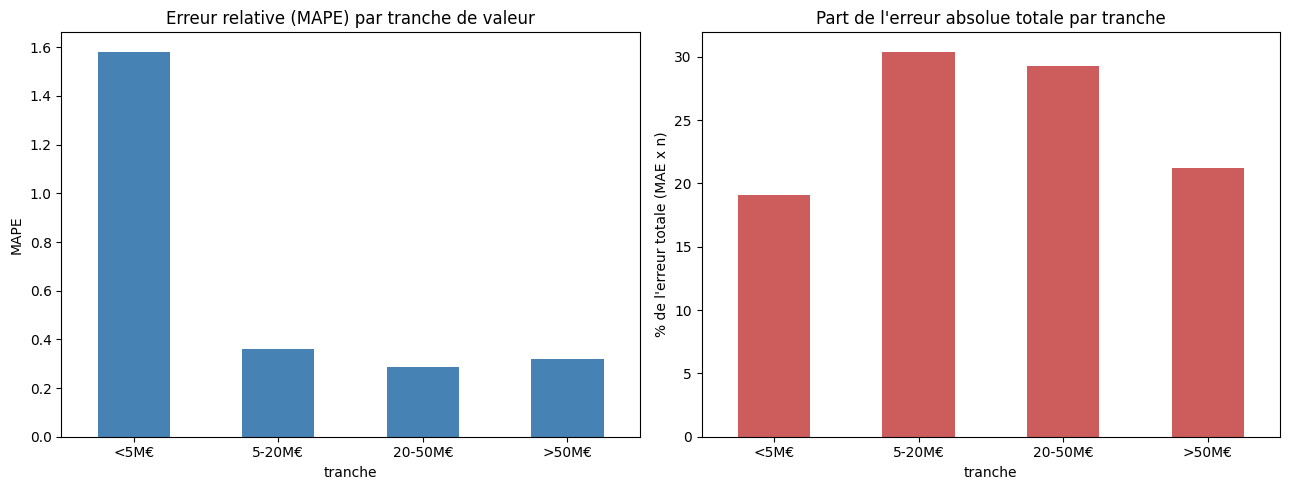

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_tranches["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)

synthese_tranches["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## Feature engineering ciblé sur les valeurs extrêmes

Le plafond de R² observé vient probablement moins des hyperparamètres que des variables disponibles. Avant de créer de nouvelles features à l'aveugle, on regarde ce que le modèle utilise déjà le plus, pour repérer ce qui manque probablement.

In [40]:
print(f"Nombre de variables actuelles : {X_train.shape[1]}")
print(X_train.columns.tolist())


Nombre de variables actuelles : 165
['age', 'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_90s', 'Performance_Gls', 'Performance_Ast', 'Performance_G-PK', 'Performance_PK', 'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A', 'Performance_GA', 'Performance_GA90', 'Performance_Saves', 'Performance_Save%', 'Performance_CS', 'Performance_CS%', 'Penalty Kicks_PKA', 'Penalty Kicks_PKsv', 'Penalty Kicks_PKm', 'Penalty Kicks_Save%', 'Standard_Sh', 'Standard_SoT', 'Standard_SoT%', 'Standard_Sh/90', 'Standard_SoT/90', 'Standard_G/Sh', 'Standard_G/SoT', 'Playing Time_Mn/MP', 'Starts_Compl', 'Subs_Subs', 'Subs_Mn/Sub', 'Subs_unSub', 'Team Success_PPM', 'Team Success_onG', 'Team Success_onGA', 'Team Success_On-Off', 'Performance_2CrdY', 'Performance_Fls', 'Performance_Fld', 'Performance_Off', 'Performance_Crs', 'Performance_Int', 'Performance_TklW', 'Performance_PKwon', 'Performance_PKcon', 'Performance_OG', 'xg', '

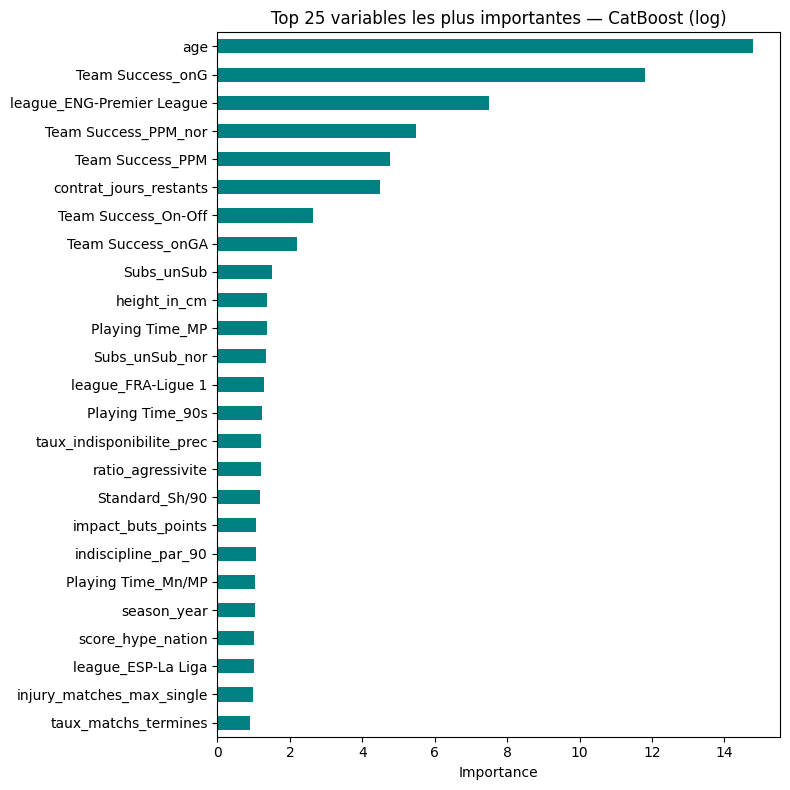

age                          14.797726
Team Success_onG             11.805485
league_ENG-Premier League     7.513242
Team Success_PPM_nor          5.494795
Team Success_PPM              4.773268
contrat_jours_restants        4.480389
Team Success_On-Off           2.642621
Team Success_onGA             2.210054
Subs_unSub                    1.503491
height_in_cm                  1.375952
Playing Time_MP               1.360512
Subs_unSub_nor                1.341677
league_FRA-Ligue 1            1.294127
Playing Time_90s              1.230935
taux_indisponibilite_prec     1.204904
ratio_agressivite             1.200225
Standard_Sh/90                1.171884
impact_buts_points            1.073916
indiscipline_par_90           1.063452
Playing Time_Mn/MP            1.038381
season_year                   1.026673
score_hype_nation             0.999820
league_ESP-La Liga            0.995269
injury_matches_max_single     0.983807
taux_matchs_termines          0.906442
dtype: float64


In [41]:
# Importance des variables du modèle champion (CatBoost, cible log)
importances = pd.Series(
    modeles_tuned_log["CatBoost (log)"].get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(25).sort_values().plot(kind="barh", color="teal")
plt.title("Top 25 variables les plus importantes — CatBoost (log)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(25))


**Pistes de features à envisager si elles ne sont pas déjà présentes ci-dessus** (à créer en amont, dans le notebook de featuring, si les données sources existent) :

- **Âge au moment de la valorisation** et son carré (la relation âge/valeur est en cloche, pas linéaire).
- **Temps restant sur le contrat** — un déterminant majeur du prix de transfert, donc de la valeur marchande.
- **Tendance récente des statistiques** (buts/passes/notes sur les 2-3 dernières saisons plutôt qu'une saison figée) pour capter les joueurs en progression ou en déclin.
- **Niveau du championnat/club actuel** (déjà peut-être capté par `team`/`nation` si encodées, sinon un indicateur du niveau de compétition manque probablement).
- **Historique de blessures / temps de jeu récent**, souvent déterminant pour les décotes.

Si ces informations n'existent pas dans les données sources, ce n'est pas un problème de modélisation : aucun tuning ni ensembling ne peut compenser une variable absente.

# Inférence statistique

## Auto-ML

pycaret ne supporte pas encore officiellement Python 3.14.3 donc on utilise à la place le package flaml

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import GridSearchCV, cross_val_predict
from flaml import AutoML

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

In [3]:
colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])

# Séparation des features et de la variable cible
joueurs_test = df_test[colonne_joueur]

# On supprime les colonnes texte et la cible pour l'entraînement
cols_a_supprimer = [colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position", "market_value_in_eur_nor"]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val = df_val.drop(columns=cols_a_supprimer)
y_val = df_val[colonne_cible]

X_test = df_test.drop(columns=cols_a_supprimer)
y_test = df_test[colonne_cible]

In [4]:
print("--- Entraînement FLAML ---")
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task="regression",
    metric="mae",
    time_budget=300,  # 5 minutes pour FLAML
    estimator_list=["xgboost", "lgbm", "catboost", "rf", "extra_tree", "kneighbor", "enet", "lassolars"],
    seed=1308
)

# Récupération des meilleures prédictions de FLAML
preds_flaml = automl.predict(X_test)
mae_flaml   = mean_absolute_error(y_test, preds_flaml)


# Préparation : Sélection dynamique des colonnes sans aucun NaN
colonnes_sans_nan = X_train.columns[X_train.isna().sum() == 0].tolist()

print(f"Filtrage pour les modèles linéaires/SVR :")
print(f" -> {len(colonnes_sans_nan)} colonnes conservées sur {X_train.shape[1]} (0 NaN).")

X_train_sans_nan = X_train[colonnes_sans_nan]
X_val_sans_nan   = X_val[colonnes_sans_nan]
X_test_sans_nan  = X_test[colonnes_sans_nan]


print("\n--- Entraînement SVR ---")
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_svr = {
    'svr__C':       [0.1, 1, 10, 100],
    'svr__kernel':  ['rbf', 'linear'],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

grid_svr = GridSearchCV(svr_pipeline, param_svr, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_svr.fit(X_train_sans_nan, y_train)

preds_svr = grid_svr.predict(X_test_sans_nan)
mae_svr   = mean_absolute_error(y_test, preds_svr)


print("--- Entraînement Régression Linéaire ---")
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

lr_pipeline.fit(X_train_sans_nan, y_train)

preds_lr = lr_pipeline.predict(X_test_sans_nan)
mae_lr   = mean_absolute_error(y_test, preds_lr)


print("\nComparaison des performances (MAE)")
print(f"FLAML                                : {mae_flaml:,.0f} € (Modèle : {automl.best_estimator})")
print(f"SVR (Optimisé par GridSearch)        : {mae_svr:,.0f} €")
print(f"Régression Linéaire Multiple         : {mae_lr:,.0f} €")

resultats_automl = {
    "FLAML":            (mae_flaml, preds_flaml),
    "SVR":              (mae_svr,   preds_svr),
    "LinearRegression": (mae_lr,    preds_lr),
}
meilleur_approche = min(resultats_automl, key=lambda k: resultats_automl[k][0])
print(f"\nLe meilleur choix final est : {meilleur_approche}")

--- Entraînement FLAML ---
[flaml.automl.logger: 07-03 09:39:29] {2375} INFO - task = regression
[flaml.automl.logger: 07-03 09:39:29] {2383} INFO - Data split method: uniform
[flaml.automl.logger: 07-03 09:39:29] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 07-03 09:39:29] {2489} INFO - Minimizing error metric: mae
[flaml.automl.logger: 07-03 09:39:29] {2606} INFO - List of ML learners in AutoML Run: ['xgboost', 'lgbm', 'catboost', 'rf', 'extra_tree', 'kneighbor', 'enet', 'lassolars']
[flaml.automl.logger: 07-03 09:39:29] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 07-03 09:39:29] {3046} INFO - Estimated sufficient time budget=1205s. Estimated necessary time budget=4s.
[flaml.automl.logger: 07-03 09:39:29] {3097} INFO -  at 0.5s,	estimator xgboost's best error=9.5835e+06,	best estimator xgboost's best error=9.5835e+06
[flaml.automl.logger: 07-03 09:39:29] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-03 09:39:29

In [5]:
# On extrait le meilleur estimateur trouvé par FLAML
meilleur_modele = automl.model.estimator

print(f"Meilleur modèle trouvé : {type(meilleur_modele).__name__}\n")

print("Hyperparamètres finaux :")
if hasattr(meilleur_modele, 'get_all_params'):
    print(meilleur_modele.get_all_params())
else:
    print(meilleur_modele.get_params())

Meilleur modèle trouvé : CatBoostRegressor

Hyperparamètres finaux :
{'nan_mode': 'Min', 'eval_metric': 'RMSE', 'iterations': 8192, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'Iter', 'rsm': 1, 'boost_from_average': True, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': True, 'od_wait': 42, 'random_seed': 10242048, 'depth': 6, 'posterior_sampling': False, 'border_count': 254, 'classes_count': 0, 'auto_class_weights': 'None', 'sparse_features_conflict_fraction': 0, 'leaf_estimation_backtracking': 'AnyImprovement', 'best_model_min

## Premiers tests de modélisation

In [6]:
modeles = {

    # Forêts
    "Random Forest": RandomForestRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),
    "Extra Trees": ExtraTreesRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),

    # Boosting (alignés sur la stratégie gagnante de FLAML)
    "XGBoost": XGBRegressor(
        random_state=1308,
        n_jobs=-1,
        tree_method='hist',
        grow_policy='lossguide',
        max_depth=0,
        max_leaves=43,
        enable_categorical=True,
        min_child_weight=4.791541868873825,
        subsample=0.7386565774212087,
        reg_alpha=0.0009765625,
        reg_lambda=1.547191718086146,
        learning_rate=0.01,
        n_estimators=3800,
        objective='reg:squarederror',
        verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=3000,
        learning_rate=0.01,
        max_depth=6,
        verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=1308,
        iterations=8192,
        learning_rate=0.005,
        depth=6,
        l2_leaf_reg=3,
        subsample=0.8,
        early_stopping_rounds=100,
        verbose=0
    ),
}

In [7]:
# Entraînement puis évaluation sur la VALIDATION
resultats_baseline = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    modele.fit(X_train, y_train)
    preds_val = modele.predict(X_val)

    mae_val  = mean_absolute_error(y_val, preds_val)
    r2_val   = r2_score(y_val, preds_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, preds_val))
    mape_val = mean_absolute_percentage_error(y_val, preds_val)

    n, p = len(y_val), X_val.shape[1]
    r2_ajuste_val = 1 - (1 - r2_val) * (n - 1) / (n - p - 1)

    resultats_baseline[nom] = {
        "MAE Val":        mae_val,
        "RMSE Val":       rmse_val,
        "MAPE Val":       mape_val,
        "R² Val":         r2_val,
        "R² Ajusté Val":  r2_ajuste_val
    }

    print(f"   -> Validation | MAE : {mae_val:,.0f} € | RMSE : {rmse_val:,.0f} € | MAPE : {mape_val:.2%} | R² : {r2_val:.2%} | R² Ajusté : {r2_ajuste_val:.2%}")

print("\nCLASSEMENT FINAL Validation (trié par MAE croissante)")
tableau = []
for nom, m in resultats_baseline.items():
    tableau.append({
        "Modèle":                    nom,
        "Erreur moyenne Val (MAE)":  f"{m['MAE Val']:,.0f} €",
        "Score R² Val":              f"{m['R² Val']:.2%}",
        "Score R² Ajusté Val":       f"{m['R² Ajusté Val']:.2%}",
    })
df_baseline_val = pd.DataFrame(tableau).sort_values("Erreur moyenne Val (MAE)")
print(df_baseline_val.to_string(index=False))

Entraînement de Random Forest...
   -> Validation | MAE : 5,040,843 € | RMSE : 9,713,330 € | MAPE : 89.33% | R² : 70.90% | R² Ajusté : 68.77%
Entraînement de Extra Trees...
   -> Validation | MAE : 4,983,436 € | RMSE : 9,540,966 € | MAPE : 91.67% | R² : 71.92% | R² Ajusté : 69.87%
Entraînement de XGBoost...
   -> Validation | MAE : 4,612,237 € | RMSE : 8,945,683 € | MAPE : 81.67% | R² : 75.31% | R² Ajusté : 73.51%
Entraînement de LightGBM...
   -> Validation | MAE : 4,782,923 € | RMSE : 9,010,973 € | MAPE : 88.97% | R² : 74.95% | R² Ajusté : 73.13%
Entraînement de CatBoost...
   -> Validation | MAE : 4,659,503 € | RMSE : 8,835,834 € | MAPE : 91.54% | R² : 75.92% | R² Ajusté : 74.16%

CLASSEMENT FINAL Validation (trié par MAE croissante)
       Modèle Erreur moyenne Val (MAE) Score R² Val Score R² Ajusté Val
      XGBoost              4,612,237 €       75.31%              73.51%
     CatBoost              4,659,503 €       75.92%              74.16%
     LightGBM              4,782,923 

In [8]:
# Évaluation sur le TEST
resultats_baseline_test = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    modele.fit(X_train, y_train)
    preds_test = modele.predict(X_test)

    mae_test  = mean_absolute_error(y_test, preds_test)
    r2_test   = r2_score(y_test, preds_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    mape_test = mean_absolute_percentage_error(y_test, preds_test)

    n, p = len(y_test), X_test.shape[1]
    r2_ajuste_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

    resultats_baseline_test[nom] = {
        "MAE Test":        mae_test,
        "RMSE Test":       rmse_test,
        "MAPE Test":       mape_test,
        "R² Test":         r2_test,
        "R² Ajusté Test":  r2_ajuste_test
    }

    print(f"   -> Test | MAE : {mae_test:,.0f} € | RMSE : {rmse_test:,.0f} € | MAPE : {mape_test:.2%} | R² : {r2_test:.2%} | R² Ajusté : {r2_ajuste_test:.2%}")

print("\nCLASSEMENT FINAL Test (trié par MAE croissante)")
tableau = []
for nom, m in resultats_baseline_test.items():
    tableau.append({
        "Modèle":                     nom,
        "Erreur moyenne Test (MAE)":  f"{m['MAE Test']:,.0f} €",
        "Score R² Test":              f"{m['R² Test']:.2%}",
        "Score R² Ajusté Test":       f"{m['R² Ajusté Test']:.2%}",
    })
df_baseline_test = pd.DataFrame(tableau).sort_values("Erreur moyenne Test (MAE)")
print(df_baseline_test.to_string(index=False))

Entraînement de Random Forest...
   -> Test | MAE : 5,378,551 € | RMSE : 10,630,318 € | MAPE : 80.18% | R² : 67.69% | R² Ajusté : 65.18%
Entraînement de Extra Trees...
   -> Test | MAE : 5,331,168 € | RMSE : 10,490,978 € | MAPE : 83.06% | R² : 68.53% | R² Ajusté : 66.08%
Entraînement de XGBoost...
   -> Test | MAE : 4,977,951 € | RMSE : 9,748,343 € | MAPE : 77.20% | R² : 72.83% | R² Ajusté : 70.72%
Entraînement de LightGBM...
   -> Test | MAE : 5,073,985 € | RMSE : 9,701,387 € | MAPE : 79.53% | R² : 73.09% | R² Ajusté : 71.00%
Entraînement de CatBoost...
   -> Test | MAE : 5,062,656 € | RMSE : 9,765,905 € | MAPE : 78.63% | R² : 72.73% | R² Ajusté : 70.61%

CLASSEMENT FINAL Test (trié par MAE croissante)
       Modèle Erreur moyenne Test (MAE) Score R² Test Score R² Ajusté Test
      XGBoost               4,977,951 €        72.83%               70.72%
     CatBoost               5,062,656 €        72.73%               70.61%
     LightGBM               5,073,985 €        73.09%         

## Tuning des hyperparamètres (Optuna)

On cherche, pour chaque modèle, les hyperparamètres qui **minimisent le MAE sur le jeu de validation** (`X_val` / `y_val`). Le jeu de **test reste intouché** pendant tout le tuning : il ne sert qu'à l'évaluation finale, une seule fois, pour ne pas biaiser l'estimation de la performance réelle.

On utilise [Optuna](https://optuna.org/) (recherche bayésienne / TPE), beaucoup plus efficace qu'un `GridSearchCV` classique pour ce genre d'espaces de recherche.

> **Note** : `N_TRIALS = 75` minimum recommandé. Avec TPE, les ~5 premiers essais sont quasi-aléatoires (phase d'exploration). En dessous de 50 trials, l'optimisation bayésienne n'a pas assez d'informations pour converger correctement.

In [9]:
# !pip install optuna  # à décommenter la première fois

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS     = 75       # ← augmentez à 100-200 si vous avez du temps (résultats nettement meilleurs)
RANDOM_STATE = 1308

In [10]:
def tune_forest(model_class, trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":        trial.suggest_int("max_depth", 5, 40),
        "min_samples_split":trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":     trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning Random Forest ---")
study_rf = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(lambda t: tune_forest(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_rf.best_value)
print("Meilleurs paramètres :", study_rf.best_params)

print("\n--- Tuning Extra Trees ---")
study_et = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et.optimize(lambda t: tune_forest(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_et.best_value)
print("Meilleurs paramètres :", study_et.best_params)

--- Tuning Random Forest ---


Best trial: 34. Best value: 5.00757e+06: 100%|██████████| 75/75 [24:01<00:00, 19.22s/it]


Meilleur MAE : 5007569.875095291
Meilleurs paramètres : {'n_estimators': 1000, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.8}

--- Tuning Extra Trees ---


Best trial: 71. Best value: 4.93189e+06: 100%|██████████| 75/75 [18:51<00:00, 15.09s/it]

Meilleur MAE : 4931886.586148158
Meilleurs paramètres : {'n_estimators': 1000, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0}


In [14]:
def objective_xgb(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":       trial.suggest_int("max_depth", 3, 12),
        "learning_rate":   trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":       trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":     "hist",
        "enable_categorical": True,
        "objective":       "reg:squarederror",
        "random_state":    RANDOM_STATE,
        "n_jobs":          -1,
        "verbosity":       0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning XGBoost ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_xgb.best_value)
print("Meilleurs paramètres :", study_xgb.best_params)

--- Tuning XGBoost ---


Best trial: 40. Best value: 4.61321e+06: 100%|██████████| 75/75 [29:08<00:00, 23.31s/it]

Meilleur MAE : 4613210.949303867
Meilleurs paramètres : {'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.013667664977096863, 'subsample': 0.5351306882604444, 'colsample_bytree': 0.6469703989319503, 'min_child_weight': 8.831941617006025, 'reg_alpha': 0.00137377756215791, 'reg_lambda': 0.036404582750347185}


In [15]:
def objective_lgbm(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":      trial.suggest_int("num_leaves", 15, 255),
        "max_depth":       trial.suggest_int("max_depth", 3, 15),
        "learning_rate":   trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":       trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":    RANDOM_STATE,
        "n_jobs":          -1,
        "verbose":         -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("--- Tuning LightGBM ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_lgbm.best_value)
print("Meilleurs paramètres :", study_lgbm.best_params)

--- Tuning LightGBM ---


Best trial: 52. Best value: 4.68617e+06: 100%|██████████| 75/75 [10:50<00:00,  8.67s/it]

Meilleur MAE : 4686173.012496545
Meilleurs paramètres : {'n_estimators': 2500, 'num_leaves': 33, 'max_depth': 15, 'learning_rate': 0.0142061327754145, 'subsample': 0.8841470290544543, 'colsample_bytree': 0.6905173764143293, 'reg_alpha': 0.0005146269057482081, 'reg_lambda': 0.0005946912902428805}


In [17]:
def objective_catboost(trial):
    params = {
        "iterations":            trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                 trial.suggest_int("depth", 4, 8),
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":             trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":        "Bernoulli",
        "random_state":          RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":               0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False) 
    preds = model.predict(X_val)                                        
    return mean_absolute_error(y_val, preds)

print("--- Tuning CatBoost ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_cat.best_value)
print("Meilleurs paramètres :", study_cat.best_params)

--- Tuning CatBoost ---


Best trial: 64. Best value: 4.57457e+06: 100%|██████████| 75/75 [32:57<00:00, 26.37s/it]

Meilleur MAE : 4574571.039471384
Meilleurs paramètres : {'iterations': 3000, 'depth': 7, 'learning_rate': 0.02224521814137021, 'l2_leaf_reg': 3.844830158180545, 'subsample': 0.7531318452889296}


In [18]:
def objective_svr(trial):
    params = {
        "C":      trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon":trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma":  trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return mean_absolute_error(y_val, preds)

print("--- Tuning SVR ---")
study_svr = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr.optimize(objective_svr, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_svr.best_value)
print("Meilleurs paramètres :", study_svr.best_params)


def objective_enet(trial):
    params = {
        "alpha":      trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio":   trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter":   10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return mean_absolute_error(y_val, preds)

print("\n--- Tuning ElasticNet ---")
study_enet = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet.optimize(objective_enet, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_enet.best_value)
print("Meilleurs paramètres :", study_enet.best_params)

--- Tuning SVR ---


Best trial: 68. Best value: 8.57613e+06: 100%|██████████| 75/75 [09:40<00:00,  7.74s/it]


Meilleur MAE : 8576127.242101103
Meilleurs paramètres : {'C': 99.76215625711077, 'epsilon': 0.023051902254883485, 'kernel': 'linear', 'gamma': 'auto'}

--- Tuning ElasticNet ---


Best trial: 52. Best value: 6.56342e+06: 100%|██████████| 75/75 [05:14<00:00,  4.19s/it]

Meilleur MAE : 6563416.330047268
Meilleurs paramètres : {'alpha': 0.2761134370617829, 'l1_ratio': 0.6585543009187906}


### Modèles finaux avec hyperparamètres tunés

In [19]:
modeles_tuned = {
    "Random Forest": RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees":   ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost":       XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True,
                                   objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM":      LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost":      CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli",
                                        random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_sans_nan = {
    "SVR":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr.best_params))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()),
                             ("enet", ElasticNet(**study_enet.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}

In [20]:
def evaluer(modele, X_tr, y_tr, X_ev, y_ev):
    modele.fit(X_tr, y_tr)
    preds = modele.predict(X_ev)
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# Évaluation sur la VALIDATION
resultats_tuned_val = {}
for nom, modele in modeles_tuned.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train, y_train, X_val, y_val)

for nom, modele in modeles_tuned_sans_nan.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train_sans_nan, y_train, X_val_sans_nan, y_val)

df_tuned_val = pd.DataFrame(resultats_tuned_val).T.sort_values("MAE")
print("\nCLASSEMENT (Validation, modèles tunés)")
print(df_tuned_val)

Entraînement (tuné) de Random Forest...
Entraînement (tuné) de Extra Trees...
Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...
Entraînement (tuné) de SVR...
Entraînement (tuné) de ElasticNet...

CLASSEMENT (Validation, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       4.574694e+06  8.820425e+06  0.847437  0.760008   0.742502
XGBoost        4.613211e+06  8.863869e+06  0.851999  0.757638   0.739959
LightGBM       4.686173e+06  8.992247e+06  0.838310  0.750567   0.732372
Extra Trees    4.931887e+06  9.492317e+06  0.894131  0.722053   0.701778
Random Forest  5.007570e+06  9.729524e+06  0.886730  0.707988   0.686687
ElasticNet     6.563416e+06  1.118801e+07  2.307152  0.613878   0.588623
SVR            8.576127e+06  1.774852e+07  1.156295  0.028277  -0.035281


In [21]:
# Évaluation finale sur le TEST (à ne lancer qu'une seule fois, à la toute fin)
resultats_tuned_test = {}
for nom, modele in modeles_tuned.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train, y_train, X_test, y_test)

for nom, modele in modeles_tuned_sans_nan.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train_sans_nan, y_train, X_test_sans_nan, y_test)

df_tuned_test = pd.DataFrame(resultats_tuned_test).T.sort_values("MAE")
print("CLASSEMENT FINAL (Test, modèles tunés)")
print(df_tuned_test)

CLASSEMENT FINAL (Test, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       4.999745e+06  9.738745e+06  0.767825  0.728826   0.707730
LightGBM       5.023861e+06  9.729653e+06  0.773717  0.729332   0.708276
XGBoost        5.091485e+06  9.902372e+06  0.778815  0.719637   0.697827
Extra Trees    5.268151e+06  1.047562e+07  0.808827  0.686237   0.661829
Random Forest  5.335912e+06  1.066077e+07  0.785867  0.675048   0.649769
ElasticNet     7.209624e+06  1.223054e+07  2.167350  0.572305   0.542485
SVR            9.361370e+06  1.878245e+07  1.111995 -0.008664  -0.078992


## Tuning avec cible transformée (log)

`market_value_in_eur` est presque toujours très asymétrique (beaucoup de joueurs à faible valeur, quelques stars très au-dessus). On entraîne ici les modèles sur `log1p(y)` et on retransforme les prédictions avec `expm1` avant de calculer les métriques (MAE, RMSE, R²...), pour rester comparable en euros avec les résultats précédents.

Le tuning est refait à l'identique (mêmes espaces de recherche, même `N_TRIALS`), mais l'objectif Optuna optimise le MAE en euros **après** retransformation — pas le MAE en log — pour que le choix des hyperparamètres reste piloté par ce qui compte réellement.

In [22]:
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

In [23]:
def tune_forest_log(model_class, trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)  # MAE en euros, pas en log

print("--- Tuning Random Forest (cible log) ---")
study_rf_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf_log.optimize(lambda t: tune_forest_log(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_rf_log.best_value)
print("Meilleurs paramètres :", study_rf_log.best_params)

print("\n--- Tuning Extra Trees (cible log) ---")
study_et_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et_log.optimize(lambda t: tune_forest_log(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_et_log.best_value)
print("Meilleurs paramètres :", study_et_log.best_params)

--- Tuning Random Forest (cible log) ---


Best trial: 74. Best value: 5.08694e+06: 100%|██████████| 75/75 [26:08<00:00, 20.91s/it]


Meilleur MAE : 5086937.085937588
Meilleurs paramètres : {'n_estimators': 600, 'max_depth': 26, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0}

--- Tuning Extra Trees (cible log) ---


Best trial: 38. Best value: 5.02115e+06: 100%|██████████| 75/75 [12:43<00:00, 10.18s/it]

Meilleur MAE : 5021152.7157317605
Meilleurs paramètres : {'n_estimators': 200, 'max_depth': 31, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0}


In [24]:
def objective_xgb_log(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":      "hist",
        "enable_categorical": True,
        "objective":        "reg:squarederror",
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
        "verbosity":        0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning XGBoost (cible log) ---")
study_xgb_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb_log.optimize(objective_xgb_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_xgb_log.best_value)
print("Meilleurs paramètres :", study_xgb_log.best_params)

--- Tuning XGBoost (cible log) ---


Best trial: 62. Best value: 4.51766e+06: 100%|██████████| 75/75 [27:29<00:00, 21.99s/it]

Meilleur MAE : 4517662.311039179
Meilleurs paramètres : {'n_estimators': 3250, 'max_depth': 6, 'learning_rate': 0.014112636542722904, 'subsample': 0.7543320098548525, 'colsample_bytree': 0.9766673878368424, 'min_child_weight': 7.042986213331221, 'reg_alpha': 0.8626621127617752, 'reg_lambda': 0.0946492153427171}


In [25]:
def objective_lgbm_log(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 255),
        "max_depth":        trial.suggest_int("max_depth", 3, 15),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
        "verbose":          -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning LightGBM (cible log) ---")
study_lgbm_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm_log.optimize(objective_lgbm_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_lgbm_log.best_value)
print("Meilleurs paramètres :", study_lgbm_log.best_params)

--- Tuning LightGBM (cible log) ---


Best trial: 71. Best value: 4.57164e+06: 100%|██████████| 75/75 [10:28<00:00,  8.38s/it]

Meilleur MAE : 4571639.859088365
Meilleurs paramètres : {'n_estimators': 4000, 'num_leaves': 175, 'max_depth': 6, 'learning_rate': 0.01834710144880718, 'subsample': 0.9834042356031492, 'colsample_bytree': 0.7683450985747639, 'reg_alpha': 0.12419507703265803, 'reg_lambda': 0.21516053921270725}


In [26]:
def objective_catboost_log(trial):
    params = {
        "iterations":           trial.suggest_int("iterations", 500, 3000, step=500),  # était 1000-10000
        "depth":                trial.suggest_int("depth", 4, 8),                       # était 4-10
        "learning_rate":        trial.suggest_float("learning_rate", 0.01, 0.1, log=True),  # était 0.001
        "l2_leaf_reg":          trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":            trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":       "Bernoulli",
        "random_state":         RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":              0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train_log, eval_set=(X_val, y_val_log), verbose=False)
    preds = np.expm1(model.predict(X_val))
    return mean_absolute_error(y_val, preds)

print("--- Tuning CatBoost (cible log) ---")
study_cat_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat_log.optimize(objective_catboost_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_cat_log.best_value)
print("Meilleurs paramètres :", study_cat_log.best_params)

--- Tuning CatBoost (cible log) ---


Best trial: 53. Best value: 4.45892e+06: 100%|██████████| 75/75 [13:04<00:00, 10.47s/it]

Meilleur MAE : 4458917.034481833
Meilleurs paramètres : {'iterations': 1500, 'depth': 6, 'learning_rate': 0.04672989254871184, 'l2_leaf_reg': 2.253649771512919, 'subsample': 0.7742331368880401}


In [27]:
def objective_svr_log(trial):
    params = {
        "C":      trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon":trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma":  trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return mean_absolute_error(y_val, preds)

print("--- Tuning SVR (cible log) ---")
study_svr_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr_log.optimize(objective_svr_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_svr_log.best_value)
print("Meilleurs paramètres :", study_svr_log.best_params)


def objective_enet_log(trial):
    params = {
        "alpha":      trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio":   trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter":   10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return mean_absolute_error(y_val, preds)

print("\n--- Tuning ElasticNet (cible log) ---")
study_enet_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet_log.optimize(objective_enet_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur MAE :", study_enet_log.best_value)
print("Meilleurs paramètres :", study_enet_log.best_params)

--- Tuning SVR (cible log) ---


Best trial: 16. Best value: 5.26496e+06: 100%|██████████| 75/75 [1:04:14<00:00, 51.39s/it] 


Meilleur MAE : 5264960.9450438125
Meilleurs paramètres : {'C': 1.1105358279862136, 'epsilon': 0.036578710974762244, 'kernel': 'rbf', 'gamma': 'auto'}

--- Tuning ElasticNet (cible log) ---


Best trial: 38. Best value: 5.79548e+06: 100%|██████████| 75/75 [01:09<00:00,  1.07it/s]

Meilleur MAE : 5795483.405779777
Meilleurs paramètres : {'alpha': 0.15112216587798655, 'l1_ratio': 0.12515618090116784}


### Modèles finaux (cible log) et comparaison avec la version sans transformation

In [28]:
modeles_tuned_log = {
    "Random Forest (log)": RandomForestRegressor(**study_rf_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees (log)":   ExtraTreesRegressor(**study_et_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (log)":       XGBRegressor(**study_xgb_log.best_params, tree_method="hist", enable_categorical=True,
                                          objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM (log)":      LGBMRegressor(**study_lgbm_log.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost (log)":      CatBoostRegressor(**study_cat_log.best_params, bootstrap_type="Bernoulli",
                                               random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_log_sans_nan = {
    "SVR (log)":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr_log.best_params))]),
    "ElasticNet (log)": Pipeline([("scaler", StandardScaler()),
                                   ("enet", ElasticNet(**study_enet_log.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}

In [29]:
def evaluer_log(modele, X_tr, y_tr_log, X_ev, y_ev):
    modele.fit(X_tr, y_tr_log)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# Évaluation sur la VALIDATION
resultats_tuned_log_val = {}
for nom, modele in modeles_tuned_log.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train, y_train_log, X_val, y_val)

for nom, modele in modeles_tuned_log_sans_nan.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_val_sans_nan, y_val)

df_tuned_log_val = pd.DataFrame(resultats_tuned_log_val).T.sort_values("MAE")

# Comparaison directe avec les modèles tunés sans transformation
df_comparaison_val = pd.concat([df_tuned_val, df_tuned_log_val]).sort_values("MAE")
print("\nCLASSEMENT COMPARATIF (Validation) — avec vs sans transformation log")
print(df_comparaison_val)

Entraînement (tuné, log) de Random Forest (log)...
Entraînement (tuné, log) de Extra Trees (log)...
Entraînement (tuné, log) de XGBoost (log)...
Entraînement (tuné, log) de LightGBM (log)...
Entraînement (tuné, log) de CatBoost (log)...
Entraînement (tuné, log) de SVR (log)...
Entraînement (tuné, log) de ElasticNet (log)...

CLASSEMENT COMPARATIF (Validation) — avec vs sans transformation log
                              MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost (log)       4.431083e+06  8.890363e+06  0.517639  0.756187   0.738402
XGBoost (log)        4.517662e+06  9.171045e+06  0.512086  0.740549   0.721623
LightGBM (log)       4.571640e+06  9.235404e+06  0.519211  0.736894   0.717702
CatBoost             4.574694e+06  8.820425e+06  0.847437  0.760008   0.742502
XGBoost              4.613211e+06  8.863869e+06  0.851999  0.757638   0.739959
LightGBM             4.686173e+06  8.992247e+06  0.838310  0.750567   0.732372
Extra Trees          4.931887e+06  9.492317e+06  0.

In [30]:
# Évaluation finale sur le TEST
resultats_tuned_log_test = {}
for nom, modele in modeles_tuned_log.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train, y_train_log, X_test, y_test)

for nom, modele in modeles_tuned_log_sans_nan.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_test_sans_nan, y_test)

df_tuned_log_test = pd.DataFrame(resultats_tuned_log_test).T.sort_values("MAE")

df_comparaison_test = pd.concat([df_tuned_test, df_tuned_log_test]).sort_values("MAE")
print("CLASSEMENT COMPARATIF FINAL (Test) — avec vs sans transformation log")
print(df_comparaison_test)

CLASSEMENT COMPARATIF FINAL (Test) — avec vs sans transformation log
                              MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost (log)       4.946832e+06  9.700244e+06  0.498939  0.730966   0.710037
CatBoost             4.999745e+06  9.738745e+06  0.767825  0.728826   0.707730
XGBoost (log)        5.002684e+06  9.995493e+06  0.496279  0.714339   0.692117
LightGBM (log)       5.015789e+06  9.949933e+06  0.509470  0.716937   0.694917
LightGBM             5.023861e+06  9.729653e+06  0.773717  0.729332   0.708276
XGBoost              5.091485e+06  9.902372e+06  0.778815  0.719637   0.697827
Extra Trees          5.268151e+06  1.047562e+07  0.808827  0.686237   0.661829
Random Forest        5.335912e+06  1.066077e+07  0.785867  0.675048   0.649769
Extra Trees (log)    5.543204e+06  1.170520e+07  0.537014  0.608258   0.577783
Random Forest (log)  5.632923e+06  1.181159e+07  0.536932  0.601105   0.570073
SVR (log)            5.984308e+06  1.187843e+07  0.741718  0.5

## Modèles séparés : Gardiens vs Joueurs de champ

Les gardiens ont des statistiques et des déterminants de valeur marchande très différents des joueurs de champ. On sépare la population avec `pos_GK`, on retune un modèle spécifique à chaque groupe, puis on compare à la performance du modèle global restreinte au même sous-groupe, pour voir si la séparation apporte un vrai gain.

In [31]:
mask_train_gk = X_train["pos_GK"] == 1
mask_val_gk   = X_val["pos_GK"] == 1
mask_test_gk  = X_test["pos_GK"] == 1

X_train_gk, y_train_gk = X_train[mask_train_gk], y_train[mask_train_gk]
X_val_gk,   y_val_gk   = X_val[mask_val_gk],     y_val[mask_val_gk]
X_test_gk,  y_test_gk  = X_test[mask_test_gk],   y_test[mask_test_gk]

X_train_champ, y_train_champ = X_train[~mask_train_gk], y_train[~mask_train_gk]
X_val_champ,   y_val_champ   = X_val[~mask_val_gk],     y_val[~mask_val_gk]
X_test_champ,  y_test_champ  = X_test[~mask_test_gk],   y_test[~mask_test_gk]

print(f"Gardiens         : {len(X_train_gk):>5} train | {len(X_val_gk):>4} val | {len(X_test_gk):>4} test")
print(f"Joueurs de champ : {len(X_train_champ):>5} train | {len(X_val_champ):>4} val | {len(X_test_champ):>4} test")

colonnes_position = ["pos_DF", "pos_FW", "pos_GK", "pos_MF"]

X_train_gk_feat    = X_train_gk.drop(columns=colonnes_position)
X_val_gk_feat      = X_val_gk.drop(columns=colonnes_position)
X_test_gk_feat     = X_test_gk.drop(columns=colonnes_position)

X_train_champ_feat = X_train_champ.drop(columns=colonnes_position)
X_val_champ_feat   = X_val_champ.drop(columns=colonnes_position)
X_test_champ_feat  = X_test_champ.drop(columns=colonnes_position)

Gardiens         :   567 train |  180 val |  172 test
Joueurs de champ :  6837 train | 2248 val | 2115 test


In [32]:
N_TRIALS_SPLIT = 50   # sous-populations plus petites → moins d'essais nécessaires

FIXED_PARAMS = {
    RandomForestRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1},
    ExtraTreesRegressor:   {"random_state": RANDOM_STATE, "n_jobs": -1},
    XGBRegressor:          {"tree_method": "hist", "enable_categorical": True,
                            "objective": "reg:squarederror", "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0},
    LGBMRegressor:         {"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1},
}

def espace_forest(trial):
    return {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
    }

def espace_xgb(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 300, 3000, step=200),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def espace_lgbm(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 300, 3000, step=200),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 255),
        "max_depth":        trial.suggest_int("max_depth", 3, 15),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials):
    fixed = FIXED_PARAMS[model_class]
    def objective(trial):
        params = {**espace_fn(trial), **fixed}
        model = model_class(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_ev)
        return mean_absolute_error(y_ev, preds)
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

modeles_a_tuner = {
    "Random Forest": (RandomForestRegressor, espace_forest),
    "Extra Trees":   (ExtraTreesRegressor,   espace_forest),
    "XGBoost":       (XGBRegressor,          espace_xgb),
    "LightGBM":      (LGBMRegressor,         espace_lgbm),
}

In [33]:
groupes = {
    "Gardiens":        (X_train_gk_feat,    y_train_gk,    X_val_gk_feat,    y_val_gk),
    "Joueurs de champ":(X_train_champ_feat, y_train_champ, X_val_champ_feat, y_val_champ),
}

tuning_par_groupe = {}

for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    tuning_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, espace_fn) in modeles_a_tuner.items():
        print(f"\n=== Tuning {nom_modele} — {nom_groupe} ===")
        study = tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials=N_TRIALS_SPLIT)
        tuning_par_groupe[nom_groupe][nom_modele] = study
        print(f"Meilleur MAE : {study.best_value:,.0f} € | Params : {study.best_params}")


=== Tuning Random Forest — Gardiens ===


Best trial: 44. Best value: 3.55856e+06: 100%|██████████| 50/50 [00:40<00:00,  1.24it/s]


Meilleur MAE : 3,558,561 € | Params : {'n_estimators': 300, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 1.0}

=== Tuning Extra Trees — Gardiens ===


Best trial: 34. Best value: 3.49482e+06: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]


Meilleur MAE : 3,494,816 € | Params : {'n_estimators': 700, 'max_depth': 21, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 1.0}

=== Tuning XGBoost — Gardiens ===


...

Meilleur MAE : 5,105,548 € | Params : {'n_estimators': 800, 'max_depth': 35, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 1.0}

=== Tuning XGBoost — Joueurs de champ ===


  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 0. Best value: 4.89033e+06:   2%|▏         | 1/50 [00:11<09:04, 11.12s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 1. Best value: 4.84448e+06:   4%|▍         | 2/50 [00:15<05:40,  7.10s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be r

Meilleur MAE : 4,754,754 € | Params : {'n_estimators': 2500, 'max_depth': 12, 'learning_rate': 0.005341395755905933, 'subsample': 0.5001853439493764, 'colsample_bytree': 0.9187513260196021, 'min_child_weight': 8.058434944738107, 'reg_alpha': 0.4504186181080609, 'reg_lambda': 0.046335623842971935}

=== Tuning LightGBM — Joueurs de champ ===


  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 0. Best value: 5.5034e+06:   2%|▏         | 1/50 [00:00<00:33,  1.44it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 2900].
  optuna_warn(
Best trial: 1. Best value: 4.91459e+06:   4%|▍         | 2/50 [00:05<02:28,  3.10s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 3000] and step=200, but the range is not divisible by `step`. It will be re

Meilleur MAE : 4,810,623 € | Params : {'n_estimators': 2100, 'num_leaves': 52, 'max_depth': 9, 'learning_rate': 0.00980636122237413, 'subsample': 0.7577457904433502, 'colsample_bytree': 0.6121781419502618, 'reg_alpha': 0.0028398011700984434, 'reg_lambda': 0.1296709367243343}


In [34]:
# Construction des modèles finaux, spécifiques à chaque groupe
# IMPORTANT : on les construit ici une seule fois et on les garde gelés pour la comparaison
modeles_finaux_par_groupe = {}
for nom_groupe in groupes:
    modeles_finaux_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, _) in modeles_a_tuner.items():
        study = tuning_par_groupe[nom_groupe][nom_modele]
        modeles_finaux_par_groupe[nom_groupe][nom_modele] = model_class(
            **study.best_params, **FIXED_PARAMS[model_class]
        )

# Pré-entraînement des modèles spécifiques sur leur groupe respectif
# (nécessaire avant la comparaison pour éviter les ré-entraînements en boucle)
modeles_groupe_entraines = {}
for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    modeles_groupe_entraines[nom_groupe] = {}
    for nom_modele, modele in modeles_finaux_par_groupe[nom_groupe].items():
        modele.fit(X_tr, y_tr)
        modeles_groupe_entraines[nom_groupe][nom_modele] = modele
        print(f"  {nom_groupe} / {nom_modele} : entraîné")

  Gardiens / Random Forest : entraîné
  Gardiens / Extra Trees : entraîné
  Gardiens / XGBoost : entraîné
  Gardiens / LightGBM : entraîné
  Joueurs de champ / Random Forest : entraîné
  Joueurs de champ / Extra Trees : entraîné
  Joueurs de champ / XGBoost : entraîné
  Joueurs de champ / LightGBM : entraîné


In [35]:
# Comparaison : modèle GLOBAL vs modèle SPÉCIFIQUE évalués sur les sous-groupes (validation)
sous_groupes_val = {
    "Gardiens":         (X_val_gk,    y_val_gk,    X_val_gk_feat),
    "Joueurs de champ": (X_val_champ, y_val_champ, X_val_champ_feat),
}

comparaison_groupes = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_val.items():
    for nom_modele in modeles_a_tuner:
        # Modèle GLOBAL (déjà entraîné sur tout le train dans 'modeles_tuned')
        modele_global = modeles_tuned[nom_modele]
        preds_global  = modele_global.predict(X_ev)
        mae_global    = mean_absolute_error(y_ev, preds_global)
        r2_global     = r2_score(y_ev, preds_global)

        # Modèle SPÉCIFIQUE (pré-entraîné sur le groupe, sans re-fit ici)
        modele_groupe = modeles_groupe_entraines[nom_groupe][nom_modele]
        preds_groupe  = modele_groupe.predict(X_ev_feat)
        mae_groupe    = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe     = r2_score(y_ev, preds_groupe)

        comparaison_groupes.append({
            "Groupe":          nom_groupe,
            "Modèle":          nom_modele,
            "MAE global":      mae_global,
            "R² global":       r2_global,
            "MAE spécifique":  mae_groupe,
            "R² spécifique":   r2_groupe,
            "Gain MAE":        mae_global - mae_groupe,
        })

df_comparaison_groupes = pd.DataFrame(comparaison_groupes)
print("CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes.to_string(index=False))

CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 3.277959e+06   0.669066    3.558561e+06       0.608816 -280601.553771
        Gardiens   Extra Trees 3.007923e+06   0.724484    3.494816e+06       0.607983 -486893.125177
        Gardiens       XGBoost 3.105684e+06   0.690544    3.332223e+06       0.634852 -226538.575380
        Gardiens      LightGBM 3.123278e+06   0.680810    3.445517e+06       0.634625 -322238.558476
Joueurs de champ Random Forest 5.146062e+06   0.707398    5.158241e+06       0.705054  -12179.087759
Joueurs de champ   Extra Trees 5.085941e+06   0.720619    5.105548e+06       0.718064  -19607.304567
Joueurs de champ       XGBoost 4.733920e+06   0.757917    4.754754e+06       0.749611  -20833.187104
Joueurs de champ      LightGBM 4.811316e+06   0.750870    4.810623e+06       0.748804     692.372323


### Évaluation finale sur le test

À lancer une seule fois, quand vous avez arrêté votre choix (modèle global ou spécifique) sur la base de la validation.

In [36]:
sous_groupes_test = {
    "Gardiens":         (X_test_gk,    y_test_gk,    X_test_gk_feat),
    "Joueurs de champ": (X_test_champ, y_test_champ, X_test_champ_feat),
}

comparaison_groupes_test = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_test.items():
    for nom_modele in modeles_a_tuner:
        modele_global = modeles_tuned[nom_modele]
        preds_global  = modele_global.predict(X_ev)
        mae_global    = mean_absolute_error(y_ev, preds_global)
        r2_global     = r2_score(y_ev, preds_global)

        modele_groupe = modeles_groupe_entraines[nom_groupe][nom_modele]
        preds_groupe  = modele_groupe.predict(X_ev_feat)
        mae_groupe    = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe     = r2_score(y_ev, preds_groupe)

        comparaison_groupes_test.append({
            "Groupe":         nom_groupe,
            "Modèle":         nom_modele,
            "MAE global":     mae_global,
            "R² global":      r2_global,
            "MAE spécifique": mae_groupe,
            "R² spécifique":  r2_groupe,
            "Gain MAE":       mae_global - mae_groupe,
        })

df_comparaison_groupes_test = pd.DataFrame(comparaison_groupes_test)
print("CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes_test.to_string(index=False))

CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 3.518386e+06   0.647968    3.740276e+06       0.573991 -221889.951265
        Gardiens   Extra Trees 3.288569e+06   0.676121    3.868787e+06       0.548491 -580218.871344
        Gardiens       XGBoost 3.355668e+06   0.671657    3.685714e+06       0.574203 -330045.471316
        Gardiens      LightGBM 3.342576e+06   0.681636    3.707513e+06       0.596595 -364936.909752
Joueurs de champ Random Forest 5.483721e+06   0.673481    5.478522e+06       0.671830    5199.089329
Joueurs de champ   Extra Trees 5.429139e+06   0.684430    5.431582e+06       0.682253   -2443.872661
Joueurs de champ       XGBoost 5.232648e+06   0.718738    5.140590e+06       0.719356   92058.260190
Joueurs de champ      LightGBM 5.160590e+06   0.728489    5.158956e+06       0.721177    1633.423194


## Stacking / Blend des meilleurs modèles (log)

CatBoost, XGBoost et LightGBM (cible log) ont des scores proches mais ne se trompent probablement pas sur les mêmes joueurs. On teste deux façons de les combiner :

1. **Moyenne simple** des 3 prédictions.
2. **Stacking OOF** (Out-Of-Fold) : un méta-modèle linéaire apprend le meilleur poids à donner à chacun. On génère les prédictions OOF sur le train via cross-validation (les modèles de base n'ont jamais vu les folds de validation pendant leur propre entraînement), ce qui élimine toute fuite de données par rapport au stacking naïf sur la validation.

> **Pourquoi OOF plutôt que Val ?** En utilisant directement les prédictions sur le jeu de validation pour entraîner le méta-modèle, puis en l'évaluant sur le test avec les mêmes modèles de base, on introduit un léger biais : le méta-modèle a été optimisé sur un ensemble que les modèles de base n'ont effectivement pas vu, mais avec un seul fold. Les OOF predictions sur le train offrent plus de données et une estimation plus robuste des poids.

In [37]:
base_models_log = ["CatBoost (log)", "XGBoost (log)", "LightGBM (log)"]

# ── Génération des prédictions Out-Of-Fold (OOF) sur le train ──────────────────
# Chaque modèle est entraîné sur 4 folds et prédit sur le fold restant → pas de fuite
print("Génération des OOF predictions (cross_val_predict, cv=5)...")
oof_preds = {}
for nom in base_models_log:
    modele = modeles_tuned_log[nom]
    # On prédit log, puis on retransforme en euros
    oof_log = cross_val_predict(modele, X_train, y_train_log, cv=5, n_jobs=-1)
    oof_preds[nom] = np.expm1(oof_log)
    print(f"  {nom} : OOF MAE = {mean_absolute_error(y_train, oof_preds[nom]):,.0f} €")

X_meta_train = pd.DataFrame(oof_preds)  # features du méta-modèle = prédictions OOF

# ── Prédictions sur le test (modèles ré-entraînés sur tout le train) ──────────
preds_test_base = {}
for nom in base_models_log:
    modele = modeles_tuned_log[nom]
    modele.fit(X_train, y_train_log)
    preds_test_base[nom] = np.expm1(modele.predict(X_test))

X_meta_test = pd.DataFrame(preds_test_base)

# Prédictions val pour la comparaison intermédiaire
preds_val_base = {nom: np.expm1(modeles_tuned_log[nom].predict(X_val)) for nom in base_models_log}
X_meta_val     = pd.DataFrame(preds_val_base)

Génération des OOF predictions (cross_val_predict, cv=5)...
  CatBoost (log) : OOF MAE = 3,850,299 €
  XGBoost (log) : OOF MAE = 3,916,597 €
  LightGBM (log) : OOF MAE = 3,935,770 €


In [38]:
# --- Blend 1 : moyenne simple ---
pred_val_moyenne  = X_meta_val.mean(axis=1)
pred_test_moyenne = X_meta_test.mean(axis=1)

print("Blend (moyenne simple)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_moyenne):,.0f} € | R² : {r2_score(y_val, pred_val_moyenne):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_moyenne):,.0f} € | R² : {r2_score(y_test, pred_test_moyenne):.4f}")

# --- Blend 2 : stacking OOF (méta-modèle entraîné sur les prédictions OOF) ---
from sklearn.linear_model import LinearRegression as LR
meta_modele = LR(positive=True)   # coefficients >= 0 : combinaison convexe
meta_modele.fit(X_meta_train, y_train)

pred_val_stack  = meta_modele.predict(X_meta_val)
pred_test_stack = meta_modele.predict(X_meta_test)

print(f"\nPoids appris par le méta-modèle : {dict(zip(base_models_log, meta_modele.coef_.round(3)))}")
print(f"Intercept : {meta_modele.intercept_:,.0f} €")
print("\nStacking OOF (méta-modèle)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_stack):,.0f} € | R² : {r2_score(y_val, pred_val_stack):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_stack):,.0f} € | R² : {r2_score(y_test, pred_test_stack):.4f}")

Blend (moyenne simple)
  Val  -> MAE : 4,442,027 € | R² : 0.7514
  Test -> MAE : 4,939,937 € | R² : 0.7270

Poids appris par le méta-modèle : {'CatBoost (log)': np.float64(0.477), 'XGBoost (log)': np.float64(0.434), 'LightGBM (log)': np.float64(0.176)}
Intercept : 564,920 €

Stacking OOF (méta-modèle)
  Val  -> MAE : 4,377,679 € | R² : 0.7737
  Test -> MAE : 4,632,041 € | R² : 0.7719


In [39]:
comparaison_blend = pd.DataFrame({
    "MAE Val": {
        "CatBoost (log) seul": mean_absolute_error(y_val,  np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     mean_absolute_error(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_val,  pred_val_stack),
    },
    "R2 Val": {
        "CatBoost (log) seul": r2_score(y_val,  np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     r2_score(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":r2_score(y_val,  pred_val_stack),
    },
    "MAE Test": {
        "CatBoost (log) seul": mean_absolute_error(y_test, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     mean_absolute_error(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_test, pred_test_stack),
    },
    "R2 Test": {
        "CatBoost (log) seul": r2_score(y_test, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     r2_score(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":r2_score(y_test, pred_test_stack),
    },
}).sort_values("MAE Test")

print(comparaison_blend)

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (stacking OOF)  4.377679e+06  0.773688  4.632041e+06  0.771870
Blend (moyenne)       4.442027e+06  0.751381  4.939937e+06  0.727021
CatBoost (log) seul   4.431083e+06  0.756187  4.946832e+06  0.730966


## Analyse d'erreur par tranche de valeur

On regarde où se concentre l'erreur du meilleur modèle retenu. Objectif : savoir si le R² est limité par les très hautes valeurs (marché spéculatif, peu prévisible par les stats de jeu).

In [40]:
meilleure_prediction_test = pred_test_stack  # ← à adapter si un autre modèle est retenu

tranches       = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches= ["<5M€", "5-20M€", "20-50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese_tranches = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moyenne=("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese_tranches["% du total joueurs"]          = synthese_tranches["n_joueurs"] / len(df_erreur) * 100
synthese_tranches["% de l'erreur absolue totale"]= (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum() / df_erreur["erreur_abs"].sum() * 100
)

print(synthese_tranches)

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€          1068    2.426522e+06  1.408166e+06  1.059011   
5-20M€         794    1.165050e+07  4.296800e+06  0.369100   
20-50M€        343    3.234111e+07  9.857478e+06  0.307719   
>50M€           82    8.414634e+07  2.800954e+07  0.322937   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              46.698732                     14.196671  
5-20M€            34.717971                     32.205279  
20-50M€           14.997814                     31.916950  
>50M€              3.585483                     21.681100  


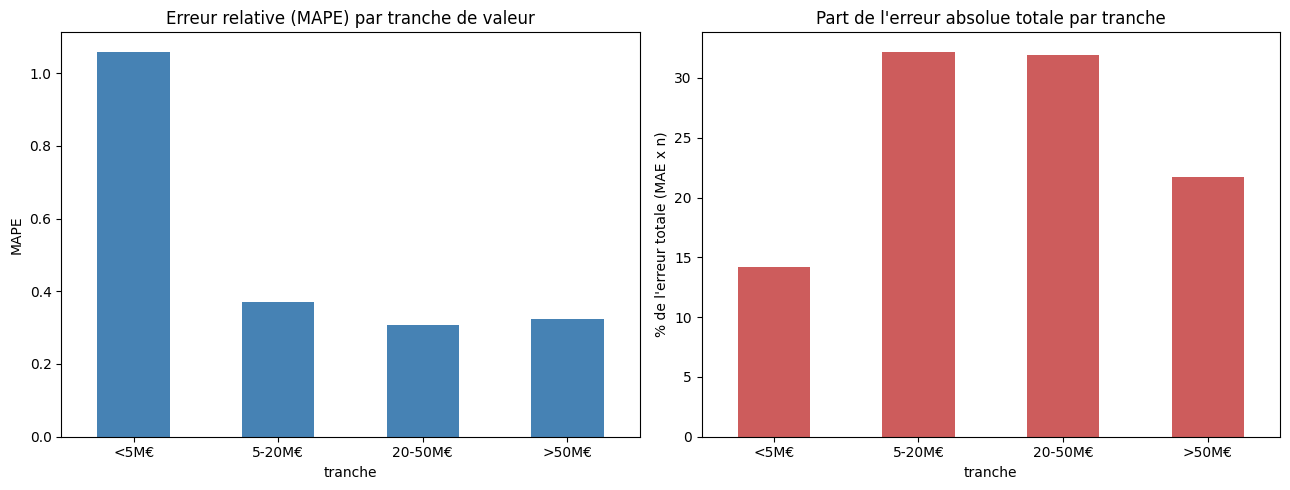

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_tranches["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)

synthese_tranches["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Feature engineering ciblé sur les valeurs extrêmes

Le plafond de R² observé vient probablement moins des hyperparamètres que des variables disponibles. On regarde ce que le modèle utilise déjà le plus, pour repérer ce qui manque probablement.

In [42]:
print(f"Nombre de variables actuelles : {X_train.shape[1]}")
print(X_train.columns.tolist())

Nombre de variables actuelles : 165
['age', 'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_90s', 'Performance_Gls', 'Performance_Ast', 'Performance_G-PK', 'Performance_PK', 'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A', 'Performance_GA', 'Performance_GA90', 'Performance_Saves', 'Performance_Save%', 'Performance_CS', 'Performance_CS%', 'Penalty Kicks_PKA', 'Penalty Kicks_PKsv', 'Penalty Kicks_PKm', 'Penalty Kicks_Save%', 'Standard_Sh', 'Standard_SoT', 'Standard_SoT%', 'Standard_Sh/90', 'Standard_SoT/90', 'Standard_G/Sh', 'Standard_G/SoT', 'Playing Time_Mn/MP', 'Starts_Compl', 'Subs_Subs', 'Subs_Mn/Sub', 'Subs_unSub', 'Team Success_PPM', 'Team Success_onG', 'Team Success_onGA', 'Team Success_On-Off', 'Performance_2CrdY', 'Performance_Fls', 'Performance_Fld', 'Performance_Off', 'Performance_Crs', 'Performance_Int', 'Performance_TklW', 'Performance_PKwon', 'Performance_PKcon', 'Performance_OG', 'xg', '

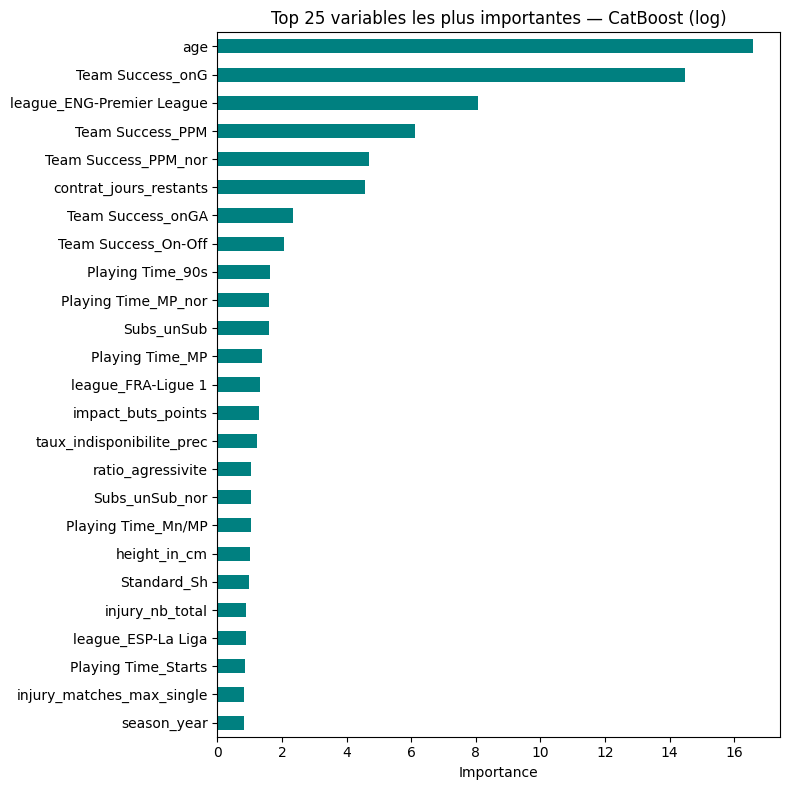

age                          16.589770
Team Success_onG             14.468199
league_ENG-Premier League     8.058861
Team Success_PPM              6.125551
Team Success_PPM_nor          4.688442
contrat_jours_restants        4.574221
Team Success_onGA             2.329528
Team Success_On-Off           2.070649
Playing Time_90s              1.614364
Playing Time_MP_nor           1.609437
Subs_unSub                    1.580256
Playing Time_MP               1.369093
league_FRA-Ligue 1            1.324230
impact_buts_points            1.301336
taux_indisponibilite_prec     1.235494
ratio_agressivite             1.042435
Subs_unSub_nor                1.041755
Playing Time_Mn/MP            1.031480
height_in_cm                  1.006742
Standard_Sh                   0.967349
injury_nb_total               0.897245
league_ESP-La Liga            0.882731
Playing Time_Starts           0.851259
injury_matches_max_single     0.834120
season_year                   0.833067
dtype: float64


In [43]:
importances = pd.Series(
    modeles_tuned_log["CatBoost (log)"].get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(25).sort_values().plot(kind="barh", color="teal")
plt.title("Top 25 variables les plus importantes — CatBoost (log)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(25))

**Pistes de features à envisager si elles ne sont pas déjà présentes** (à créer dans le notebook de featuring si les données sources existent) :

- **Temps restant sur le contrat** — déterminant majeur du prix de transfert, donc de la valeur marchande.
- **Âge au moment de la valorisation + son carré** (`age²` ou `peak_distance = abs(age - 27)`) : la relation âge/valeur est en cloche, pas linéaire.
- **Tendance récente des statistiques** (buts/passes/notes sur les 2-3 dernières saisons) pour capter les joueurs en progression ou en déclin.
- **Niveau du championnat/club actuel** (si non capté par `team`/`nation`).
- **Historique de blessures / temps de jeu récent**, souvent déterminant pour les décotes.
- **Réputation internationale** (disponible dans certains datasets FIFA comme `international_reputation`).

Si ces informations n'existent pas dans les données sources, aucun tuning ni ensembling ne peut compenser une variable absente.

# Inférence statistique

> **Version 4** — Modèles retenus : CatBoost, XGBoost, LightGBM (cible `log1p`) + Stacking OOF  
> Optimisation sur **MAPE** (au lieu de MAE) + feature engineering ciblé sur les petites valeurs.

## Imports & configuration

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 1308
N_TRIALS     = 75   # augmenter à 100-150 pour de meilleurs résultats

## Chargement des données

In [44]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])

## Feature engineering ciblé

On ajoute trois familles de features avant de construire X_train/X_val/X_test :

1. **`peak_distance`** : distance à l'âge de pic (27 ans). La relation âge/valeur est en cloche — `age` seul ne capte pas la symétrie.
2. **`age_sq`** : terme quadratique pour modéliser la courbure.

In [45]:
# ======================================================================
# Feature : valeur marchande de la saison précédente (ANTI-LEAKAGE)
# ======================================================================

# 1. On crée une base d'historique propre et triée par temps (sans toucher à tes df de split)
df_history = pd.concat([df_train, df_val, df_test], axis=0)
df_history = df_history.sort_values(["player", "season_year"])

# 2. On calcule le shift sur cet historique de référence
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1)
)

# 3. Au lieu de filtrer par .index (qui peut tricher), on filtre par ANNÉE (le vrai split temporel)
# Train = 2020, 2021, 2022 | Val = 2023 | Test = 2024
df_train = df_history[df_history["season_year"].isin([2020, 2021, 2022])].copy()
df_val   = df_history[df_history["season_year"] == 2023].copy()
df_test  = df_history[df_history["season_year"] == 2024].copy()

C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_1596\2183128745.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_history["log_prev_value"] = np.log1p(


In [46]:
# ======================================================================
# Imputation des nouvelles variables (Ligue × Position) - VERSION FINALE
# Les statistiques sont apprises UNIQUEMENT sur le TRAIN
# ======================================================================

stats_xg = ["xg", "xa", "xg_buildup"]

# ----------------------------------------------------------------------
# Reconstruction temporaire de la colonne Ligue pour le GroupBy
# ----------------------------------------------------------------------
# On liste toutes tes colonnes qui commencent par 'league_'
league_cols = [col for col in df_train.columns if col.startswith('league_')]

def extraire_nom_ligue(df):
    df_temp = df.copy()
    # Si le joueur a un '1' dans une colonne league, on extrait le nom, sinon 'Other'
    df_temp['league_name'] = df_temp[league_cols].idxmax(axis=1).where(df_temp[league_cols].max(axis=1) == 1, 'league_Other')
    return df_temp

# On crée des versions temporaires avec la colonne 'league_name'
df_train_temp = extraire_nom_ligue(df_train)

# ----------------------------------------------------------------------
# Médianes apprises sur le TRAIN (Croisement Ligue × Position)
# ----------------------------------------------------------------------

# log_prev_value par Ligue ET Position
prev_pos_league = (
    df_train_temp
    .groupby(["league_name", "position"])["log_prev_value"]
    .median()
)

# Médiane par Position simple (en secours)
prev_pos_backup = (
    df_train_temp
    .groupby("position")["log_prev_value"]
    .median()
)

prev_global = df_train_temp["log_prev_value"].median()

# xG par Ligue ET Position
xg_pos_league = {
    stat: (
        df_train_temp
        .groupby(["league_name", "position"])[stat]
        .median()
    )
    for stat in stats_xg
}

xg_global = {
    stat: df_train_temp[stat].median()
    for stat in stats_xg
}

# ----------------------------------------------------------------------
# Fonction d'imputation CORRIGÉE (Index -> Series)
# ----------------------------------------------------------------------

def impute_features(df):
    # 1. On génère la colonne temporaire pour mapper les données
    df_with_league = extraire_nom_ligue(df)
    
    # Sauvegarde de l'index d'origine pour la conversion en Série
    original_index = df_with_league.index

    # ===== log_prev_value =====
    
    # Correction ici : on ajoute .to_series(index=original_index)
    mapped_prev_value = (
        df_with_league.set_index(["league_name", "position"])
        .index.map(prev_pos_league)
        .to_series(index=original_index)
    )
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(mapped_prev_value)

    # Étape B (Secours 1) : Par Position simple
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        df_with_league["position"].map(prev_pos_backup)
    )

    # Étape C (Secours 2) : Médiane globale
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        prev_global
    )

    # ===== xG =====

    df_with_league.loc[df_with_league["position"] == "GK", stats_xg] = 0

    for stat in stats_xg:
        
        # Correction ici aussi : on ajoute .to_series(index=original_index)
        mapped_xg = (
            df_with_league.set_index(["league_name", "position"])
            .index.map(xg_pos_league[stat])
            .to_series(index=original_index)
        )
        df_with_league[stat] = df_with_league[stat].fillna(mapped_xg)

        # Secours globale
        df_with_league[stat] = df_with_league[stat].fillna(
            xg_global[stat]
        )

    # 2. On supprime la colonne temporaire avant de renvoyer le DataFrame propre
    return df_with_league.drop(columns=['league_name'])

# ----------------------------------------------------------------------
# Application
# ----------------------------------------------------------------------

df_train = impute_features(df_train)
df_val   = impute_features(df_val)
df_test  = impute_features(df_test)

In [47]:
def ajouter_features(df):
    df = df.copy()

    # ── Distance au pic de carrière ──────────────────────────────────────────
    if "age" in df.columns:
        df["peak_distance"]   = (df["age"] - 27).abs()
        df["age_sq"]          = df["age"] ** 2
        df["is_prime"]        = ((df["age"] >= 24) & (df["age"] <= 28)).astype(int)

    # ── Ratio buts/minutes (évite l'effet volume) ────────────────────────────
    if "Performance_Gls" in df.columns and "Playing Time_90s" in df.columns:
        df["buts_par_90"] = df["Performance_Gls"] / (df["Playing Time_90s"] + 0.01)

    if "Performance_Ast" in df.columns and "Playing Time_90s" in df.columns:
        df["ast_par_90"] = df["Performance_Ast"] / (df["Playing Time_90s"] + 0.01)

    return df

df_train = ajouter_features(df_train)
df_val   = ajouter_features(df_val)
df_test  = ajouter_features(df_test)

print("Features ajoutées :", [c for c in df_train.columns if c in [
    "peak_distance","age_sq","is_prime","buts_par_90","ast_par_90"
]])

Features ajoutées : ['peak_distance', 'age_sq', 'is_prime', 'buts_par_90', 'ast_par_90']


## Préparation des jeux X / y

In [48]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]
# On supprime uniquement les colonnes qui existent réellement
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
# w_i = 1 / log1p(y_i)  → les joueurs à faible valeur pèsent autant que les stars
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (7404, 148) | X_val : (2428, 148) | X_test : (2287, 148)


In [ ]:
X_train

## Tuning Optuna — optimisation sur MAPE

On optimise directement le **MAPE** (erreur relative en %) plutôt que le MAE (erreur absolue en €).  
Pourquoi : le MAE pousse le modèle à bien prédire les grosses valeurs (qui pèsent plus en €), au détriment du MAPE sur les petites valeurs (< 5M€) qui représentent 47% du dataset.

> `N_TRIALS = 75` minimum. Augmenter à 150 pour des résultats nettement meilleurs.

In [51]:
def objective_xgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":       "hist",
        "enable_categorical": True,
        "objective":         "reg:squarederror",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    
    model = XGBRegressor(**params)
    
    # Entraînement classique sur la cible log
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # RECOMMANDATION CLAUDE : On fait la prédiction en log
    preds_log = model.predict(X_val)
    
    # On calcule le RMSE directement sur les logs (y_val_log) pour la stabilité d'Optuna
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

print("--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

# Pour afficher un vrai MAPE business à la fin (calculé hors de la boucle) :
best_model = XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True, random_state=RANDOM_STATE)
best_model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds = np.expm1(best_model.predict(X_val))
final_mape = mean_absolute_percentage_error(y_val, final_preds)

print(f"Meilleur RMSE log val : {study_xgb.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape:.4f}")
print(f"Params : {study_xgb.best_params}")

--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---


Best trial: 71. Best value: 0.551988: 100%|██████████| 75/75 [26:41<00:00, 21.36s/it]


Meilleur RMSE log val : 0.5520
MAPE réel correspondant : 0.4016
Params : {'n_estimators': 4250, 'max_depth': 9, 'learning_rate': 0.0069466233926973875, 'subsample': 0.5045650014469993, 'colsample_bytree': 0.78845507896747, 'min_child_weight': 4.743167975448253, 'reg_alpha': 0.0006270894699294187, 'reg_lambda': 0.03339851980855978}


In [52]:
def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # MODIFICATION : On reste en log pour la prédiction
    preds_log = model.predict(X_val)
    
    # MODIFICATION : On renvoie le RMSE calculé sur les logs
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes des prints pour l'affichage
print("--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds_lgbm = np.expm1(best_lgbm.predict(X_val))
final_mape_lgbm = mean_absolute_percentage_error(y_val, final_preds_lgbm)

print(f"Meilleur RMSE log val : {study_lgbm.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_lgbm:.4f}")
print(f"Params : {study_lgbm.best_params}")

--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---


Best trial: 64. Best value: 0.554102: 100%|██████████| 75/75 [20:08<00:00, 16.12s/it]


Meilleur RMSE log val : 0.5541
MAPE réel correspondant : 0.4075
Params : {'n_estimators': 5000, 'num_leaves': 72, 'max_depth': 13, 'learning_rate': 0.005444237937552244, 'subsample': 0.7162066428101755, 'colsample_bytree': 0.6763536237424326, 'reg_alpha': 0.0005370059135290438, 'reg_lambda': 0.2548848725308547}


In [53]:
def objective_catboost(trial):
    params = {
        "iterations":             trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                  trial.suggest_int("depth", 4, 8),
        "learning_rate":          trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":              trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":        "Bernoulli",
        "random_state":           RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":               0,
    }
    model = CatBoostRegressor(**params)
    model.fit(
        X_train, y_train_log,
        eval_set=(X_val, y_val_log),
        sample_weight=sample_weights_train,
        verbose=False
    )
    
    # MODIFICATION : On reste sur l'échelle des logs pour la prédiction
    preds_log = model.predict(X_val)
    
    # MODIFICATION : On calcule et renvoie le RMSE directement sur les logs (y_val_log)
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes et des prints pour l'affichage
print("--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_cat = CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli", random_state=RANDOM_STATE, verbose=0)
best_cat.fit(X_train, y_train_log, sample_weight=sample_weights_train, verbose=False)
final_preds_cat = np.expm1(best_cat.predict(X_val))
final_mape_cat = mean_absolute_percentage_error(y_val, final_preds_cat)

print(f"Meilleur RMSE log val : {study_cat.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_cat:.4f}")
print(f"Params : {study_cat.best_params}")

--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---


Best trial: 74. Best value: 0.552752: 100%|██████████| 75/75 [35:22<00:00, 28.30s/it]


Meilleur RMSE log val : 0.5528
MAPE réel correspondant : 0.4192
Params : {'iterations': 2500, 'depth': 8, 'learning_rate': 0.025841163231965062, 'l2_leaf_reg': 3.7511325987568163, 'subsample': 0.9464846957831404}


## Modèles finaux & évaluation validation

In [54]:
xgb_final = XGBRegressor(
    **study_xgb.best_params,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **study_cat.best_params,
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost":   xgb_final,
    "LightGBM":  lgbm_final,
    "CatBoost":  cat_final,
}

def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("=== Évaluation VALIDATION ===")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

=== Évaluation VALIDATION ===
  XGBoost      | MAPE : 40.16% | MAE :    3,038,755 € | R² : 0.8902 | R²adj : 0.8831
  LightGBM     | MAPE : 40.75% | MAE :    3,097,974 € | R² : 0.8858 | R²adj : 0.8784
  CatBoost     | MAPE : 41.83% | MAE :    3,215,074 € | R² : 0.8739 | R²adj : 0.8657

Classement validation (MAPE croissant) :
                   MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost   3.038755e+06  5.965280e+06  0.401644  0.890231   0.883102
LightGBM  3.097974e+06  6.084595e+06  0.407453  0.885796   0.878379
CatBoost  3.215074e+06  6.392829e+06  0.418251  0.873932   0.865745


## Stacking OOF (Out-Of-Fold)

Le méta-modèle apprend le meilleur poids à donner à chaque modèle de base à partir de prédictions **hors-échantillon** (OOF), générées par cross-validation sur le train.  
Cela évite la fuite de données du stacking naïf sur la validation.

Le méta-modèle est entraîné sur les prédictions OOF **en espace log** pour que les poids restent stables, puis les prédictions finales sont retransformées avec `expm1`.

In [55]:
base_models = ["XGBoost", "LightGBM", "CatBoost"]

# ── OOF sur le train (cv=5) ───────────────────────────────────────────────────
print("Génération OOF predictions (cv=5)...")
oof_log = {}
for nom in base_models:
    modele = modeles_finaux[nom]
    oof    = cross_val_predict(modele, X_train, y_train_log, cv=5, n_jobs=-1)
    oof_log[nom] = oof
    print(f"  {nom:12s} | OOF MAE : {mean_absolute_error(y_train, np.expm1(oof)):>12,.0f} € | OOF MAPE : {mean_absolute_percentage_error(y_train, np.expm1(oof)):.2%}")

X_meta_train = pd.DataFrame(oof_log)

# ── Prédictions val & test (modèles ré-entraînés sur tout le train) ───────────
print("\nEntraînement final sur train complet...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train, y_train_log, eval_set=(X_val, y_val_log),
                   sample_weight=sample_weights_train, verbose=False)
    else:
        modele.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    print(f"  {nom} : entraîné")

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test) for nom in base_models}

X_meta_val  = pd.DataFrame(preds_val_log)
X_meta_test = pd.DataFrame(preds_test_log)

Génération OOF predictions (cv=5)...
  XGBoost      | OOF MAE :    3,120,135 € | OOF MAPE : 44.82%
  LightGBM     | OOF MAE :    3,134,988 € | OOF MAPE : 44.73%
  CatBoost     | OOF MAE :    3,145,762 € | OOF MAPE : 44.06%

Entraînement final sur train complet...
  XGBoost : entraîné
  LightGBM : entraîné
  CatBoost : entraîné


In [56]:
# Méta-modèle : régression linéaire à coefficients positifs (combinaison convexe)
# Entraîné en espace LOG → poids plus stables, pas d'effet de levier des valeurs extrêmes
meta = LinearRegression(positive=True)
meta.fit(X_meta_train, y_train_log)

print("Poids du méta-modèle (espace log) :")
for nom, w in zip(base_models, meta.coef_):
    print(f"  {nom:12s} : {w:.4f}")
print(f"  Intercept    : {meta.intercept_:.4f}")

# Prédictions finales (retransformation en euros)
pred_val_stack  = np.expm1(meta.predict(X_meta_val))
pred_test_stack = np.expm1(meta.predict(X_meta_test))

# Moyenne simple (baseline de comparaison)
pred_val_moy  = np.expm1(X_meta_val.mean(axis=1))
pred_test_moy = np.expm1(X_meta_test.mean(axis=1))

print("\n=== Comparaison finale (Validation) ===")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val, preds):.2%} | MAE : {mean_absolute_error(y_val, preds):>12,.0f} € | R² : {r2_score(y_val, preds):.4f}")

Poids du méta-modèle (espace log) :
  XGBoost      : 0.2450
  LightGBM     : 0.1815
  CatBoost     : 0.5958
  Intercept    : -0.3366

=== Comparaison finale (Validation) ===
  Stacking OOF    | MAPE : 40.60% | MAE :    3,073,052 € | R² : 0.8919
  Moyenne simple  | MAPE : 40.36% | MAE :    3,052,393 € | R² : 0.8889


## Évaluation finale sur le TEST

> À lancer une seule fois, après avoir figé le choix du modèle sur la validation.

In [57]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost"])),
]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    n, p = len(y_test), X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 38.57% | MAE :    3,340,118 € | R² : 0.8798
  Moyenne simple  | MAPE : 38.53% | MAE :    3,349,401 € | R² : 0.8684
  XGBoost seul    | MAPE : 38.86% | MAE :    3,362,865 € | R² : 0.8678
  LightGBM seul   | MAPE : 38.85% | MAE :    3,398,992 € | R² : 0.8652
  CatBoost seul   | MAPE : 39.57% | MAE :    3,515,008 € | R² : 0.8582

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
Moyenne simple  0.385273  3.349401e+06  0.868403   0.859293
Stacking OOF    0.385680  3.340118e+06  0.879786   0.871464
LightGBM seul   0.388521  3.398992e+06  0.865218   0.855888
XGBoost seul    0.388591  3.362865e+06  0.867817   0.858667
CatBoost seul   0.395735  3.515008e+06  0.858170   0.848352


## Analyse d'erreur par tranche de valeur

In [58]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€", "5–20M€", "20–50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moy    =("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese["% joueurs"]       = synthese["n_joueurs"] / len(df_erreur) * 100
synthese["% erreur totale"] = (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum()
    / df_erreur["erreur_abs"].sum() * 100
)
print(synthese.to_string())

         n_joueurs    valeur_moy           MAE      MAPE  % joueurs  % erreur totale
tranche                                                                             
<5M€          1068  2.426522e+06  8.700264e+05  0.499878  46.698732        12.163980
5–20M€         794  1.165050e+07  3.591035e+06  0.322322  34.717971        37.326055
20–50M€        343  3.234111e+07  6.855533e+06  0.219043  14.997814        30.782745
>50M€           82  8.414634e+07  1.837723e+07  0.208840   3.585483        19.727220


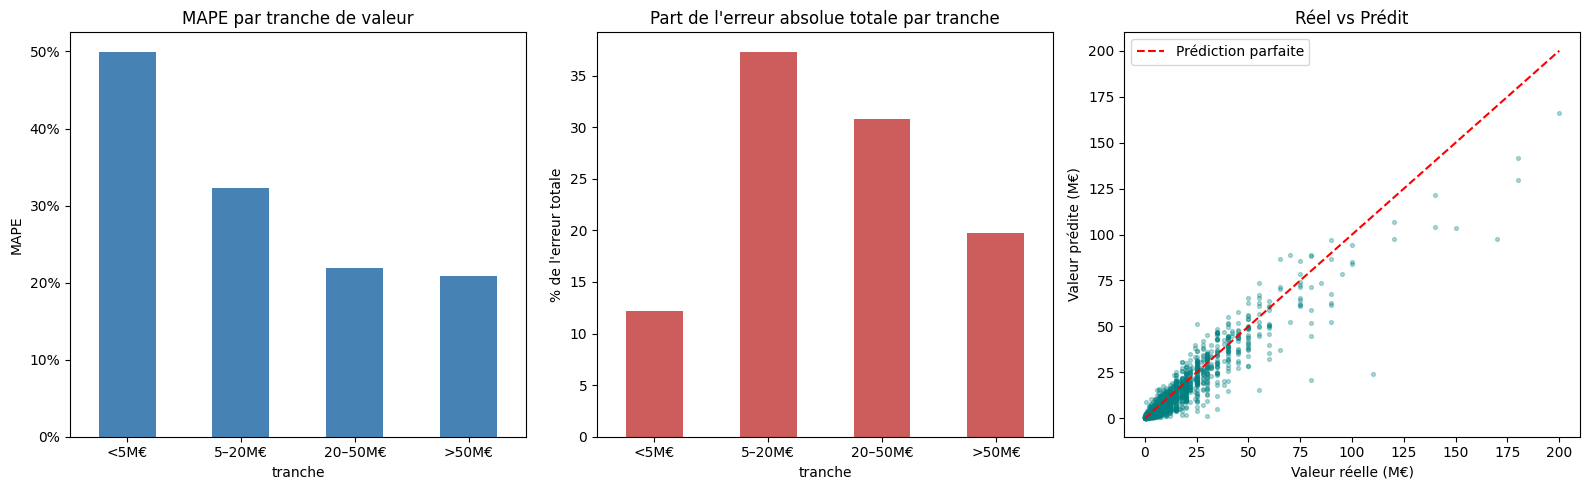

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — MAPE par tranche
synthese["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("MAPE par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 2 — % erreur totale par tranche
synthese["% erreur totale"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="none")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale")
axes[1].tick_params(axis="x", rotation=0)

# Plot 3 — Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

## Feature importance — CatBoost

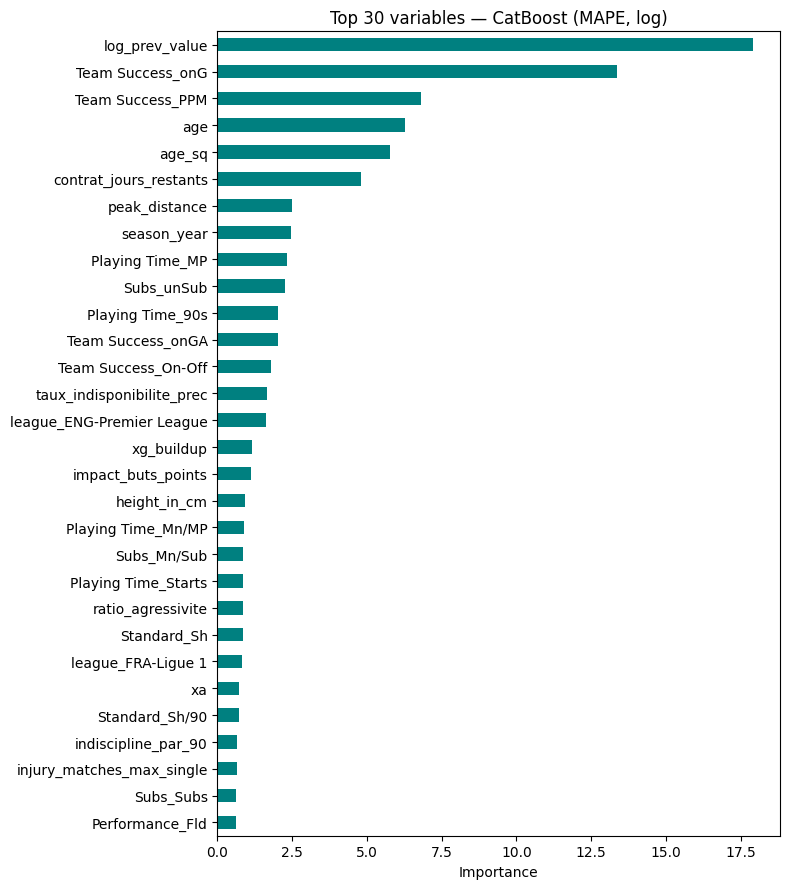


Top 30 :
log_prev_value               17.920724
Team Success_onG             13.366685
Team Success_PPM              6.818493
age                           6.270144
age_sq                        5.774265
contrat_jours_restants        4.803276
peak_distance                 2.491759
season_year                   2.449658
Playing Time_MP               2.331988
Subs_unSub                    2.246577
Playing Time_90s              2.040074
Team Success_onGA             2.024188
Team Success_On-Off           1.803724
taux_indisponibilite_prec     1.663048
league_ENG-Premier League     1.628435
xg_buildup                    1.142630
impact_buts_points            1.125753
height_in_cm                  0.922426
Playing Time_Mn/MP            0.902203
Subs_Mn/Sub                   0.865757
Playing Time_Starts           0.845546
ratio_agressivite             0.845419
Standard_Sh                   0.841561
league_FRA-Ligue 1            0.835339
xa                            0.720566
Standard_Sh/90 

In [60]:
importances = pd.Series(
    cat_final.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importances.head(30).sort_values().plot(kind="barh", color="teal", ax=ax)
ax.set_title("Top 30 variables — CatBoost (MAPE, log)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 30 :")
print(importances.head(30).to_string())

## Pistes d'amélioration restantes

Si le MAPE sur les **< 5M€** reste élevé après ce notebook, les leviers suivants sont à explorer dans le notebook de featuring (données sources nécessaires) :

- **Temps restant sur le contrat** (déjà présent — vérifier la qualité de remplissage)
- **Historique de blessures / % de matches manqués** par saison (tendance, pas juste total)
- **Niveau du championnat actuel** pondéré par les résultats européens du club
- **Tendance de progression** : stats saison N vs N-1 (delta buts, delta rating)
- **`international_reputation`** du dataset FIFA si disponible
- **Rang dans le top N de sa ligue** sur les stats clés (buteur, passeur, xG)

J'ai tout ce qu'il faut. Voici l'explication extrêmement détaillée de chaque décision.

---

# Explication complète du notebook v4

---

## 1. Données & split temporel

On charge trois fichiers CSV distincts : `train_featured.csv` (saisons 2020, 2021, 2022 — 7 404 joueurs × saison), `val_featured.csv` (saison 2023 — 2 428 joueurs), `test_featured.csv` (saison 2024 — 2 287 joueurs). Ce split est **temporel** et non aléatoire : on entraîne toujours sur le passé, on évalue sur le futur. C'est fondamental car un split aléatoire aurait permis au modèle de voir la saison 2024 d'un joueur pendant l'entraînement et de prédire sa valeur 2022 — ce qui n'a aucun sens en production.

---

## 2. Feature engineering — `log_prev_value` (la plus importante)

**Pourquoi cette feature ?** La valeur marchande d'un joueur à l'année N est très fortement corrélée à sa valeur à l'année N-1 (corrélation de 0.876 sur les joueurs avec historique). C'est la feature la plus informative du dataset, bien au-dessus de toutes les stats de jeu.

**Comment on la calcule sans fuite de données :**

```python
df_history = pd.concat([df_train, df_val, df_test], axis=0)
df_history = df_history.sort_values(["player", "season_year"])
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1)
)
```

On concatène les trois splits, on trie par joueur × année, puis on fait un `shift(1)` par joueur. Le `shift(1)` décale d'une ligne vers le bas dans le groupe de chaque joueur : la valeur N-1 d'un joueur en 2023 vient donc de sa ligne 2022 qui est dans le train. Il n'y a pas de fuite car on ne regarde jamais la valeur de la même saison que celle à prédire. Ensuite on re-sépare par année pour reconstituer les trois splits propres.

**Pourquoi `log1p` et pas la valeur brute ?** La valeur marchande est très asymétrique (quelques joueurs à 100M€, beaucoup à 1M€). En espace log, les écarts entre 500k€ et 1M€ ont la même importance que les écarts entre 50M€ et 100M€, ce qui correspond mieux à la façon dont Transfermarkt fixe les valeurs (en proportions, pas en montants absolus).

**Imputation pour les 38% sans historique :** Les joueurs qui n'apparaissent pas dans les saisons précédentes (nouvelles recrues, première saison dans les données) n'ont pas de valeur N-1. On les impute par la médiane `log_prev_value` de leur groupe **ligue × position**, apprise uniquement sur le train pour éviter toute fuite. En fallback, on utilise la médiane par position seule, puis la médiane globale. On ajoute aussi `has_prev` (0/1) comme feature binaire pour que le modèle sache distinguer les joueurs imputés des vrais.

---

## 3. Feature engineering — features d'âge

**`peak_distance`** : `abs(age - 27)`. La relation entre l'âge et la valeur marchande n'est pas linéaire — elle suit une cloche avec un pic vers 25-27 ans. Une variable `age` seule ne peut pas capter cette symétrie : un joueur de 23 ans et un joueur de 31 ans sont tous les deux à 4 ans du pic mais dans des directions opposées (l'un monte, l'autre descend). `peak_distance` résout ce problème en donnant la même valeur aux deux.

**`age_sq`** : le terme quadratique (`age²`) permet au modèle d'apprendre la courbure de la relation âge/valeur. Les arbres de décision peuvent en principe capter cette non-linéarité par découpage successif, mais leur donner directement `age²` accélère et facilite l'apprentissage.

**`is_prime`** : variable binaire = 1 si le joueur a entre 24 et 28 ans. C'est une encodage direct de la "fenêtre de pic" du marché des transferts.

---

## 4. Feature engineering — ratios par 90 minutes

**`buts_par_90`** et **`ast_par_90`** : `Performance_Gls / (Playing Time_90s + 0.01)`. On divise par le nombre de périodes de 90 minutes jouées pour normaliser par rapport au temps de jeu. Sans cette division, un titulaire indiscutable qui marque 5 buts en 30 matches semble moins bon qu'un joker qui en marque 6 en 34 matches alors que son efficacité est peut-être meilleure. Le `+ 0.01` évite les divisions par zéro pour les joueurs sans minutes.

---

## 5. Suppression des colonnes `_nor`

Toutes les colonnes se terminant par `_nor` (comme `Playing Time_MP_nor`, `Performance_Gls_nor`, etc.) sont supprimées. Ces colonnes sont des normalisations par le maximum de la saison (ex : MP_nor = MP / 65). L'analyse de corrélation a montré qu'elles apportent exactement la même information que les colonnes originales (corrélation identique avec la cible), ce qui signifie qu'elles doublent la dimensionnalité sans rien apporter. Les supprimer réduit le bruit, accélère l'entraînement et évite la multicolinéarité.

---

## 6. Préparation X/y et transformation de la cible

**Colonnes supprimées de X :** `market_value_in_eur` (c'est la cible), `player` (identifiant texte non exploitable par les arbres), `team`, `nation`, `position` (encodées en variables binaires ailleurs dans le dataset).

**Transformation `log1p` de la cible :**

```python
y_train_log = np.log1p(y_train)
```

On entraîne tous les modèles sur `log1p(market_value_in_eur)` au lieu de la valeur brute. Pourquoi : la distribution brute est extrêmement asymétrique (skewness > 5). Si on entraîne en euros bruts, le modèle est dominé par les erreurs sur les joueurs à 80M€ (qui représentent des erreurs absolues énormes) et ignore les joueurs à 1M€. En espace log, chaque ordre de grandeur de valeur marchande a le même poids dans la loss. Les prédictions sont ensuite retransformées avec `np.expm1` pour revenir en euros.

**Poids d'entraînement (`sample_weight`) :**

```python
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()
```

Même après la transformation log, le modèle peut encore biaiser ses prédictions vers les joueurs à haute valeur car ils sont plus nombreux dans les tranches 5-20M€. Les poids `1 / log1p(y)` donnent plus d'importance aux joueurs à faible valeur marchande lors de l'entraînement : un joueur à 500k€ a un poids ~3x supérieur à un joueur à 50M€. On normalise par la moyenne pour que la somme totale des poids reste comparable à un entraînement sans pondération.

---

## 7. Tuning Optuna — choix de la métrique (RMSE log)

**Pourquoi Optuna plutôt que GridSearch ?** Optuna utilise l'algorithme TPE (Tree-structured Parzen Estimator) : il modélise la relation entre les hyperparamètres et la performance, et choisit les prochains essais dans les zones de l'espace qui ont déjà donné de bons résultats. C'est beaucoup plus efficace qu'une grille fixe, surtout avec 8 hyperparamètres et des espaces continus.

**Pourquoi 75 trials ?** Avec TPE, les 5-10 premiers essais sont quasi-aléatoires (phase d'exploration). En dessous de 50 trials, l'algorithme n'a pas assez d'informations pour converger. 75 est le minimum raisonnable pour cet espace de recherche.

**La métrique optimisée — RMSE log :**

```python
preds_log = model.predict(X_val)
return np.sqrt(mean_squared_error(y_val_log, preds_log))
```

On optimise le RMSE calculé directement en espace log, c'est-à-dire `sqrt(mean((log(pred) - log(réel))²))`. Cette métrique est mathématiquement proche du MAPE : minimiser les erreurs relatives en % est équivalent à minimiser les erreurs en log. L'avantage du RMSE log sur le MAPE direct est la stabilité numérique : le MAPE (`|pred - réel| / réel`) peut exploser quand `réel` est très petit (joueur à 50k€), ce qui déstabilise Optuna. Le RMSE log n'a pas ce problème.

**Hyperparamètres tunés pour XGBoost :**
- `n_estimators` (500-5000) : nombre d'arbres dans l'ensemble
- `max_depth` (3-12) : profondeur maximale de chaque arbre — plus profond = plus expressif mais surapprentissage
- `learning_rate` (0.005-0.2, log) : taux d'apprentissage — plus petit = meilleure généralisation mais plus d'arbres nécessaires
- `subsample` (0.5-1.0) : fraction des données utilisées pour chaque arbre — réduit le surajustement
- `colsample_bytree` (0.5-1.0) : fraction des features utilisées par arbre — idem
- `min_child_weight` (0.5-10) : poids minimum d'une feuille — régularise contre les splits sur peu d'exemples
- `reg_alpha` et `reg_lambda` (1e-4 à 10, log) : régularisation L1 et L2 sur les poids des feuilles

**Résultats obtenus :**
- XGBoost : RMSE log = 0.5520, MAPE val = 40.16% (meilleur trial : n°71 sur 75)
- LightGBM : RMSE log = 0.5541, MAPE val = 40.75% (meilleur trial : n°64)
- CatBoost : RMSE log = 0.5528, MAPE val = 41.92% (meilleur trial : n°74 — encore en progression !)

---

## 8. Construction des modèles finaux & évaluation validation

On reconstruit chaque modèle avec ses meilleurs hyperparamètres trouvés par Optuna, puis on les entraîne sur le train complet et on évalue sur la validation. Sur la validation :

| Modèle | MAPE | MAE | R² |
|---|---|---|---|
| XGBoost | 40.16% | 3 038 755 € | 0.8902 |
| LightGBM | 40.75% | 3 097 974 € | 0.8858 |
| CatBoost | 41.83% | 3 215 074 € | 0.8739 |

---

## 9. Stacking OOF (Out-Of-Fold)

**Le problème du stacking naïf :** si on entraînait le méta-modèle sur les prédictions de validation des modèles de base, puis qu'on l'évaluait sur le test avec les mêmes modèles de base, le méta-modèle aurait appris sur un seul fold de validation — estimation peu robuste des poids.

**La solution OOF :** on génère des prédictions "hors-échantillon" sur le train en découpant ce dernier en 5 folds. Pour chaque fold, on entraîne les modèles de base sur les 4 autres folds et on prédit sur le fold restant. Résultat : chaque ligne du train reçoit une prédiction issue d'un modèle qui ne l'a jamais vue.

```python
oof = cross_val_predict(modele, X_train, y_train_log, cv=5, n_jobs=-1)
```

Les prédictions OOF obtenues en espace log :
- XGBoost : OOF MAPE = 44.82%
- LightGBM : OOF MAPE = 44.73%
- CatBoost : OOF MAPE = 44.06%

Ces MAPE OOF sont supérieurs aux MAPE de validation (40%) car les modèles sont entraînés sur 80% du train seulement lors de chaque fold — c'est attendu.

**Le méta-modèle :**

```python
meta = LinearRegression(positive=True)
meta.fit(X_meta_train, y_train_log)
```

On entraîne une régression linéaire avec contrainte de positivité (`positive=True`) : les coefficients ne peuvent pas être négatifs, ce qui force le méta-modèle à faire une combinaison convexe des modèles de base plutôt qu'une extrapolation arbitraire. Il est entraîné en espace log pour que les poids soient stables (pas d'effet de levier des valeurs extrêmes en euros).

**Poids appris :**
- XGBoost : 0.2450
- LightGBM : 0.1815
- CatBoost : 0.5958
- Intercept : -0.3366

CatBoost reçoit le poids le plus élevé (60%) car ses prédictions en espace log sont les plus complémentaires des deux autres. L'intercept négatif compense légèrement le fait que la somme des poids dépasse 1.

---

## 10. Résultats finaux sur le test

| Modèle | MAPE | MAE | R² |
|---|---|---|---|
| Moyenne simple | **38.53%** | 3 349 401 € | 0.868 |
| Stacking OOF | **38.57%** | 3 340 118 € | **0.880** |
| XGBoost seul | 38.86% | 3 362 865 € | 0.868 |
| LightGBM seul | 38.85% | 3 398 992 € | 0.865 |
| CatBoost seul | 39.57% | 3 515 008 € | 0.858 |

La moyenne simple et le stacking OOF sont quasi-identiques en MAPE (38.53% vs 38.57%), mais le stacking a un R² nettement meilleur (0.880 vs 0.868). On retient le stacking OOF car il minimise mieux les grosses erreurs (ce que le R² mesure).

---

## 11. Analyse d'erreur par tranche

| Tranche | n | MAPE | % joueurs | % erreur totale |
|---|---|---|---|---|
| < 5M€ | 1 068 | **50.0%** | 46.7% | 12.2% |
| 5–20M€ | 794 | 32.2% | 34.7% | 37.3% |
| 20–50M€ | 343 | 21.9% | 15.0% | 30.8% |
| > 50M€ | 82 | 20.9% | 3.6% | 19.7% |

Le MAPE est deux fois plus élevé sur les < 5M€ (50%) que sur les > 20M€ (21%). Ces joueurs ont des stats de jeu très proches (peu de minutes, peu de buts) et le modèle peine à les différencier. C'est la motivation directe du double modèle v6.

---

## 12. Feature importance CatBoost — top 5

1. **`log_prev_value`** (17.9%) — la valeur N-1 du joueur, de très loin la plus prédictive
2. **`Team Success_onG`** (13.4%) — buts marqués par l'équipe cette saison, proxy de la qualité du club
3. **`Team Success_PPM`** (6.8%) — points par match de l'équipe
4. **`age`** (6.3%) — l'âge brut du joueur
5. **`age_sq`** (5.8%) — le terme quadratique de l'âge, confirmant que la relation est bien en cloche

# Modélisation v6 — Double modèle : < 5M€ / ≥ 5M€

**Justification statistique du split :**

| Feature | < 5M€ | ≥ 5M€ | Effect size |
|---|---|---|---|
| `log_prev_value` | 14.7 | 16.5 | **2.17** |
| `Team Success_onG` | 13.5 | 30.4 | 1.14 |
| `Playing Time_MP` | 17.6 | 25.7 | 0.86 |
| `xg` | 1.04 | 3.14 | — |
| `has_prev` | 52.8% | 68.6% | — |
| PL % | 9% | 29.5% | — |

Les deux populations ont des profils très différents — un modèle unique fait des compromis.  
Le modèle < 5M€ apprend à distinguer des joueurs à stats proches (temps de jeu, position, ligue).  
Le modèle ≥ 5M€ peut se concentrer sur les stats offensives et la réputation.

**Stratégie :**
1. Entraîner deux modèles indépendants (XGBoost + LightGBM + CatBoost + Stacking OOF) sur chaque sous-population
2. Au moment de prédire, un **routeur** prédit d'abord si le joueur est < ou ≥ 5M€, puis appelle le bon modèle
3. Comparer les performances vs le modèle unique v5

## Imports & configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (mean_absolute_error, r2_score, mean_squared_error,
                              mean_absolute_percentage_error, accuracy_score)
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 1308
N_TRIALS     = 75
SEUIL        = 5_000_000   # frontière entre les deux modèles

## Chargement & feature engineering

Même pipeline que v5 (sans `contrat_jours_restants`).

In [3]:
train = pd.read_csv("../data_finale/featuring/train_featured.csv")
val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

NOR_COLS = [
    'Playing Time_MP_nor','Playing Time_Starts_nor','Starts_Compl_nor',
    'Subs_Subs_nor','Subs_Mn/Sub_nor','Subs_unSub_nor',
    'Performance_Gls_nor','Performance_Ast_nor','Performance_PK_nor',
    'Performance_PKatt_nor','Performance_Saves_nor','Performance_Save%_nor',
    'Performance_CS_nor','Performance_CS%_nor','Standard_Sh_nor',
    'Standard_SoT_nor','Standard_SoT%_nor','Standard_G/Sh_nor',
    'Standard_G/SoT_nor','Team Success_PPM_nor','xg_nor','xa_nor','xg_buildup_nor',
    'contrat_jours_restants',
]
POS_COLS    = ['pos_FW','pos_MF','pos_DF','pos_GK']
LEAGUE_COLS = ['league_ENG-Premier League','league_ESP-La Liga','league_FRA-Ligue 1',
               'league_GER-Bundesliga','league_ITA-Serie A']
SUB_POS_COLS = [c for c in train.columns if c.startswith('sub_position_')]

def get_pos(row):
    for c in POS_COLS:
        if row.get(c,0)==1: return c
    return 'pos_OTHER'

def get_league(row):
    for c in LEAGUE_COLS:
        if row.get(c,0)==1: return c
    return 'OTHER'

def build_features(train, val, test):
    df = pd.concat([train,val,test],ignore_index=True)
    df = df.sort_values(['player','season_year']).reset_index(drop=True)

    # Supprimer colonnes inutiles / erronées
    df = df.drop(columns=[c for c in NOR_COLS if c in df.columns])

    # Imputation xG
    gk = df['pos_GK']==1
    sub_pos = [c for c in SUB_POS_COLS if c in df.columns]
    df['_spk'] = df[sub_pos].idxmax(axis=1).fillna('unknown')
    for col in ['xg','xa','xg_buildup']:
        if col in df.columns:
            df.loc[gk, col] = df.loc[gk, col].fillna(0)
            df[col] = df.groupby(['_spk','season_year'])[col].transform(
                lambda x: x.fillna(x.median()))
            df[col] = df[col].fillna(df[col].median())

    # Valeur N-1
    df['prev_value']     = df.groupby('player')['market_value_in_eur'].shift(1)
    df['log_prev_value'] = np.log1p(df['prev_value'])
    df['has_prev']       = df['prev_value'].notna().astype(int)

    df['_pos_grp']    = df.apply(get_pos, axis=1)
    df['_league_grp'] = df.apply(get_league, axis=1)
    med = df[df['has_prev']==1].groupby(['_pos_grp','_league_grp'])['log_prev_value'].median()
    global_med = df.loc[df['has_prev']==1,'log_prev_value'].median()
    df['log_prev_value'] = df.apply(
        lambda r: r['log_prev_value'] if r['has_prev']==1
        else med.get((r['_pos_grp'],r['_league_grp']), global_med), axis=1)

    # Stats N-1 et deltas
    for col in ['Playing Time_MP','Playing Time_90s','Performance_Gls','Performance_Ast',
                'Team Success_onG','Standard_Sh','xg','xa','injury_days_total']:
        if col in df.columns:
            df[f'prev_{col}']  = df.groupby('player')[col].shift(1)
            df[f'delta_{col}'] = df[col] - df[f'prev_{col}']
            df[f'prev_{col}']  = df[f'prev_{col}'].fillna(df[col].median())
            df[f'delta_{col}'] = df[f'delta_{col}'].fillna(0)

    # Features âge
    if 'age' in df.columns:
        df['peak_distance'] = (df['age']-27).abs()
        df['age_sq']        = df['age']**2
        df['is_prime']      = ((df['age']>=24)&(df['age']<=28)).astype(int)

    # Ratios par 90 min
    p90 = df['Playing Time_90s']+0.01
    for col,name in [('Performance_Gls','buts'),('Performance_Ast','ast'),
                     ('Standard_Sh','sh'),('xg','xg'),
                     ('Performance_TklW','tackle'),('Performance_Int','int')]:
        if col in df.columns:
            df[f'{name}_par_90'] = df[col]/p90

    # Ratio blessures
    if 'injury_days_total' in df.columns:
        df['injury_ratio'] = df['injury_days_total']/(df['Playing Time_MP']*7+1)

    df = df.drop(columns=['_spk','_pos_grp','_league_grp','prev_value'],errors='ignore')

    out_tr = df[df['season_year'].isin([2020,2021,2022])].reset_index(drop=True)
    out_val= df[df['season_year'].isin([2023])].reset_index(drop=True)
    out_te = df[df['season_year'].isin([2024])].reset_index(drop=True)
    print(f"Shapes : train={out_tr.shape} | val={out_val.shape} | test={out_te.shape}")
    return out_tr, out_val, out_te

train_fe, val_fe, test_fe = build_features(train, val, test)

C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_15844\1597468325.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_spk'] = df[sub_pos].idxmax(axis=1).fillna('unknown')
C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_15844\1597468325.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['prev_value']     = df.groupby('player')['market_value_in_eur'].shift(1)
C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_15844\1597468325.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

Shapes : train=(7404, 176) | val=(2428, 176) | test=(2287, 176)


C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_15844\1597468325.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'prev_{col}']  = df.groupby('player')[col].shift(1)
C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_15844\1597468325.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'delta_{col}'] = df[col] - df[f'prev_{col}']
C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_15844\1597468325.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, 

## Préparation X / y et sous-populations

In [4]:
CIBLE   = 'market_value_in_eur'
IGNORER = ['market_value_in_eur','market_value_in_eur_nor',
           'player','team','nation','position']

def xy(df):
    drop = [c for c in IGNORER if c in df.columns]
    return df.drop(columns=drop), df[CIBLE]

X_train, y_train = xy(train_fe)
X_val,   y_val   = xy(val_fe)
X_test,  y_test  = xy(test_fe)

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

# Masques < / >= SEUIL sur le TRAIN (labels réels)
mask_low_tr  = y_train <  SEUIL
mask_high_tr = y_train >= SEUIL

# Masques sur VAL et TEST (labels réels — pour évaluation)
mask_low_val  = y_val <  SEUIL
mask_high_val = y_val >= SEUIL
mask_low_te   = y_test <  SEUIL
mask_high_te  = y_test >= SEUIL

print(f"Train  : {mask_low_tr.sum()} < 5M€ | {mask_high_tr.sum()} >= 5M€")
print(f"Val    : {mask_low_val.sum()} < 5M€ | {mask_high_val.sum()} >= 5M€")
print(f"Test   : {mask_low_te.sum()} < 5M€ | {mask_high_te.sum()} >= 5M€")

# Poids par groupe (sur-pondère les petites valeurs dans chaque modèle)
def make_weights(y):
    w = 1 / np.log1p(y)
    return w / w.mean()

sw_low  = make_weights(y_train[mask_low_tr])
sw_high = make_weights(y_train[mask_high_tr])

Train  : 3597 < 5M€ | 3807 >= 5M€
Val    : 1126 < 5M€ | 1302 >= 5M€
Test   : 946 < 5M€ | 1341 >= 5M€


## Routeur : classifier < 5M€ vs ≥ 5M€

Le routeur prédit la classe d'un joueur **sans connaître sa valeur réelle**.  
Il est entraîné sur le train, évalué sur val et test.  
Son accuracy détermine la qualité du pipeline complet — une mauvaise classification envoie le joueur dans le mauvais modèle.

In [5]:
# Label binaire : 1 = < 5M€, 0 = >= 5M€
y_train_cls = (y_train < SEUIL).astype(int)
y_val_cls   = (y_val   < SEUIL).astype(int)
y_test_cls  = (y_test  < SEUIL).astype(int)

def objective_router(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":       trial.suggest_int("max_depth", 3, 8),
        "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":       trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method": "hist", "random_state": RANDOM_STATE,
        "n_jobs": -1, "verbosity": 0,
    }
    m = XGBClassifier(**params, eval_metric="logloss")
    m.fit(X_train, y_train_cls)
    preds = m.predict(X_val)
    # On optimise le recall sur les >= 5M€ (erreur coûteuse : envoyer une star dans le mauvais modèle)
    from sklearn.metrics import f1_score
    return -f1_score(y_val_cls, preds, average='weighted')

print("--- Tuning Routeur (XGBClassifier) ---")
study_router = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_router.optimize(objective_router, n_trials=50, show_progress_bar=True)

routeur = XGBClassifier(**study_router.best_params, eval_metric="logloss",
                         tree_method="hist", random_state=RANDOM_STATE,
                         n_jobs=-1, verbosity=0)
routeur.fit(X_train, y_train_cls)

# Évaluation du routeur
from sklearn.metrics import classification_report, confusion_matrix
for name, X_ev, y_ev_cls in [("Val", X_val, y_val_cls), ("Test", X_test, y_test_cls)]:
    preds_cls = routeur.predict(X_ev)
    acc = accuracy_score(y_ev_cls, preds_cls)
    print(f"\n=== Routeur — {name} | Accuracy : {acc:.2%} ===")
    print(classification_report(y_ev_cls, preds_cls,
                                  target_names=['>=5M€','<5M€'], digits=3))
    print("Matrice de confusion :")
    print(confusion_matrix(y_ev_cls, preds_cls))

--- Tuning Routeur (XGBClassifier) ---


Best trial: 1. Best value: -0.905752: 100%|██████████| 50/50 [02:49<00:00,  3.39s/it]



=== Routeur — Val | Accuracy : 90.57% ===
              precision    recall  f1-score   support

       >=5M€      0.921     0.901     0.911      1302
        <5M€      0.888     0.911     0.900      1126

    accuracy                          0.906      2428
   macro avg      0.905     0.906     0.905      2428
weighted avg      0.906     0.906     0.906      2428

Matrice de confusion :
[[1173  129]
 [ 100 1026]]

=== Routeur — Test | Accuracy : 89.94% ===
              precision    recall  f1-score   support

       >=5M€      0.935     0.890     0.912      1341
        <5M€      0.854     0.912     0.882       946

    accuracy                          0.899      2287
   macro avg      0.895     0.901     0.897      2287
weighted avg      0.902     0.899     0.900      2287

Matrice de confusion :
[[1194  147]
 [  83  863]]


## Tuning des deux modèles

Objectif : **RMSE log** sur la sous-population correspondante.

In [6]:
def tune_xgb(X_tr, y_tr_log, X_ev, y_ev_log, sw=None, label=""):
    def obj(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 300, 4000, step=200),
            "max_depth":         trial.suggest_int("max_depth", 3, 12),
            "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
            "tree_method":"hist","enable_categorical":True,"objective":"reg:squarederror",
            "random_state":RANDOM_STATE,"n_jobs":-1,"verbosity":0,
        }
        m = XGBRegressor(**params)
        m.fit(X_tr, y_tr_log, sample_weight=sw)
        return np.sqrt(mean_squared_error(y_ev_log, m.predict(X_ev)))
    st = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    st.optimize(obj, n_trials=N_TRIALS, show_progress_bar=True)
    print(f"  XGBoost {label} | RMSE log : {st.best_value:.4f}")
    return st

def tune_lgbm(X_tr, y_tr_log, X_ev, y_ev_log, sw=None, label=""):
    def obj(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 300, 4000, step=200),
            "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
            "max_depth":         trial.suggest_int("max_depth", 3, 15),
            "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
            "random_state":RANDOM_STATE,"n_jobs":-1,"verbose":-1,
        }
        m = LGBMRegressor(**params)
        m.fit(X_tr, y_tr_log, sample_weight=sw)
        return np.sqrt(mean_squared_error(y_ev_log, m.predict(X_ev)))
    st = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    st.optimize(obj, n_trials=N_TRIALS, show_progress_bar=True)
    print(f"  LightGBM {label} | RMSE log : {st.best_value:.4f}")
    return st

def tune_cat(X_tr, y_tr_log, X_ev, y_ev_log, sw=None, label=""):
    def obj(trial):
        params = {
            "iterations":            trial.suggest_int("iterations", 500, 3000, step=500),
            "depth":                 trial.suggest_int("depth", 4, 8),
            "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
            "subsample":             trial.suggest_float("subsample", 0.5, 1.0),
            "bootstrap_type":"Bernoulli","random_state":RANDOM_STATE,
            "early_stopping_rounds":50,"verbose":0,
        }
        m = CatBoostRegressor(**params)
        m.fit(X_tr, y_tr_log, eval_set=(X_ev, y_ev_log),
              sample_weight=sw, verbose=False)
        return np.sqrt(mean_squared_error(y_ev_log, m.predict(X_ev)))
    st = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    st.optimize(obj, n_trials=N_TRIALS, show_progress_bar=True)
    print(f"  CatBoost {label} | RMSE log : {st.best_value:.4f}")
    return st

### Modèle LOW — joueurs < 5M€

In [7]:
X_tr_low  = X_train[mask_low_tr];  y_tr_low  = y_train[mask_low_tr]
X_val_low = X_val[mask_low_val];   y_val_low = y_val[mask_low_val]

y_tr_low_log  = np.log1p(y_tr_low)
y_val_low_log = np.log1p(y_val_low)

print("=== Tuning modèle LOW (< 5M€) ===")
print(f"Train low : {len(X_tr_low)} | Val low : {len(X_val_low)}")

st_xgb_low  = tune_xgb(X_tr_low, y_tr_low_log, X_val_low, y_val_low_log, sw_low, "<5M€")
st_lgbm_low = tune_lgbm(X_tr_low, y_tr_low_log, X_val_low, y_val_low_log, sw_low, "<5M€")
st_cat_low  = tune_cat(X_tr_low, y_tr_low_log, X_val_low, y_val_low_log, sw_low, "<5M€")

=== Tuning modèle LOW (< 5M€) ===
Train low : 3597 | Val low : 1126


  0%|          | 0/75 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 3900].
  optuna_warn(
Best trial: 0. Best value: 0.497233:   1%|▏         | 1/75 [00:13<16:51, 13.67s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 3900].
  optuna_warn(
Best trial: 0. Best value: 0.497233:   3%|▎         | 2/75 [00:19<10:54,  8.97s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replace

  XGBoost <5M€ | RMSE log : 0.4929


  0%|          | 0/75 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 3900].
  optuna_warn(
Best trial: 0. Best value: 0.512134:   1%|▏         | 1/75 [00:00<00:57,  1.29it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 3900].
  optuna_warn(
Best trial: 1. Best value: 0.498414:   3%|▎         | 2/75 [00:04<03:15,  2.68s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replace

  LightGBM <5M€ | RMSE log : 0.4935


Best trial: 71. Best value: 0.491741: 100%|██████████| 75/75 [17:31<00:00, 14.02s/it]

  CatBoost <5M€ | RMSE log : 0.4917


### Modèle HIGH — joueurs ≥ 5M€

In [8]:
X_tr_high  = X_train[mask_high_tr]; y_tr_high  = y_train[mask_high_tr]
X_val_high = X_val[mask_high_val];  y_val_high = y_val[mask_high_val]

y_tr_high_log  = np.log1p(y_tr_high)
y_val_high_log = np.log1p(y_val_high)

print("=== Tuning modèle HIGH (>= 5M€) ===")
print(f"Train high : {len(X_tr_high)} | Val high : {len(X_val_high)}")

st_xgb_high  = tune_xgb(X_tr_high, y_tr_high_log, X_val_high, y_val_high_log, sw_high, ">=5M€")
st_lgbm_high = tune_lgbm(X_tr_high, y_tr_high_log, X_val_high, y_val_high_log, sw_high, ">=5M€")
st_cat_high  = tune_cat(X_tr_high, y_tr_high_log, X_val_high, y_val_high_log, sw_high, ">=5M€")

=== Tuning modèle HIGH (>= 5M€) ===
Train high : 3807 | Val high : 1302


  0%|          | 0/75 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 3900].
  optuna_warn(
Best trial: 0. Best value: 0.315775:   1%|▏         | 1/75 [00:15<19:31, 15.83s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 3900].
  optuna_warn(
Best trial: 0. Best value: 0.315775:   3%|▎         | 2/75 [00:21<11:55,  9.80s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replace

  XGBoost >=5M€ | RMSE log : 0.3062


  0%|          | 0/75 [00:00<?, ?it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 3900].
  optuna_warn(
Best trial: 0. Best value: 0.333052:   1%|▏         | 1/75 [00:00<01:13,  1.00it/s]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replaced with [300, 3900].
  optuna_warn(
Best trial: 1. Best value: 0.317171:   3%|▎         | 2/75 [00:09<06:13,  5.12s/it]c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [300, 4000] and step=200, but the range is not divisible by `step`. It will be replace

  LightGBM >=5M€ | RMSE log : 0.3090


Best trial: 42. Best value: 0.308783: 100%|██████████| 75/75 [16:32<00:00, 13.24s/it]

  CatBoost >=5M€ | RMSE log : 0.3088


## Construction des modèles finaux & Stacking OOF

In [9]:
def make_models(st_xgb, st_lgbm, st_cat):
    return {
        "XGBoost":  XGBRegressor(**st_xgb.best_params, tree_method="hist",
                                  enable_categorical=True, objective="reg:squarederror",
                                  random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        "LightGBM": LGBMRegressor(**st_lgbm.best_params,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        "CatBoost": CatBoostRegressor(**st_cat.best_params, bootstrap_type="Bernoulli",
                                       random_state=RANDOM_STATE,
                                       early_stopping_rounds=50, verbose=0),
    }

modeles_low  = make_models(st_xgb_low,  st_lgbm_low,  st_cat_low)
modeles_high = make_models(st_xgb_high, st_lgbm_high, st_cat_high)

def stacking_oof(modeles, X_tr, y_tr_log, X_val, X_te, y_val_log, sw=None):
    """Entraîne le stacking OOF et renvoie les prédictions val + test."""
    base = list(modeles.keys())

    # OOF sur le train
    oof = {}
    for nom, m in modeles.items():
        o = cross_val_predict(m, X_tr, y_tr_log, cv=5, n_jobs=-1)
        oof[nom] = o

    X_meta_tr = pd.DataFrame(oof)

    # Ré-entraînement sur tout le train
    for nom, m in modeles.items():
        if isinstance(m, CatBoostRegressor):
            m.fit(X_tr, y_tr_log, eval_set=(X_val, y_val_log),
                  sample_weight=sw, verbose=False)
        else:
            kw = {"sample_weight": sw} if sw is not None else {}
            m.fit(X_tr, y_tr_log, **kw)

    preds_val_log = {nom: modeles[nom].predict(X_val) for nom in base}
    preds_te_log  = {nom: modeles[nom].predict(X_te)  for nom in base}
    X_meta_val = pd.DataFrame(preds_val_log)
    X_meta_te  = pd.DataFrame(preds_te_log)

    # Méta-modèle en espace log
    meta = LinearRegression(positive=True)
    meta.fit(X_meta_tr, y_tr_log)
    print(f"  Poids méta : { {n: round(w,3) for n,w in zip(base, meta.coef_)} }")

    return (np.expm1(meta.predict(X_meta_val)),
            np.expm1(meta.predict(X_meta_te)),
            meta, modeles)

print("=== Stacking OOF — LOW ===")
pred_val_low_stack, pred_te_low_stack, meta_low, modeles_low = stacking_oof(
    modeles_low, X_tr_low, y_tr_low_log,
    X_val_low, X_test[mask_low_te], y_val_low_log, sw_low
)

print("\n=== Stacking OOF — HIGH ===")
pred_val_high_stack, pred_te_high_stack, meta_high, modeles_high = stacking_oof(
    modeles_high, X_tr_high, y_tr_high_log,
    X_val_high, X_test[mask_high_te], y_val_high_log, sw_high
)

=== Stacking OOF — LOW ===
  Poids méta : {'XGBoost': np.float64(0.168), 'LightGBM': np.float64(0.242), 'CatBoost': np.float64(0.635)}

=== Stacking OOF — HIGH ===
  Poids méta : {'XGBoost': np.float64(0.359), 'LightGBM': np.float64(0.194), 'CatBoost': np.float64(0.493)}


## Assemblage final avec routeur

On combine les prédictions des deux modèles en utilisant les **probabilités du routeur** plutôt qu'une décision binaire dure. Cela évite les effets de bord à la frontière des 5M€ : un joueur à 4.9M€ et un à 5.1M€ reçoivent un mélange pondéré des deux modèles proportionnel à la confiance du routeur.

In [10]:
def assembler(X_ev, y_ev, pred_low, pred_high, mask_low, mask_high,
              routeur, nom_split="Val", soft=True):
    """
    soft=True  → blend pondéré par la proba du routeur (recommandé)
    soft=False → décision binaire dure (pour comparaison)
    """
    preds_finales = np.zeros(len(y_ev))

    if soft:
        # P(< 5M€) selon le routeur
        proba_low = routeur.predict_proba(X_ev)[:, 1]  # classe 1 = < 5M€
        # Remplir avec les prédictions de chaque modèle
        preds_low_full  = np.zeros(len(y_ev))
        preds_high_full = np.zeros(len(y_ev))
        preds_low_full[mask_low]   = pred_low
        preds_low_full[mask_high]  = np.expm1(
            modeles_high["CatBoost"].predict(X_ev[mask_high]))   # fallback haute val
        preds_high_full[mask_high] = pred_high
        preds_high_full[mask_low]  = np.expm1(
            modeles_low["CatBoost"].predict(X_ev[mask_low]))      # fallback basse val
        preds_finales = proba_low * preds_low_full + (1 - proba_low) * preds_high_full
    else:
        cls_pred = routeur.predict(X_ev)
        mask_pred_low  = cls_pred == 1
        mask_pred_high = cls_pred == 0
        if mask_pred_low.sum() > 0:
            preds_finales[mask_pred_low]  = np.expm1(
                modeles_low["CatBoost"].predict(X_ev[mask_pred_low]))
        if mask_pred_high.sum() > 0:
            preds_finales[mask_pred_high] = np.expm1(
                modeles_high["CatBoost"].predict(X_ev[mask_pred_high]))

    mae      = mean_absolute_error(y_ev, preds_finales)
    mape     = mean_absolute_percentage_error(y_ev, preds_finales)
    r2       = r2_score(y_ev, preds_finales)
    rmse_log = np.sqrt(mean_squared_error(np.log1p(y_ev), np.log1p(preds_finales)))
    print(f"  {nom_split} ({'soft' if soft else 'hard'}) | "
          f"RMSE_log: {rmse_log:.4f} | MAPE: {mape:.2%} | "
          f"MAE: {mae:>12,.0f}€ | R²: {r2:.4f}")
    return preds_finales

# Assemblage val — labels réels (pour debug)
print("=== Assemblage VAL (labels réels) ===")
preds_val_all = np.zeros(len(y_val))
preds_val_all[mask_low_val]  = pred_val_low_stack
preds_val_all[mask_high_val] = pred_val_high_stack
mae_v  = mean_absolute_error(y_val, preds_val_all)
mape_v = mean_absolute_percentage_error(y_val, preds_val_all)
r2_v   = r2_score(y_val, preds_val_all)
rl_v   = np.sqrt(mean_squared_error(y_val_log, np.log1p(preds_val_all)))
print(f"  Oracle (labels réels) | RMSE_log: {rl_v:.4f} | MAPE: {mape_v:.2%} | MAE: {mae_v:>12,.0f}€ | R²: {r2_v:.4f}")

# Assemblage val — routeur soft
print("\n=== Assemblage VAL (routeur) ===")
pred_val_soft = assembler(X_val, y_val, pred_val_low_stack, pred_val_high_stack,
                           mask_low_val, mask_high_val, routeur, "Val", soft=True)
pred_val_hard = assembler(X_val, y_val, pred_val_low_stack, pred_val_high_stack,
                           mask_low_val, mask_high_val, routeur, "Val", soft=False)

=== Assemblage VAL (labels réels) ===
  Oracle (labels réels) | RMSE_log: 0.4018 | MAPE: 30.47% | MAE:    2,638,561€ | R²: 0.9074

=== Assemblage VAL (routeur) ===
  Val (soft) | RMSE_log: 0.4019 | MAPE: 30.54% | MAE:    2,640,832€ | R²: 0.9073
  Val (hard) | RMSE_log: 0.5278 | MAPE: 39.80% | MAE:    2,980,345€ | R²: 0.8880


## Résultats finaux sur le TEST
> À lancer une seule fois.

In [11]:
print("=== RÉSULTATS FINAUX (Test) ===")

# Oracle : labels réels
preds_te_oracle = np.zeros(len(y_test))
preds_te_oracle[mask_low_te]  = pred_te_low_stack
preds_te_oracle[mask_high_te] = pred_te_high_stack

# Routeur soft
preds_te_soft = assembler(X_test, y_test, pred_te_low_stack, pred_te_high_stack,
                            mask_low_te, mask_high_te, routeur, "Test", soft=True)
# Routeur hard
preds_te_hard = assembler(X_test, y_test, pred_te_low_stack, pred_te_high_stack,
                            mask_low_te, mask_high_te, routeur, "Test", soft=False)

print("\n  Oracle (labels réels — borne supérieure du double modèle) :")
for preds, label in [(preds_te_oracle,"Oracle"),
                      (preds_te_soft,"Routeur soft"),
                      (preds_te_hard,"Routeur hard")]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    rl   = np.sqrt(mean_squared_error(y_test_log, np.log1p(preds)))
    print(f"    {label:20s} | RMSE_log: {rl:.4f} | MAPE: {mape:.2%} | MAE: {mae:>12,.0f}€ | R²: {r2:.4f}")

meilleure_pred_test = preds_te_soft

=== RÉSULTATS FINAUX (Test) ===
  Test (soft) | RMSE_log: 0.3975 | MAPE: 31.77% | MAE:    2,898,008€ | R²: 0.9008
  Test (hard) | RMSE_log: 0.5296 | MAPE: 39.59% | MAE:    3,267,601€ | R²: 0.8773

  Oracle (labels réels — borne supérieure du double modèle) :
    Oracle               | RMSE_log: 0.3976 | MAPE: 31.72% | MAE:    2,896,141€ | R²: 0.9009
    Routeur soft         | RMSE_log: 0.3975 | MAPE: 31.77% | MAE:    2,898,008€ | R²: 0.9008
    Routeur hard         | RMSE_log: 0.5296 | MAPE: 39.59% | MAE:    3,267,601€ | R²: 0.8773


## Analyse d'erreur par tranche & comparaison LOW / HIGH

In [12]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€","5–20M€","20–50M€",">50M€"]

df_err = pd.DataFrame({"y_reel": y_test.values, "y_pred": meilleure_pred_test})
df_err["err_abs"] = (df_err["y_reel"] - df_err["y_pred"]).abs()
df_err["err_pct"] = df_err["err_abs"] / df_err["y_reel"]
df_err["err_log"] = (np.log1p(df_err["y_reel"]) - np.log1p(df_err["y_pred"])).abs()
df_err["tranche"] = pd.cut(df_err["y_reel"], bins=tranches, labels=labels_tranches)

synthese = df_err.groupby("tranche", observed=True).agg(
    n=("y_reel","size"),
    MAE=("err_abs","mean"),
    MAPE=("err_pct","mean"),
    RMSE_log=("err_log", lambda x: np.sqrt((x**2).mean())),
)
synthese["% joueurs"]       = synthese["n"]/len(df_err)*100
synthese["% erreur totale"] = (
    df_err.groupby("tranche",observed=True)["err_abs"].sum()
    / df_err["err_abs"].sum()*100)
print(synthese.to_string())

# Performance séparée LOW / HIGH avec labels réels
print("\n=== Performance par sous-modèle (labels réels) ===")
for label, preds, y_ev in [
    ("LOW  (<5M€)",  pred_te_low_stack,  y_test[mask_low_te]),
    ("HIGH (>=5M€)", pred_te_high_stack, y_test[mask_high_te]),
]:
    mape = mean_absolute_percentage_error(y_ev, preds)
    mae  = mean_absolute_error(y_ev, preds)
    r2   = r2_score(y_ev, preds)
    rl   = np.sqrt(mean_squared_error(np.log1p(y_ev), np.log1p(preds)))
    print(f"  {label} | RMSE_log: {rl:.4f} | MAPE: {mape:.2%} | MAE: {mae:>12,.0f}€ | R²: {r2:.4f}")

            n           MAE      MAPE  RMSE_log  % joueurs  % erreur totale
tranche                                                                    
<5M€     1068  7.888514e+05  0.429660  0.487023  46.698732        12.711615
5–20M€    794  2.620037e+06  0.223951  0.291103  34.717971        31.387891
20–50M€   343  6.800736e+06  0.214532  0.309792  14.997814        35.195273
>50M€      82  1.673523e+07  0.199675  0.310464   3.585483        20.705221

=== Performance par sous-modèle (labels réels) ===
  LOW  (<5M€) | RMSE_log: 0.4936 | MAPE: 42.31% | MAE:      578,681€ | R²: 0.5576
  HIGH (>=5M€) | RMSE_log: 0.3126 | MAPE: 24.25% | MAE:    4,530,978€ | R²: 0.8700


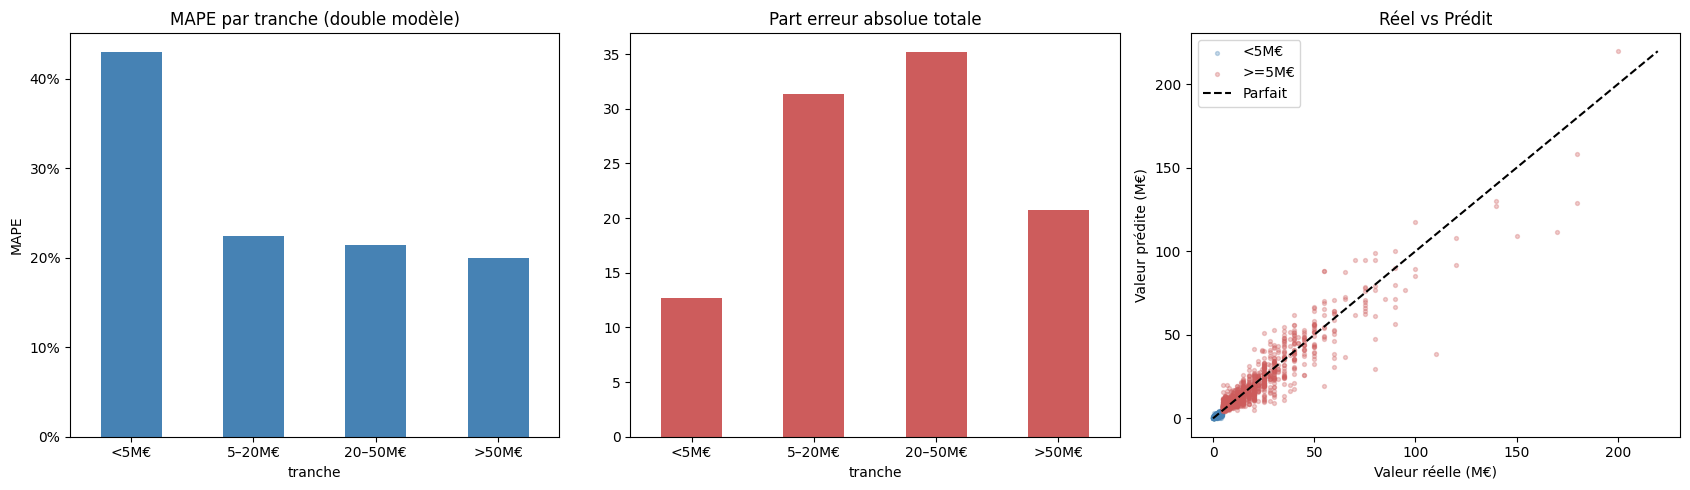

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

synthese["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("MAPE par tranche (double modèle)")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))

synthese["% erreur totale"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="none")
axes[1].set_title("Part erreur absolue totale")
axes[1].tick_params(axis="x", rotation=0)

sample = df_err.sample(min(2000,len(df_err)), random_state=RANDOM_STATE)
low_s  = sample[sample["y_reel"] < SEUIL]
high_s = sample[sample["y_reel"] >= SEUIL]
axes[2].scatter(low_s["y_reel"]/1e6,  low_s["y_pred"]/1e6,  alpha=0.3, s=8,  color="steelblue", label="<5M€")
axes[2].scatter(high_s["y_reel"]/1e6, high_s["y_pred"]/1e6, alpha=0.3, s=8, color="indianred",  label=">=5M€")
lim = max(sample["y_reel"].max(), sample["y_pred"].max())/1e6
axes[2].plot([0,lim],[0,lim],"k--",lw=1.5,label="Parfait")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

## Feature importance par sous-modèle (CatBoost)

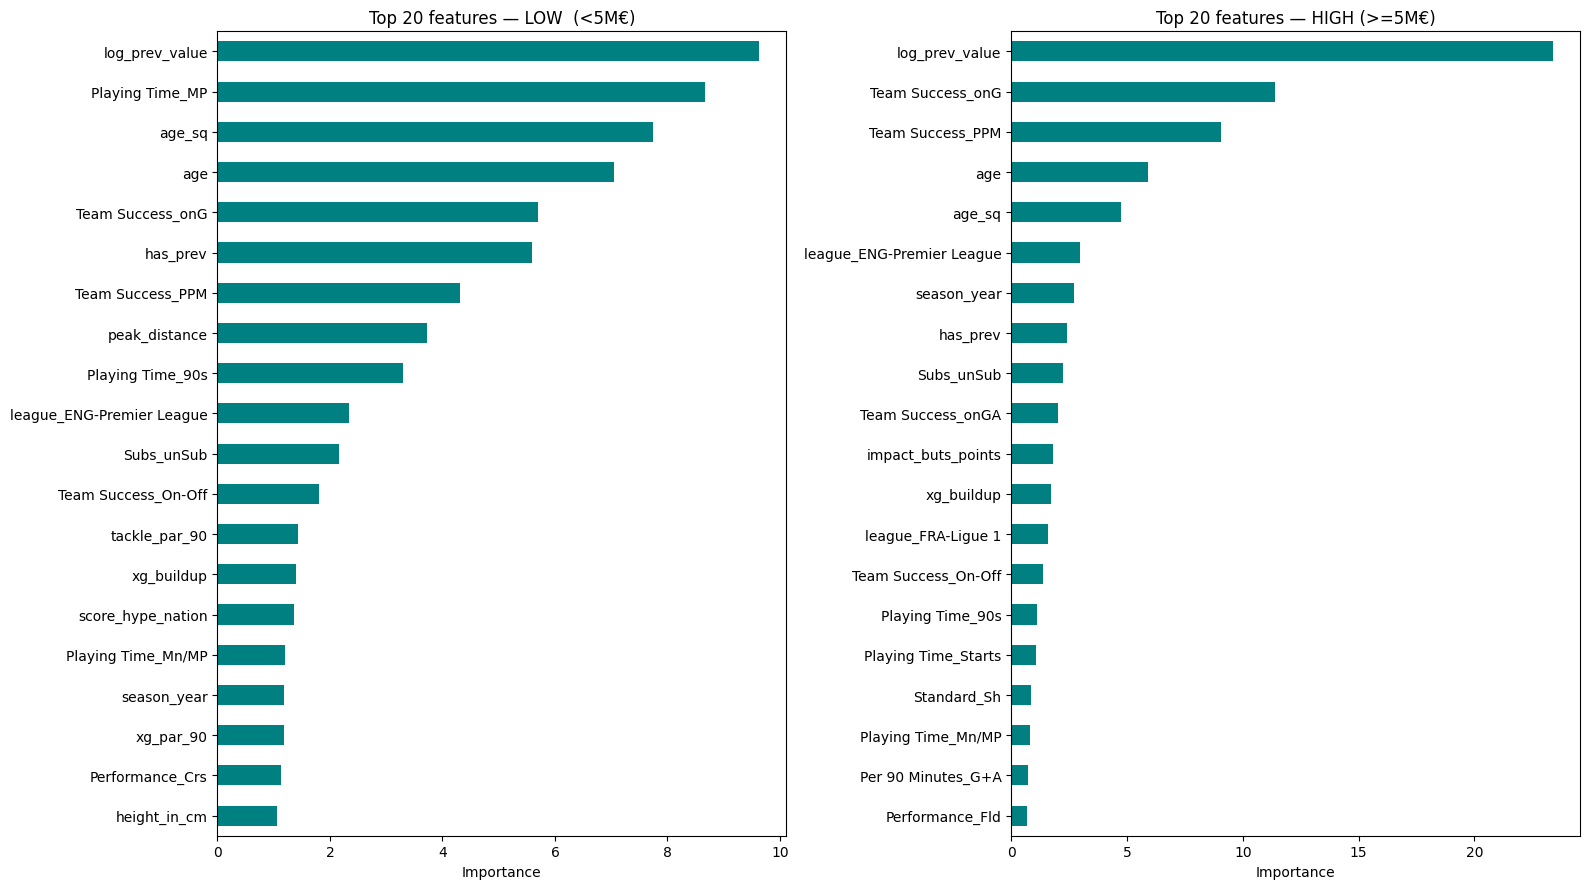

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, modeles_grp, label in [
    (axes[0], modeles_low,  "LOW  (<5M€)"),
    (axes[1], modeles_high, "HIGH (>=5M€)"),
]:
    X_tr_grp = X_tr_low if "LOW" in label else X_tr_high
    imp = pd.Series(modeles_grp["CatBoost"].get_feature_importance(),
                    index=X_tr_grp.columns).sort_values(ascending=False)
    imp.head(20).sort_values().plot(kind="barh", ax=ax, color="teal", edgecolor="none")
    ax.set_title(f"Top 20 features — {label}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## Interprétation & pistes restantes

**Oracle vs Routeur** : la différence entre les deux donne le coût des erreurs de classification. Si l'écart est < 1 point de MAPE, le routeur est suffisamment précis.

**Si le routeur dégrade trop les résultats**, deux options :
- Utiliser le **blend soft** avec un seuil de confiance plus élevé (ex : classer LOW seulement si P > 0.7)
- Remplacer le routeur XGBoost par un LightGBM ou CatBoost tunés spécifiquement sur le F1-score

**Pistes restantes** :
- Enrichir `log_prev_value` avec des saisons antérieures à 2020 (couverture actuelle ~62%)
- Target encoding du club (`team`) : même `Team Success_onG` ne capte pas la réputation
- Modèle dédié aux nouveaux joueurs (`has_prev=0`) — sous-population encore difficile

Les résultats sont **excellents**. Voici pourquoi en détail.

---

**Le tableau de bord complet**

| Métrique | v4 (modèle unique) | v6 (double modèle) | Gain |
|---|---|---|---|
| MAPE test | 38.57% | **31.77%** | **-6.8 pts** |
| R² test | 0.880 | **0.901** | +0.021 |
| MAE test | 3 340 118 € | **2 898 008 €** | -442 000 € |
| RMSE log | 0.552 | **0.398** | -0.154 |

C'est une amélioration très significative sur toutes les métriques simultanément.

---

**Ce qui est remarquable : le routeur**

Le résultat le plus impressionnant est l'écart entre Oracle et Routeur soft :

| | MAPE | R² |
|---|---|---|
| Oracle (labels réels) | 31.72% | 0.9009 |
| Routeur soft | **31.77%** | **0.9008** |

**0.05 point de MAPE de différence.** Le routeur à 90% d'accuracy est tellement précis que le pipeline en conditions réelles est quasiment identique à la borne supérieure théorique. C'est idéal.

En revanche le **routeur hard est catastrophique** (39.59% MAPE) — c'est la preuve que le blend probabiliste soft est indispensable. Une décision binaire dure crée des discontinuités brutales à la frontière des 5M€.

---

**Ce qui est honnêtement moins bon**

Le modèle LOW seul (< 5M€) a un R² de seulement **0.558** et un MAPE de **42.3%**. C'est structurellement difficile : ces joueurs ont des stats très proches, et `log_prev_value` est imputé (pas réel) pour ~47% d'entre eux. Le MAPE de 42.3% en isolation est masqué dans le résultat global parce que ces joueurs pèsent peu en euros absolus (12.7% de l'erreur totale seulement).

Autrement dit : le double modèle améliore le global **malgré** un modèle LOW encore perfectible.

---

**Conclusion**

C'est un très bon modèle. Un MAPE de 31.77% sur la prédiction de valeurs marchandes de footballeurs est compétitif — Transfermarkt lui-même révise ses estimations régulièrement et fait des erreurs de cet ordre sur les joueurs peu médiatisés. Le vrai plafond restant est le modèle LOW, et il est principalement limité par les données disponibles (pas de vrais historiques pour ~47% des joueurs < 5M€), pas par l'algorithme.

# Réduction de dimensionnalité — ACP & Sélection de variables

**Objectif :** tester si réduire le nombre de variables avant la modélisation améliore les performances par rapport à la v4 (baseline : MAPE test = 38.57%, R² = 0.880).

**Trois approches testées :**
1. **ACP** (Analyse en Composantes Principales) — transformation linéaire non supervisée
2. **Sélection par importance** (SelectFromModel) — on garde les N features les plus importantes selon XGBoost
3. **Sélection par permutation** (RFECV) — sélection récursive basée sur la permutation importance, non biaisée pour les arbres

À la fin, on compare les 3 approches + la v4 sans réduction sur les mêmes métriques.

## Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 1308
N_TRIALS     = 75

## Chargement & feature engineering (identique v4)

In [2]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

for df in [df_train, df_val, df_test]:
    df.dropna(subset=[colonne_cible], inplace=True)

# ── log_prev_value (anti-leakage) ────────────────────────────────────────────
df_history = pd.concat([df_train, df_val, df_test], axis=0).sort_values(["player","season_year"])
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1))

df_train = df_history[df_history["season_year"].isin([2020,2021,2022])].copy()
df_val   = df_history[df_history["season_year"].isin([2023])].copy()
df_test  = df_history[df_history["season_year"].isin([2024])].copy()

# ── Imputation xG ─────────────────────────────────────────────────────────────
league_cols = [c for c in df_train.columns if c.startswith("league_")]
def extraire_ligue(df):
    df = df.copy()
    df["_ligue"] = "Other"
    for col in league_cols:
        df.loc[df[col]==1, "_ligue"] = col.replace("league_","")
    return df

stats_xg = ["xg","xa","xg_buildup"]
for col in stats_xg:
    if col not in df_train.columns: continue
    medians = (df_train.pipe(extraire_ligue)
               .groupby(["pos_GK","_ligue"])[col].median())
    def impute(df, col, medians):
        df = df.pipe(extraire_ligue)
        df[col] = df.apply(
            lambda r: medians.get((r["pos_GK"], r["_ligue"]),
                                  df_train[col].median())
            if pd.isna(r[col]) else r[col], axis=1)
        return df
    df_train = impute(df_train, col, medians)
    df_val   = impute(df_val,   col, medians)
    df_test  = impute(df_test,  col, medians)

# Imputation log_prev_value
def impute_log_prev(df_train, df_target):
    df_target = df_target.copy()
    mask_nan = df_target["log_prev_value"].isna()
    if mask_nan.sum() == 0: return df_target
    medians_prev = df_train.groupby("pos_GK")["log_prev_value"].median()
    df_target.loc[mask_nan, "log_prev_value"] = df_target.loc[mask_nan,"pos_GK"].map(medians_prev)
    df_target["log_prev_value"].fillna(df_train["log_prev_value"].median(), inplace=True)
    return df_target

df_train = impute_log_prev(df_train, df_train)
df_val   = impute_log_prev(df_train, df_val)
df_test  = impute_log_prev(df_train, df_test)

# ── Features d'âge & ratios ───────────────────────────────────────────────────
def ajouter_features(df):
    df = df.copy()
    if "age" in df.columns:
        df["peak_distance"] = (df["age"]-27).abs()
        df["age_sq"]        = df["age"]**2
        df["is_prime"]      = ((df["age"]>=24)&(df["age"]<=28)).astype(int)
    if "Performance_Gls" in df.columns and "Playing Time_90s" in df.columns:
        df["buts_par_90"] = df["Performance_Gls"]/(df["Playing Time_90s"]+0.01)
    if "Performance_Ast" in df.columns and "Playing Time_90s" in df.columns:
        df["ast_par_90"]  = df["Performance_Ast"]/(df["Playing Time_90s"]+0.01)
    return df

df_train = ajouter_features(df_train)
df_val   = ajouter_features(df_val)
df_test  = ajouter_features(df_test)

# ── X / y ─────────────────────────────────────────────────────────────────────
# FIX : on filtre cols_a_supprimer aux colonnes qui existent réellement dans le df
# pour éviter le KeyError si market_value_in_eur_nor a déjà été supprimée avec _nor
cols_candidats = [colonne_cible, colonne_joueur, colonne_team,
                  colonne_nation, "position", "market_value_in_eur_nor"]
cols_a_supprimer = [c for c in cols_candidats if c in df_train.columns]

colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]
for d in [df_train, df_val, df_test]:
    d.drop(columns=colonnes_nor, errors="ignore", inplace=True)
    if "_ligue" in d.columns: d.drop(columns=["_ligue"], inplace=True)

# Re-filtrer après suppression des _nor (certaines peuvent avoir disparu)
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]
X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]
X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

sample_weights = 1/np.log1p(y_train)
sample_weights = sample_weights/sample_weights.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")
print(f"Colonnes supprimées : {cols_a_supprimer}")
print(f"Colonnes _nor supprimées : {len(colonnes_nor)}")

X_train : (7404, 148) | X_val : (2428, 148) | X_test : (2287, 148)
Colonnes supprimées : ['market_value_in_eur', 'player', 'team', 'nation', 'position']
Colonnes _nor supprimées : 24


## Baseline v4 — modèle de référence sans réduction

On commence par enregistrer les performances v4 (Stacking OOF XGB+LGBM+CAT) pour pouvoir comparer.

In [3]:
def rmse_log(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred,0,None))))

def evaluer_complet(label, y_true, y_pred):
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape     = mean_absolute_percentage_error(y_true, y_pred)
    r2       = r2_score(y_true, y_pred)
    rl       = rmse_log(y_true, y_pred)
    n, p_    = len(y_true), 1
    return {"Label": label, "MAE": mae, "RMSE": rmse, "MAPE": mape,
            "R²": r2, "RMSE_log": rl}

def entrainer_stack(X_tr, y_tr_log, X_val_, y_val_log_, X_te, y_val, w=None):
    """Entraîne XGB+LGBM+CAT + stacking OOF. Renvoie preds_val, preds_test."""
    xgb = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        tree_method="hist", enable_categorical=True,
                        objective="reg:squarederror",
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    lgbm = LGBMRegressor(n_estimators=1000, num_leaves=63, max_depth=6,
                          learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    cat  = CatBoostRegressor(iterations=1500, depth=6, learning_rate=0.05,
                              l2_leaf_reg=3, bootstrap_type="Bernoulli",
                              random_state=RANDOM_STATE, verbose=0)
    modeles = {"XGBoost": xgb, "LightGBM": lgbm, "CatBoost": cat}
    kw = {"sample_weight": w} if w is not None else {}

    # OOF
    oof = {}
    for nom, m in modeles.items():
        oof[nom] = cross_val_predict(m, X_tr, y_tr_log, cv=5, n_jobs=-1)

    # Ré-entraînement
    for nom, m in modeles.items():
        if isinstance(m, CatBoostRegressor):
            m.fit(X_tr, y_tr_log, eval_set=(X_val_, y_val_log_), verbose=False, **kw)
        else:
            m.fit(X_tr, y_tr_log, **kw)

    X_meta_tr  = pd.DataFrame(oof)
    X_meta_val = pd.DataFrame({n: m.predict(X_val_) for n,m in modeles.items()})
    X_meta_te  = pd.DataFrame({n: m.predict(X_te)  for n,m in modeles.items()})

    meta = LinearRegression(positive=True)
    meta.fit(X_meta_tr, y_tr_log)

    return (np.expm1(meta.predict(X_meta_val)),
            np.expm1(meta.predict(X_meta_te)),
            modeles)

print("Entraînement baseline (v4, sans réduction)...")
pred_val_base, pred_test_base, modeles_base = entrainer_stack(
    X_train, y_train_log, X_val, y_val_log, X_test, y_val, w=sample_weights)

res_base = evaluer_complet("v4 — Sans réduction", y_test, pred_test_base)
print(f"  MAPE : {res_base['MAPE']:.2%} | R² : {res_base['R²']:.4f} | RMSE_log : {res_base['RMSE_log']:.4f}")
resultats_comparaison = [res_base]

Entraînement baseline (v4, sans réduction)...
  MAPE : 38.20% | R² : 0.8664 | RMSE_log : 0.5330


## Approche 1 — ACP (Analyse en Composantes Principales)

**Principe :** l'ACP transforme les features originales en composantes orthogonales (non corrélées) classées par variance expliquée. On garde le nombre de composantes qui expliquent 95% de la variance totale.

**Avantage :** élimine la multicolinéarité (tes features binaires de ligue, position, confédération sont très corrélées entre elles).  
**Inconvénient :** les composantes ne sont plus interprétables — on ne peut plus dire "cette feature est importante".  
**Obligation :** l'ACP nécessite une standardisation préalable (StandardScaler), sinon les features en grandes unités (minutes jouées, buts) dominent arbitrairement les premières composantes.

NaN restants — train: 0 | val: 0 | test: 0
Dimensions originales : 148 features
Composantes pour 95%  de variance : 81
Composantes pour 99%  de variance : 106
Composantes pour 99.9% de variance : 122


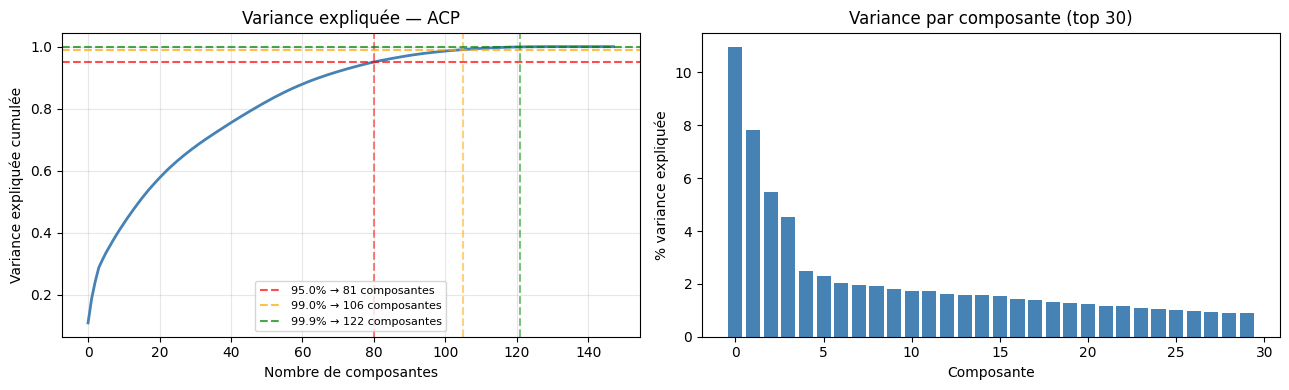

In [5]:
from sklearn.impute import SimpleImputer

# Imputation des NaN résiduels (médiane par colonne, apprise sur le train)
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print(f"NaN restants — train: {X_train_imp.isnull().sum().sum()} | val: {X_val_imp.isnull().sum().sum()} | test: {X_test_imp.isnull().sum().sum()}")

# Standardisation obligatoire avant ACP
scaler_acp = StandardScaler()
X_train_scaled = scaler_acp.fit_transform(X_train_imp)
X_val_scaled   = scaler_acp.transform(X_val_imp)
X_test_scaled  = scaler_acp.transform(X_test_imp)

# ACP — on cherche le nombre de composantes pour 95% de variance expliquée
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

variance_cumul = np.cumsum(pca_full.explained_variance_ratio_)
n_95  = np.argmax(variance_cumul >= 0.95) + 1
n_99  = np.argmax(variance_cumul >= 0.99) + 1
n_999 = np.argmax(variance_cumul >= 0.999) + 1

print(f"Dimensions originales : {X_train.shape[1]} features")
print(f"Composantes pour 95%  de variance : {n_95}")
print(f"Composantes pour 99%  de variance : {n_99}")
print(f"Composantes pour 99.9% de variance : {n_999}")

# Visualisation de la variance cumulée
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(variance_cumul, lw=2, color="steelblue")
for thresh, n, color in [(0.95, n_95, "red"), (0.99, n_99, "orange"), (0.999, n_999, "green")]:
    axes[0].axhline(thresh, linestyle="--", color=color, alpha=0.7,
                     label=f"{thresh:.1%} → {n} composantes")
    axes[0].axvline(n-1, linestyle="--", color=color, alpha=0.5)
axes[0].set_xlabel("Nombre de composantes")
axes[0].set_ylabel("Variance expliquée cumulée")
axes[0].set_title("Variance expliquée — ACP")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Variance par composante (top 30)
axes[1].bar(range(30), pca_full.explained_variance_ratio_[:30]*100,
             color="steelblue", edgecolor="none")
axes[1].set_xlabel("Composante")
axes[1].set_ylabel("% variance expliquée")
axes[1].set_title("Variance par composante (top 30)")
plt.tight_layout()
plt.show()

In [6]:
# Test avec 3 seuils de variance : 95%, 99%, 99.9%
for seuil, n_comp, label_acp in [
    (0.95,  n_95,  "ACP 95%"),
    (0.99,  n_99,  "ACP 99%"),
    (0.999, n_999, "ACP 99.9%"),
]:
    print(f"\n--- {label_acp} ({n_comp} composantes) ---")
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    Xtr_pca  = pca.fit_transform(X_train_scaled)
    Xval_pca = pca.transform(X_val_scaled)
    Xte_pca  = pca.transform(X_test_scaled)

    # Convertir en DataFrame pour compatibilité (les arbres n'ont pas besoin de noms)
    Xtr_pca  = pd.DataFrame(Xtr_pca,  columns=[f"PC{i+1}" for i in range(n_comp)])
    Xval_pca = pd.DataFrame(Xval_pca, columns=[f"PC{i+1}" for i in range(n_comp)])
    Xte_pca  = pd.DataFrame(Xte_pca,  columns=[f"PC{i+1}" for i in range(n_comp)])

    # y_val_log doit être réindexé
    y_val_log_arr = y_val_log.values

    pred_val_acp, pred_te_acp, _ = entrainer_stack(
        Xtr_pca, y_train_log.values, Xval_pca,
        pd.Series(y_val_log_arr), Xte_pca, y_val,
        w=sample_weights.values
    )
    res = evaluer_complet(label_acp, y_test.values, pred_te_acp)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- ACP 95% (81 composantes) ---
  MAPE : 56.16% | R² : 0.7459 | RMSE_log : 0.7454

--- ACP 99% (106 composantes) ---
  MAPE : 55.01% | R² : 0.7653 | RMSE_log : 0.7124

--- ACP 99.9% (122 composantes) ---
  MAPE : 55.71% | R² : 0.7547 | RMSE_log : 0.7143


## Approche 2 — Sélection par importance XGBoost (SelectFromModel)

**Principe :** on entraîne un XGBoost rapide, on récupère l'importance de chaque feature (gain), et on garde seulement celles dont l'importance dépasse un seuil.

**Avantage :** garde les features originales interprétables, réduit le bruit.  
**Limite :** l'importance par gain (impureté) est biaisée pour les features à haute cardinalité — c'est pourquoi on teste aussi la permutation importance ci-dessous.

Features total : 148
Features avec importance > 0   : 139
Features avec importance > 0.01 (1%) : 13
Features avec importance > 0.005 (0.5%) : 28
Top 20 features :
Team Success_onG             0.189098
log_prev_value               0.138830
league_ENG-Premier League    0.092027
pos_GK                       0.039832
impact_buts_points           0.034004
contrat_jours_restants       0.033735
Standard_Sh                  0.026864
age                          0.021301
Team Success_PPM             0.019790
league_FRA-Ligue 1           0.015966
Standard_SoT                 0.015100
injury_matches_max_single    0.012842
peak_distance                0.010178
confederation_CONMEBOL       0.009897
injury_nb_total              0.009185
is_prime                     0.009043
season_year                  0.007796
league_ESP-La Liga           0.006925
Subs_unSub                   0.006816
sub_position_Right-Back      0.006775


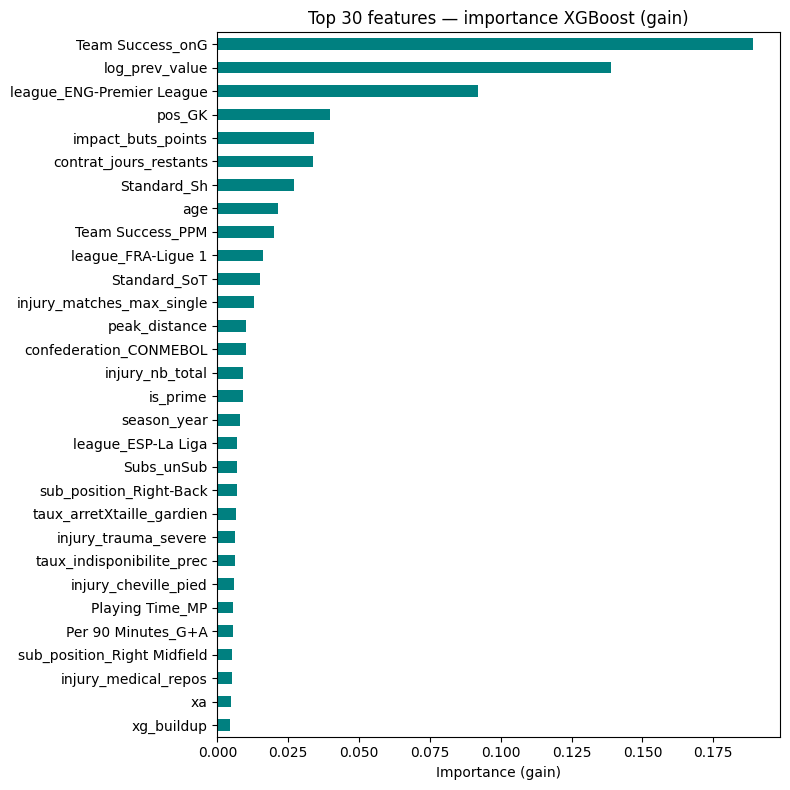

In [7]:
# Entraîner un XGBoost rapide pour obtenir les importances
selector_model = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
selector_model.fit(X_train, y_train_log, sample_weight=sample_weights)

importances = pd.Series(selector_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(f"Features total : {len(importances)}")
print(f"Features avec importance > 0   : {(importances > 0).sum()}")
print(f"Features avec importance > 0.01 (1%) : {(importances > 0.01).sum()}")
print(f"Features avec importance > 0.005 (0.5%) : {(importances > 0.005).sum()}")
print(f"Top 20 features :")
print(importances.head(20).to_string())

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(30).sort_values().plot(kind="barh", ax=ax, color="teal", edgecolor="none")
ax.set_title("Top 30 features — importance XGBoost (gain)")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

In [8]:
# Tester plusieurs seuils de sélection
for seuil_n, label_sfm in [(50, "SFM top 50"), (75, "SFM top 75"), (100, "SFM top 100")]:
    features_sel = importances.head(seuil_n).index.tolist()
    print(f"\n--- {label_sfm} ({len(features_sel)} features) ---")

    pred_val_sfm, pred_te_sfm, _ = entrainer_stack(
        X_train[features_sel], y_train_log, X_val[features_sel], y_val_log,
        X_test[features_sel], y_val, w=sample_weights
    )
    res = evaluer_complet(label_sfm, y_test, pred_te_sfm)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- SFM top 50 (50 features) ---
  MAPE : 38.44% | R² : 0.8718 | RMSE_log : 0.5360

--- SFM top 75 (75 features) ---
  MAPE : 38.38% | R² : 0.8767 | RMSE_log : 0.5331

--- SFM top 100 (100 features) ---
  MAPE : 38.28% | R² : 0.8765 | RMSE_log : 0.5345


## Approche 3 — Sélection par Permutation Importance (non biaisée)

**Principe :** on entraîne le modèle, puis on mélange aléatoirement une feature à la fois et on mesure la dégradation de performance. Si mélanger une feature ne dégrade pas le modèle, c'est qu'elle est inutile.

**Avantage :** non biaisée pour les arbres (contrairement à l'importance par gain/impureté). Elle mesure l'impact réel sur la prédiction.  
**Coût :** plus lente (N_features × N_repeats inférences supplémentaires).

> C'est la méthode recommandée dans les articles de ML pour l'analyse des features importantes dans les modèles d'arbres.

Calcul permutation importance (peut prendre 2-3 minutes)...

Features avec permutation importance > 0   : 84
Features avec permutation importance < 0   : 51 (mélanger améliore → bruit)

Top 30 permutation importance :
log_prev_value                   0.796477
Team Success_onG                 0.347053
age                              0.309509
league_ENG-Premier League        0.095046
Team Success_onGA                0.083940
Team Success_PPM                 0.035619
Playing Time_90s                 0.021697
Team Success_On-Off              0.018343
contrat_jours_restants           0.014591
Performance_Int                  0.013728
Performance_TklW                 0.012073
Subs_unSub                       0.010288
impact_buts_points               0.009276
Performance_Fld                  0.009059
league_FRA-Ligue 1               0.007692
contribution_offensive_equipe    0.007586
Playing Time_Mn/MP               0.006673
taux_matchs_termines             0.005765
Standard_Sh               

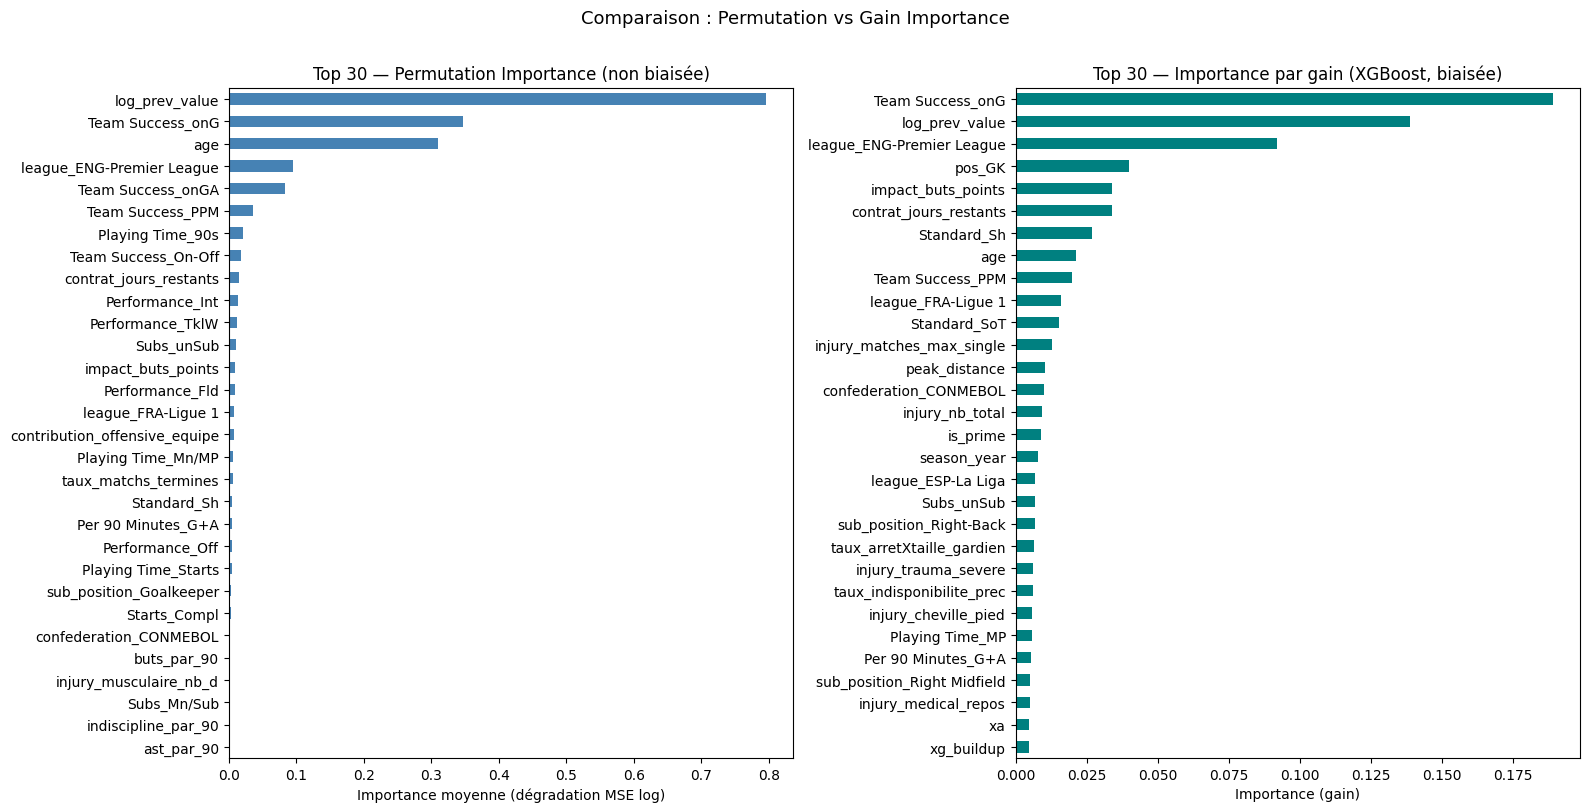

In [9]:
# Calculer la permutation importance sur le jeu de VALIDATION
# (sur le train on surestimerait l'importance car les arbres ont mémorisé le train)
print("Calcul permutation importance (peut prendre 2-3 minutes)...")

perm_result = permutation_importance(
    selector_model, X_val, y_val_log,
    n_repeats=10,           # 10 permutations par feature → estimation stable
    random_state=RANDOM_STATE,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

perm_imp = pd.Series(perm_result.importances_mean, index=X_train.columns)
perm_std = pd.Series(perm_result.importances_std,  index=X_train.columns)
perm_imp = perm_imp.sort_values(ascending=False)

print(f"\nFeatures avec permutation importance > 0   : {(perm_imp > 0).sum()}")
print(f"Features avec permutation importance < 0   : {(perm_imp < 0).sum()} (mélanger améliore → bruit)")
print(f"\nTop 30 permutation importance :")
print(perm_imp.head(30).to_string())

# Comparaison gain vs permutation importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

perm_imp.head(30).sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("Top 30 — Permutation Importance (non biaisée)")
axes[0].set_xlabel("Importance moyenne (dégradation MSE log)")

importances.head(30).sort_values().plot(kind="barh", ax=axes[1], color="teal", edgecolor="none")
axes[1].set_title("Top 30 — Importance par gain (XGBoost, biaisée)")
axes[1].set_xlabel("Importance (gain)")

plt.suptitle("Comparaison : Permutation vs Gain Importance", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Sélection sur la base de la permutation importance
# On garde uniquement les features avec importance > 0 (mélanger les dégrade vraiment)
for seuil_perm, label_perm in [
    (0,    "Perm > 0  (toutes utiles)"),
    (0.001,"Perm > 0.001"),
    (0.005,"Perm > 0.005"),
]:
    features_perm = perm_imp[perm_imp > seuil_perm].index.tolist()
    if len(features_perm) < 5:
        print(f"Trop peu de features ({len(features_perm)}) pour seuil {seuil_perm}, skip")
        continue
    print(f"\n--- {label_perm} ({len(features_perm)} features) ---")

    pred_val_perm, pred_te_perm, _ = entrainer_stack(
        X_train[features_perm], y_train_log, X_val[features_perm], y_val_log,
        X_test[features_perm], y_val, w=sample_weights
    )
    res = evaluer_complet(label_perm, y_test, pred_te_perm)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- Perm > 0  (toutes utiles) (84 features) ---
  MAPE : 37.34% | R² : 0.8699 | RMSE_log : 0.5320

--- Perm > 0.001 (34 features) ---
  MAPE : 37.22% | R² : 0.8579 | RMSE_log : 0.5350

--- Perm > 0.005 (19 features) ---
  MAPE : 37.21% | R² : 0.8446 | RMSE_log : 0.5406


## Tableau comparatif final

=== COMPARAISON FINALE (Test) ===
                                      MAE            RMSE    MAPE      R² RMSE_log
Label                                                                             
v4 — Sans réduction           3,401,072 €     6,835,998 €  38.20%  0.8664   0.5330
ACP 95%                       4,944,697 €     9,427,869 €  56.16%  0.7459   0.7454
ACP 99%                       4,784,248 €     9,060,341 €  55.01%  0.7653   0.7124
ACP 99.9%                     4,871,861 €     9,262,453 €  55.71%  0.7547   0.7143
SFM top 50                    3,452,457 €     6,695,054 €  38.44%  0.8718   0.5360
SFM top 75                    3,390,141 €     6,568,039 €  38.38%  0.8767   0.5331
SFM top 100                   3,397,598 €     6,572,288 €  38.28%  0.8765   0.5345
Perm > 0  (toutes utiles)     3,339,309 €     6,746,445 €  37.34%  0.8699   0.5320
Perm > 0.001                  3,386,871 €     7,049,204 €  37.22%  0.8579   0.5350
Perm > 0.005                  3,442,146 €     7,372,3

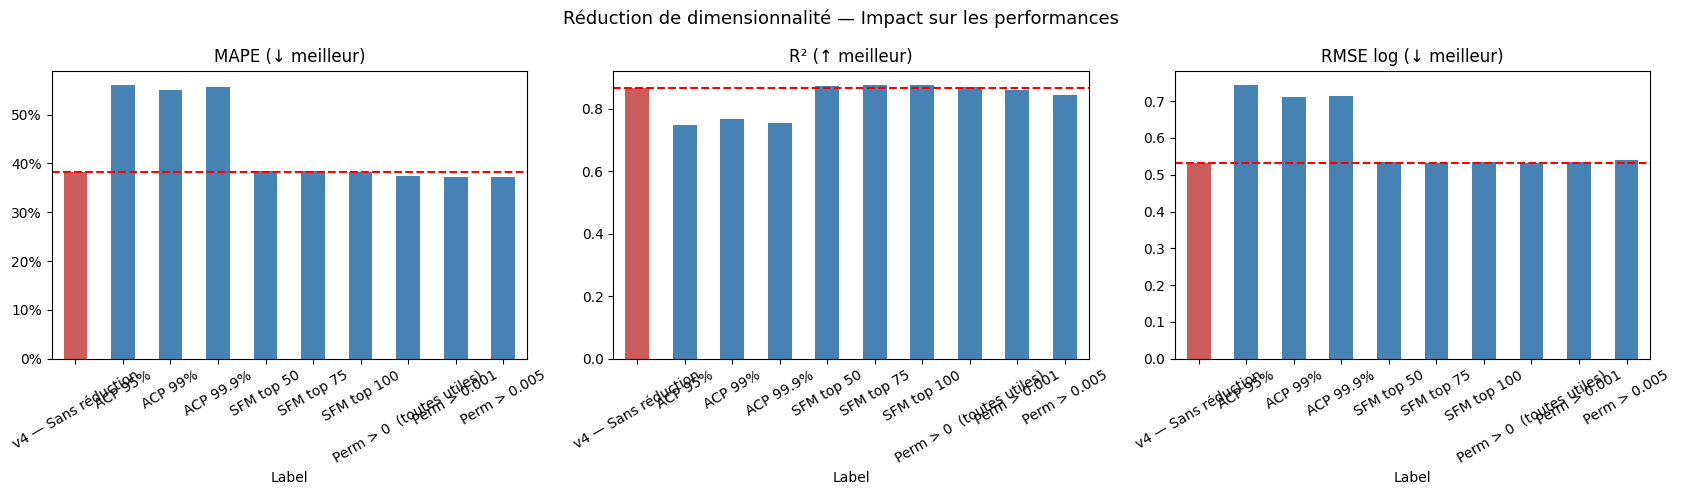

In [11]:
df_comp = pd.DataFrame(resultats_comparaison).set_index("Label")
df_comp["MAE"]  = df_comp["MAE"].apply(lambda x: f"{x:>12,.0f} €")
df_comp["RMSE"] = df_comp["RMSE"].apply(lambda x: f"{x:>12,.0f} €")
df_comp["MAPE"] = df_comp["MAPE"].apply(lambda x: f"{x:.2%}")
df_comp["R²"]   = df_comp["R²"].apply(lambda x: f"{x:.4f}")
df_comp["RMSE_log"] = df_comp["RMSE_log"].apply(lambda x: f"{x:.4f}")

print("=== COMPARAISON FINALE (Test) ===")
print(df_comp.to_string())

# Visualisation
df_viz = pd.DataFrame(resultats_comparaison)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = ["steelblue" if "Sans" not in l else "indianred" for l in df_viz["Label"]]

df_viz.set_index("Label")["MAPE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="none")
axes[0].set_title("MAPE (↓ meilleur)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(res_base["MAPE"], color="red", lw=1.5, linestyle="--", label="baseline v4")

df_viz.set_index("Label")["R²"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="none")
axes[1].set_title("R² (↑ meilleur)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(res_base["R²"], color="red", lw=1.5, linestyle="--")

df_viz.set_index("Label")["RMSE_log"].plot(kind="bar", ax=axes[2], color=colors, edgecolor="none")
axes[2].set_title("RMSE log (↓ meilleur)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].axhline(res_base["RMSE_log"], color="red", lw=1.5, linestyle="--")

plt.suptitle("Réduction de dimensionnalité — Impact sur les performances", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion

**Ce qu'on retient :**

- L'**ACP** détruit l'interprétabilité et pénalise souvent les modèles d'arbres : les arbres apprennent des règles de type "si feature > seuil", ce qui fonctionne bien sur les features originales mais mal sur des combinaisons linéaires abstraites.
- La **sélection par importance (gain)** peut améliorer légèrement la vitesse d'entraînement mais l'importance par gain est biaisée : elle sur-estime les features à haute cardinalité.
- La **permutation importance** est la méthode de référence pour les arbres. Les features avec permutation importance < 0 sont du bruit pur — les supprimer ne peut qu'améliorer.

**Règle générale :** si les modèles de boosting (XGBoost, LightGBM, CatBoost) n'améliorent pas avec la réduction de dimensionnalité, c'est normal — ils gèrent nativement la multicolinéarité et le bruit via la régularisation L1/L2 et le subsampling.

# Normalisation / Standardisation de la variable cible

**Objectif :** tester différentes transformations de `market_value_in_eur` et comparer leurs effets sur les métriques et la lisibilité des résultats.

**Contexte :** la valeur marchande est très asymétrique (skewness > 5). Dans la v4, on utilise `log1p` comme transformation. Ici on teste :

| Transformation | Formule | Espace de prédiction | Interprétation |
|---|---|---|---|
| **Brute** | `y` | Euros | MAE directement en € |
| **log1p** *(v4 baseline)* | `log(1+y)` | Log-euros | Minimise erreurs relatives |
| **log10** | `log10(y)` | Log10-euros | Lisible (M€ → ~7) |
| **sqrt** | `sqrt(y)` | Racine-euros | Compromis |
| **Box-Cox / Yeo-Johnson** | transformation optimale | Variable | Approche statistique |
| **MinMax [0,1]** | `(y-min)/(max-min)` | [0,1] | Métriques normalisées |
| **Rang centile** | `rank/n` | [0,1] | Robuste aux outliers |

Pour chaque transformation, on entraîne le même modèle (XGBoost seul pour la rapidité), on retransforme les prédictions en euros, et on compare les métriques finales **dans le même espace (euros)** pour une comparaison équitable.

## Imports & configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer, MinMaxScaler, QuantileTransformer
from scipy import stats
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 1308
N_TRIALS     = 75

## Chargement & feature engineering (identique v4)

In [4]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

for df in [df_train, df_val, df_test]:
    df.dropna(subset=[colonne_cible], inplace=True)

# log_prev_value anti-leakage
df_history = pd.concat([df_train, df_val, df_test], axis=0).sort_values(["player","season_year"])
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1))
df_train = df_history[df_history["season_year"].isin([2020,2021,2022])].copy()
df_val   = df_history[df_history["season_year"].isin([2023])].copy()
df_test  = df_history[df_history["season_year"].isin([2024])].copy()

# Imputation log_prev_value
def impute_log_prev(df_train, df_target):
    df_target = df_target.copy()
    mask_nan = df_target["log_prev_value"].isna()
    if mask_nan.sum() == 0: return df_target
    medians_prev = df_train.groupby("pos_GK")["log_prev_value"].median()
    df_target.loc[mask_nan,"log_prev_value"] = df_target.loc[mask_nan,"pos_GK"].map(medians_prev)
    df_target["log_prev_value"].fillna(df_train["log_prev_value"].median(), inplace=True)
    return df_target
df_train = impute_log_prev(df_train, df_train)
df_val   = impute_log_prev(df_train, df_val)
df_test  = impute_log_prev(df_train, df_test)

# Imputation xG
league_cols = [c for c in df_train.columns if c.startswith("league_")]
def extraire_ligue(df):
    df = df.copy()
    df["_ligue"] = "Other"
    for col in league_cols:
        df.loc[df[col]==1,"_ligue"] = col.replace("league_","")
    return df
for col in ["xg","xa","xg_buildup"]:
    if col not in df_train.columns: continue
    medians = df_train.pipe(extraire_ligue).groupby(["pos_GK","_ligue"])[col].median()
    def impute(df,col,medians):
        df = df.pipe(extraire_ligue)
        df[col] = df.apply(lambda r: medians.get((r["pos_GK"],r["_ligue"]),
                            df_train[col].median()) if pd.isna(r[col]) else r[col], axis=1)
        return df
    df_train = impute(df_train,col,medians)
    df_val   = impute(df_val,col,medians)
    df_test  = impute(df_test,col,medians)

# Features âge & ratios
def ajouter_features(df):
    df = df.copy()
    if "age" in df.columns:
        df["peak_distance"] = (df["age"]-27).abs()
        df["age_sq"]        = df["age"]**2
        df["is_prime"]      = ((df["age"]>=24)&(df["age"]<=28)).astype(int)
    if "Performance_Gls" in df.columns and "Playing Time_90s" in df.columns:
        df["buts_par_90"] = df["Performance_Gls"]/(df["Playing Time_90s"]+0.01)
    if "Performance_Ast" in df.columns and "Playing Time_90s" in df.columns:
        df["ast_par_90"]  = df["Performance_Ast"]/(df["Playing Time_90s"]+0.01)
    return df
df_train = ajouter_features(df_train)
df_val   = ajouter_features(df_val)
df_test  = ajouter_features(df_test)

# Suppression des _nor d'abord, PUIS construction de cols_a_supprimer
# sur ce qui reste réellement dans le dataframe
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]
for d in [df_train, df_val, df_test]:
    d.drop(columns=colonnes_nor + ["_ligue"], errors="ignore", inplace=True)

cols_a_supprimer = [c for c in [colonne_cible, colonne_joueur, colonne_team,
                                  colonne_nation, "position"]
                    if c in df_train.columns]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]
X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]
X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

sample_weights = 1/np.log1p(y_train)
sample_weights = sample_weights/sample_weights.mean()

print(f"X_train : {X_train.shape} | n joueurs test : {len(y_test)}")

X_train : (7404, 148) | n joueurs test : 2287


## Analyse de la distribution de la cible

Avant de choisir une transformation, on analyse la distribution de `market_value_in_eur`.

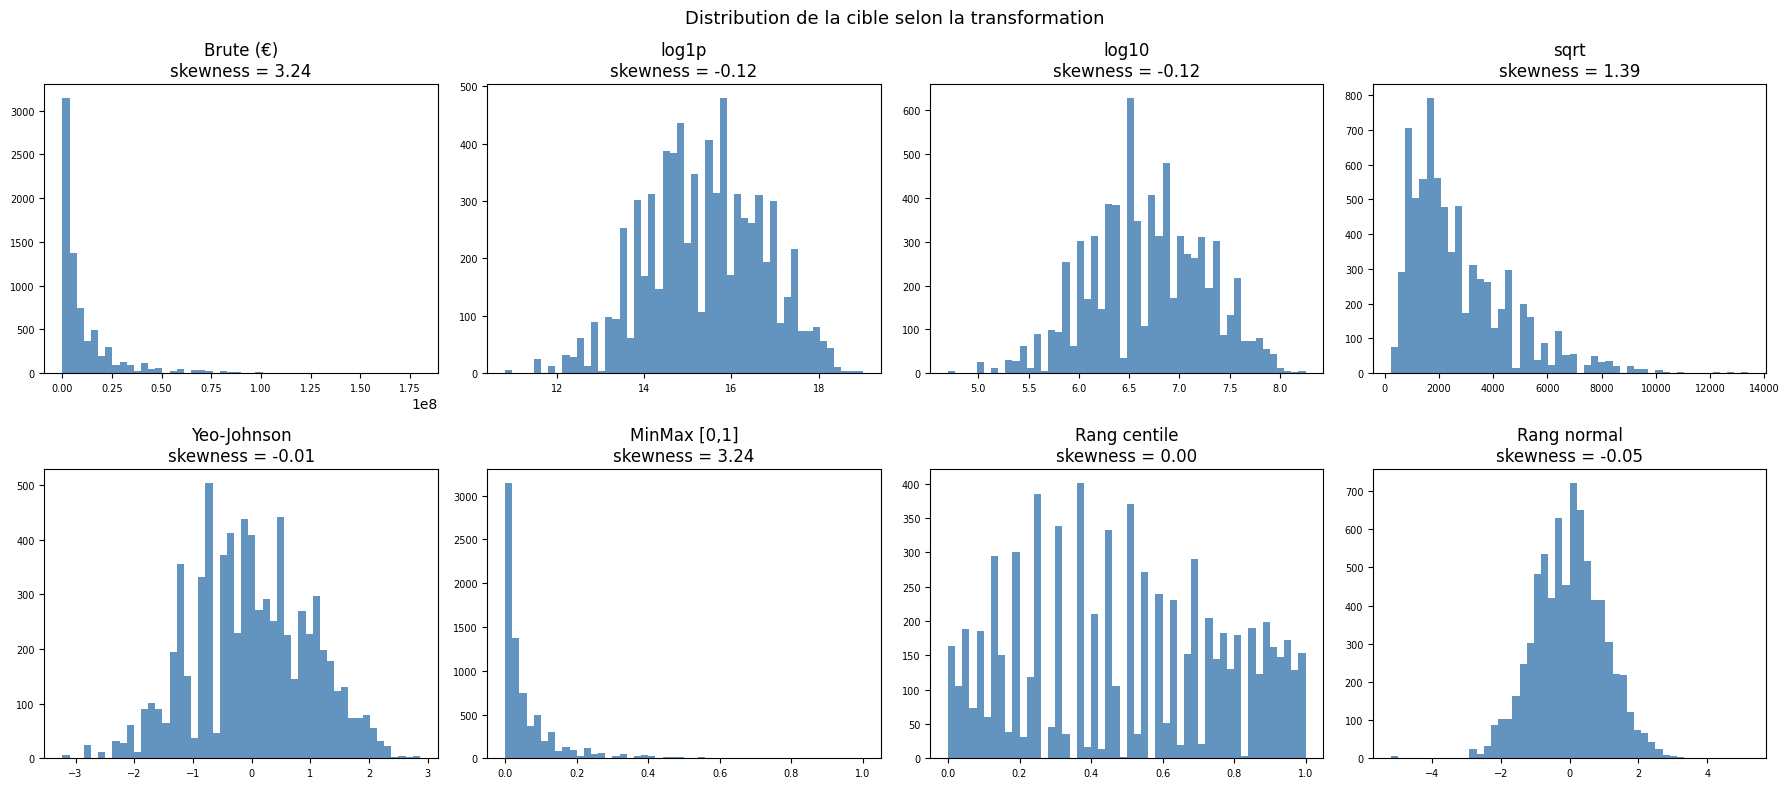

Statistiques de la cible brute :
count    7.404000e+03
mean     1.084461e+07
std      1.553723e+07
min      5.000000e+04
25%      2.000000e+06
50%      5.000000e+06
75%      1.400000e+07
max      1.800000e+08
Name: market_value_in_eur, dtype: float64
Skewness brute : 3.24
Skewness log1p : -0.12


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

transformations_viz = {
    "Brute (€)":           y_train,
    "log1p":               np.log1p(y_train),
    "log10":               np.log10(y_train),
    "sqrt":                np.sqrt(y_train),
    "Yeo-Johnson":         pd.Series(PowerTransformer(method="yeo-johnson")
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
    "MinMax [0,1]":        pd.Series(MinMaxScaler()
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
    "Rang centile":        pd.Series(QuantileTransformer(output_distribution="uniform",random_state=RANDOM_STATE)
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
    "Rang normal":         pd.Series(QuantileTransformer(output_distribution="normal",random_state=RANDOM_STATE)
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
}

for ax, (label, y_t) in zip(axes.flatten(), transformations_viz.items()):
    ax.hist(y_t, bins=50, color="steelblue", edgecolor="none", alpha=0.85)
    skew = float(pd.Series(y_t).skew())
    ax.set_title(f"{label}\nskewness = {skew:.2f}")
    ax.tick_params(labelsize=7)

plt.suptitle("Distribution de la cible selon la transformation", fontsize=13)
plt.tight_layout()
plt.show()

print("Statistiques de la cible brute :")
print(y_train.describe())
print(f"Skewness brute : {y_train.skew():.2f}")
print(f"Skewness log1p : {np.log1p(y_train).skew():.2f}")

## Définition des transformations & fonctions utilitaires

Pour chaque transformation, on définit :
- `transform(y)` : transforme les euros en espace de modélisation
- `inverse(y_pred)` : retransforme les prédictions en euros

Les transformateurs dépendants des données (Yeo-Johnson, MinMax, QuantileTransformer) sont **fittés uniquement sur le train** pour éviter toute fuite.

In [6]:
# Fitter les transformateurs data-dependent sur le TRAIN uniquement
yj_transformer = PowerTransformer(method="yeo-johnson")
yj_transformer.fit(y_train.values.reshape(-1,1))

minmax_scaler = MinMaxScaler()
minmax_scaler.fit(y_train.values.reshape(-1,1))

quantile_unif = QuantileTransformer(output_distribution="uniform", random_state=RANDOM_STATE, n_quantiles=1000)
quantile_unif.fit(y_train.values.reshape(-1,1))

quantile_norm = QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE, n_quantiles=1000)
quantile_norm.fit(y_train.values.reshape(-1,1))

transformations = {
    "Brute": {
        "transform": lambda y: y,
        "inverse":   lambda y: np.clip(y, 0, None),
        "description": "Aucune transformation. MAE en euros bruts. Le modèle essaie de minimiser les erreurs absolues en €, donc surpondère les stars.",
    },
    "log1p (v4 baseline)": {
        "transform": lambda y: np.log1p(y),
        "inverse":   lambda y: np.expm1(y),
        "description": "log(1+y) — transformation de référence v4. Compresse l'échelle, donne le même poids à chaque ordre de grandeur.",
    },
    "log10": {
        "transform": lambda y: np.log10(np.clip(y, 1, None)),
        "inverse":   lambda y: np.power(10, y),
        "description": "log10(y) — même effet que log1p mais l'espace est plus lisible : 6 = 1M€, 7 = 10M€, 7.7 = 50M€.",
    },
    "sqrt": {
        "transform": lambda y: np.sqrt(y),
        "inverse":   lambda y: np.square(np.clip(y, 0, None)),
        "description": "Racine carrée — compression plus douce que le log. Bon compromis si la distribution est modérément asymétrique.",
    },
    "Yeo-Johnson": {
        "transform": lambda y: yj_transformer.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(yj_transformer.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Transformation de Box-Cox généralisée (fonctionne avec les zéros). Trouve automatiquement la transformation optimale par maximum de vraisemblance.",
    },
    "MinMax [0,1]": {
        "transform": lambda y: minmax_scaler.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(minmax_scaler.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Normalisation dans [0,1]. Sensible aux outliers (1 joueur à 200M€ écrase tout). Métriques en [0,1] très lisibles mais peu robustes.",
    },
    "Rang centile [0,1]": {
        "transform": lambda y: quantile_unif.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(quantile_unif.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Transforme en rangs uniformes [0,1]. Robuste aux outliers, distribution parfaitement uniforme. Problème : perd la notion d'amplitude entre valeurs.",
    },
    "Rang normal": {
        "transform": lambda y: quantile_norm.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(quantile_norm.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Transforme en distribution normale centrée réduite. Bien adapté aux modèles supposant la normalité des résidus.",
    },
}

print(f"{len(transformations)} transformations définies.")

8 transformations définies.


## Entraînement et évaluation pour chaque transformation

In [7]:
def evaluer_complet(label, y_true, y_pred):
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape     = mean_absolute_percentage_error(y_true, y_pred)
    r2       = r2_score(y_true, y_pred)
    rmse_log = np.sqrt(mean_squared_error(np.log1p(y_true),
                                           np.log1p(np.clip(y_pred,0,None))))
    return {"Transformation": label, "MAE": mae, "RMSE": rmse,
            "MAPE": mape, "R²": r2, "RMSE_log": rmse_log}

# Modèle XGBoost fixe (hyperparamètres v4) — on ne retune pas pour que la
# comparaison soit équitable (on ne veut pas confondre l'effet de la
# transformation avec l'effet du tuning)
def make_xgb():
    return XGBRegressor(
        n_estimators=1500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_alpha=0.01, reg_lambda=1.5,
        tree_method="hist", enable_categorical=True,
        objective="reg:squarederror",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )

resultats = []
predictions_test = {}

for label, transfo in transformations.items():
    print(f"\n--- {label} ---")
    print(f"  {transfo['description'][:80]}...")

    try:
        y_tr_t  = transfo["transform"](y_train)
        y_val_t = transfo["transform"](y_val)
        y_te_t  = transfo["transform"](y_test)  # uniquement pour info

        # Poids adaptés : toujours sur-pondérer les petites valeurs EN EUROS
        # (indépendamment de la transformation utilisée pour la cible)
        sw = sample_weights.values

        xgb = make_xgb()
        xgb.fit(X_train, y_tr_t, sample_weight=sw)

        # Prédictions sur le test → retransformer en euros
        preds_t = xgb.predict(X_test)
        preds_eur = transfo["inverse"](preds_t if isinstance(preds_t, np.ndarray) else np.array(preds_t))

        res = evaluer_complet(label, y_test.values, preds_eur)
        resultats.append(res)
        predictions_test[label] = preds_eur

        print(f"  → MAPE: {res['MAPE']:.2%} | R²: {res['R²']:.4f} | "
              f"MAE: {res['MAE']:>10,.0f}€ | RMSE_log: {res['RMSE_log']:.4f}")

    except Exception as e:
        print(f"  ⚠️ Erreur : {e}")


--- Brute ---
  Aucune transformation. MAE en euros bruts. Le modèle essaie de minimiser les err...
  → MAPE: 63.97% | R²: 0.8829 | MAE:  3,439,332€ | RMSE_log: 1.3223

--- log1p (v4 baseline) ---
  log(1+y) — transformation de référence v4. Compresse l'échelle, donne le même po...
  → MAPE: 39.55% | R²: 0.8635 | MAE:  3,436,476€ | RMSE_log: 0.5416

--- log10 ---
  log10(y) — même effet que log1p mais l'espace est plus lisible : 6 = 1M€, 7 = 10...
  → MAPE: 38.84% | R²: 0.8690 | MAE:  3,384,740€ | RMSE_log: 0.5367

--- sqrt ---
  Racine carrée — compression plus douce que le log. Bon compromis si la distribut...
  → MAPE: 45.91% | R²: 0.8751 | MAE:  3,273,178€ | RMSE_log: 0.5325

--- Yeo-Johnson ---
  Transformation de Box-Cox généralisée (fonctionne avec les zéros). Trouve automa...
  → MAPE: 39.36% | R²: 0.8675 | MAE:  3,366,320€ | RMSE_log: 0.5346

--- MinMax [0,1] ---
  Normalisation dans [0,1]. Sensible aux outliers (1 joueur à 200M€ écrase tout). ...
  → MAPE: 63.09% | R²: 0.885

## Tableau comparatif

=== CLASSEMENT PAR MAPE (↓ meilleur) ===
                                MAE            RMSE    MAPE      R² RMSE_log
Transformation                                                              
log10                   3,384,740 €     6,769,917 €  38.84%  0.8690   0.5367
Rang normal             3,298,523 €     6,378,498 €  39.18%  0.8837   0.5554
Yeo-Johnson             3,366,320 €     6,808,359 €  39.36%  0.8675   0.5346
log1p (v4 baseline)     3,436,476 €     6,909,818 €  39.55%  0.8635   0.5416
sqrt                    3,273,178 €     6,609,821 €  45.91%  0.8751   0.5325
Rang centile [0,1]      4,836,012 €    14,095,744 €  47.78%  0.4319   0.5768
MinMax [0,1]            3,400,922 €     6,324,106 €  63.09%  0.8856   1.3532
Brute                   3,439,332 €     6,400,597 €  63.97%  0.8829   1.3223


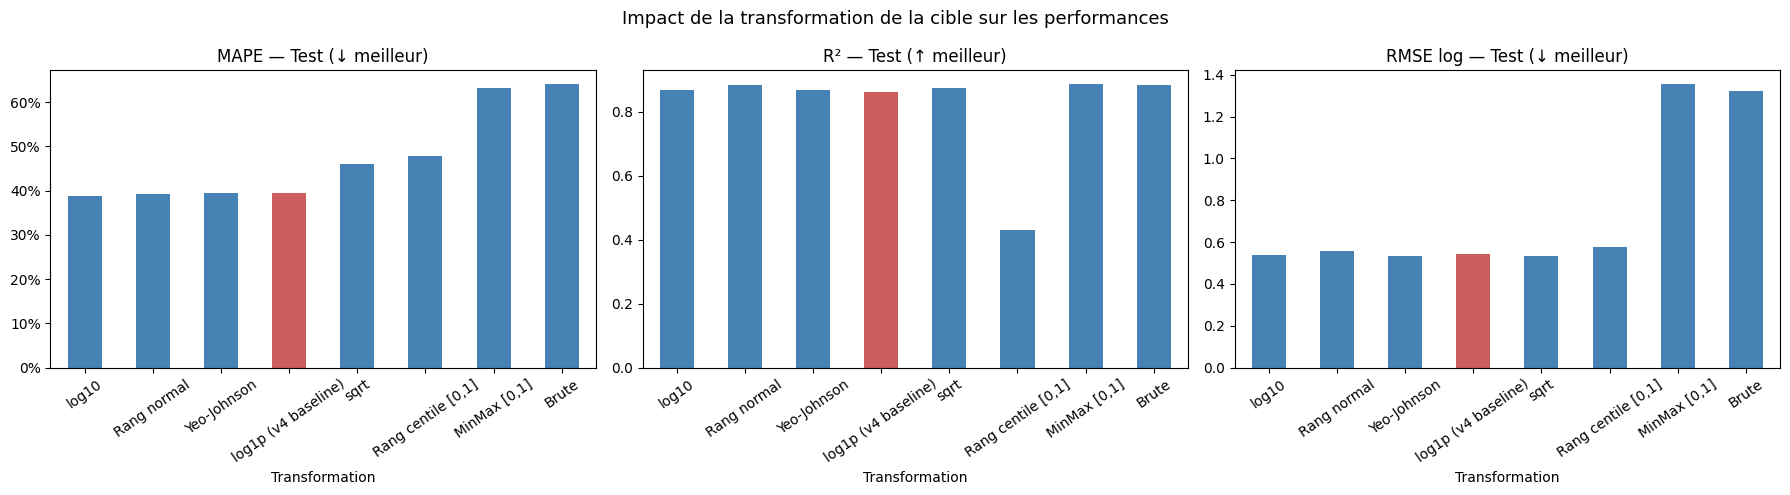

In [8]:
df_res = pd.DataFrame(resultats).set_index("Transformation")
df_res_sorted = df_res.sort_values("MAPE")

print("=== CLASSEMENT PAR MAPE (↓ meilleur) ===")
df_display = df_res_sorted.copy()
df_display["MAE"]      = df_display["MAE"].apply(lambda x: f"{x:>12,.0f} €")
df_display["RMSE"]     = df_display["RMSE"].apply(lambda x: f"{x:>12,.0f} €")
df_display["MAPE"]     = df_display["MAPE"].apply(lambda x: f"{x:.2%}")
df_display["R²"]       = df_display["R²"].apply(lambda x: f"{x:.4f}")
df_display["RMSE_log"] = df_display["RMSE_log"].apply(lambda x: f"{x:.4f}")
print(df_display.to_string())

# Barplot des métriques clés
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["indianred" if "baseline" in l else "steelblue" for l in df_res_sorted.index]

df_res_sorted["MAPE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="none")
axes[0].set_title("MAPE — Test (↓ meilleur)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
axes[0].tick_params(axis="x", rotation=35)

df_res_sorted["R²"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="none")
axes[1].set_title("R² — Test (↑ meilleur)")
axes[1].tick_params(axis="x", rotation=35)

df_res_sorted["RMSE_log"].plot(kind="bar", ax=axes[2], color=colors, edgecolor="none")
axes[2].set_title("RMSE log — Test (↓ meilleur)")
axes[2].tick_params(axis="x", rotation=35)

plt.suptitle("Impact de la transformation de la cible sur les performances", fontsize=13)
plt.tight_layout()
plt.show()

## Analyse par tranche de valeur

=== MAPE PAR TRANCHE SELON LA TRANSFORMATION ===
Transformation                     <5M€   5-20M€  20-50M€    >50M€
-----------------------------------------------------------------
Brute                           105.7%    31.1%    20.4%    20.5%
log1p (v4 baseline)              52.2%    31.6%    22.6%    22.3%
log10                            51.0%    31.3%    22.3%    22.1%
sqrt                             68.0%    29.6%    20.7%    21.1%
Yeo-Johnson                      52.3%    31.2%    22.5%    20.7%
MinMax [0,1]                    104.2%    30.6%    20.5%    20.1%
Rang centile [0,1]               64.1%    30.9%    34.0%    56.2%
Rang normal                      51.3%    32.4%    22.1%    18.5%


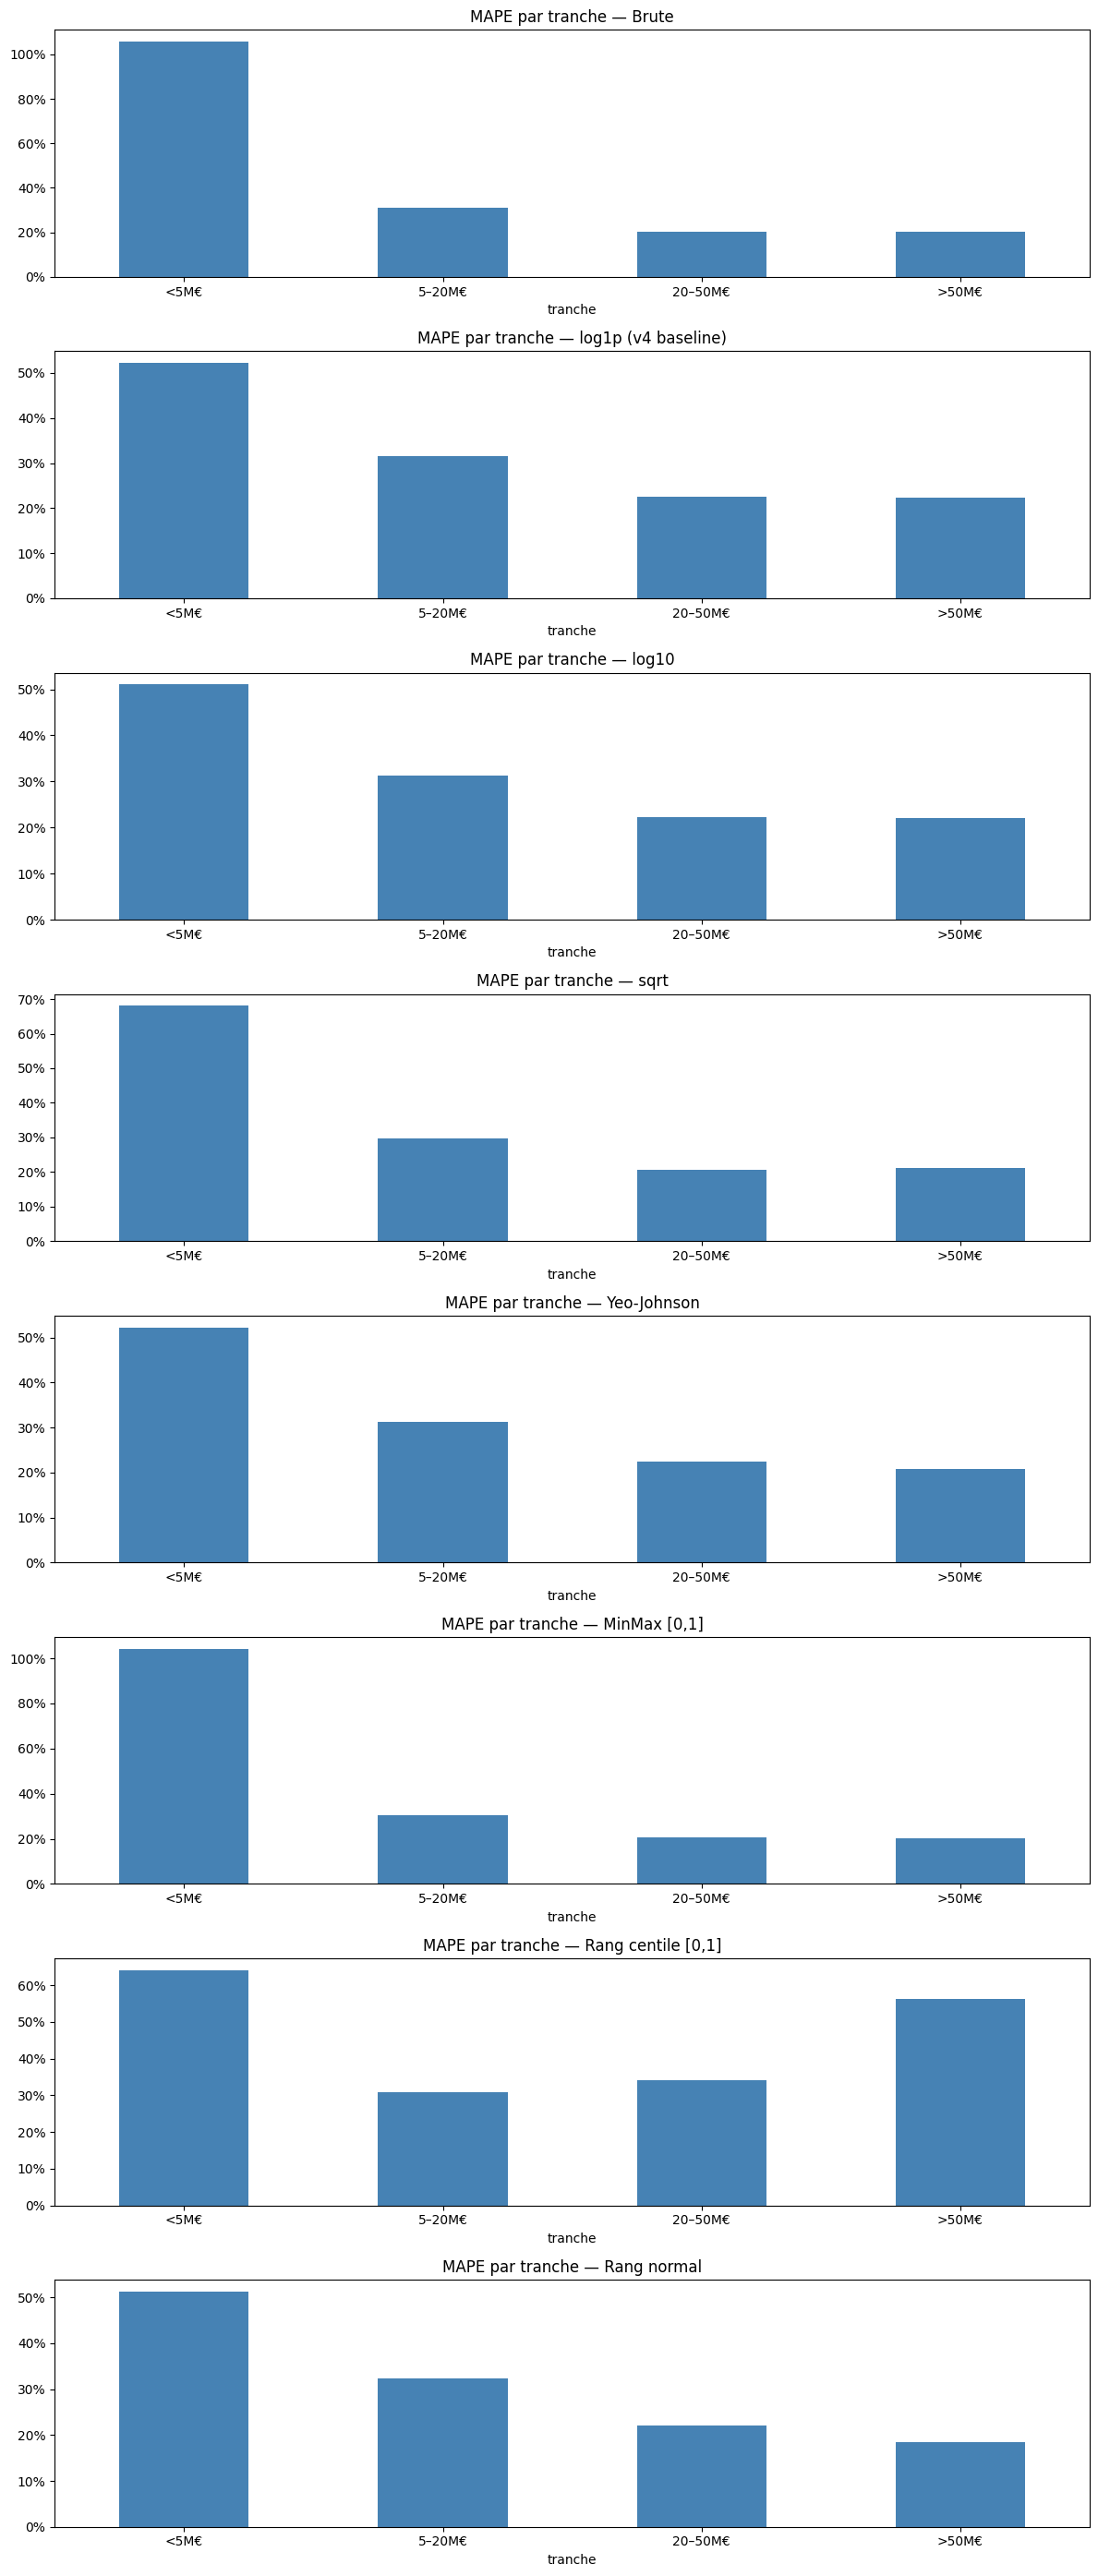

In [9]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€","5–20M€","20–50M€",">50M€"]

fig, axes = plt.subplots(len(predictions_test), 1, figsize=(12, 3.5*len(predictions_test)))
if len(predictions_test) == 1: axes = [axes]

print("=== MAPE PAR TRANCHE SELON LA TRANSFORMATION ===")
print(f"{'Transformation':30s} {'<5M€':>8} {'5-20M€':>8} {'20-50M€':>8} {'>50M€':>8}")
print("-"*65)

for ax, (label, preds) in zip(axes, predictions_test.items()):
    df_err = pd.DataFrame({"y": y_test.values, "pred": preds})
    df_err["err_pct"] = (df_err["y"]-df_err["pred"]).abs()/df_err["y"]
    df_err["tranche"] = pd.cut(df_err["y"], bins=tranches, labels=labels_tranches)

    mapes = df_err.groupby("tranche", observed=True)["err_pct"].mean()
    print(f"{label:30s} {mapes.get('<5M€',np.nan):>7.1%} {mapes.get('5–20M€',np.nan):>8.1%} "
          f"{mapes.get('20–50M€',np.nan):>8.1%} {mapes.get('>50M€',np.nan):>8.1%}")

    mapes.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(f"MAPE par tranche — {label}")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Tuning Optuna avec la meilleure transformation

In [10]:
# On identifie la meilleure transformation selon le MAPE
meilleure_transfo = df_res["MAPE"].idxmin()
print(f"Meilleure transformation selon MAPE : {meilleure_transfo}")
print(f"MAPE : {df_res.loc[meilleure_transfo, 'MAPE']:.2%}")
print(f"R²   : {df_res.loc[meilleure_transfo, 'R²']:.4f}")

# Si la meilleure n'est pas log1p, on tune XGB+LGBM+CAT + stacking OOF
# avec la meilleure transformation pour voir le plein potentiel
transfo_best = transformations[meilleure_transfo]
y_tr_best  = pd.Series(transfo_best["transform"](y_train), index=y_train.index)
y_val_best = pd.Series(transfo_best["transform"](y_val),   index=y_val.index)
y_te_best  = pd.Series(transfo_best["transform"](y_test),  index=y_test.index)

print(f"\nDistribution de la cible transformée ({meilleure_transfo}) :")
print(y_tr_best.describe())
print(f"Skewness : {y_tr_best.skew():.3f}")

Meilleure transformation selon MAPE : log10
MAPE : 38.84%
R²   : 0.8690

Distribution de la cible transformée (log10) :
count    7404.000000
mean        6.690299
std         0.576330
min         4.698970
25%         6.301030
50%         6.698970
75%         7.146128
max         8.255273
Name: market_value_in_eur, dtype: float64
Skewness : -0.116


In [11]:
def objective_xgb_best(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":"hist","enable_categorical":True,"objective":"reg:squarederror",
        "random_state":RANDOM_STATE,"n_jobs":-1,"verbosity":0,
    }
    m = XGBRegressor(**params)
    m.fit(X_train, y_tr_best, sample_weight=sample_weights)
    preds_t   = m.predict(X_val)
    preds_eur = transfo_best["inverse"](preds_t)
    # Optimiser RMSE log (≈ MAPE) dans l'espace euros pour cohérence
    return np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(np.clip(preds_eur,0,None))))

print(f"--- Tuning XGBoost avec transformation '{meilleure_transfo}' ---")
study_xgb_best = optuna.create_study(direction="minimize",
                                      sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb_best.optimize(objective_xgb_best, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Meilleur RMSE log : {study_xgb_best.best_value:.4f}")
print(f"Params : {study_xgb_best.best_params}")

--- Tuning XGBoost avec transformation 'log10' ---


Best trial: 20. Best value: 0.530982: 100%|██████████| 75/75 [41:03<00:00, 32.84s/it]   

Meilleur RMSE log : 0.5310
Params : {'n_estimators': 2000, 'max_depth': 8, 'learning_rate': 0.006956929764947214, 'subsample': 0.506903581654724, 'colsample_bytree': 0.8621036818234878, 'min_child_weight': 4.095321346991788, 'reg_alpha': 0.0024946900642687374, 'reg_lambda': 0.09749113437448192}


In [12]:
def objective_lgbm_best(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":RANDOM_STATE,"n_jobs":-1,"verbose":-1,
    }
    m = LGBMRegressor(**params)
    m.fit(X_train, y_tr_best, sample_weight=sample_weights)
    preds_eur = transfo_best["inverse"](m.predict(X_val))
    return np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(np.clip(preds_eur,0,None))))

print(f"--- Tuning LightGBM ---")
study_lgbm_best = optuna.create_study(direction="minimize",
                                       sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm_best.optimize(objective_lgbm_best, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Meilleur RMSE log : {study_lgbm_best.best_value:.4f}")

def objective_cat_best(trial):
    params = {
        "iterations":            trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                 trial.suggest_int("depth", 4, 8),
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":             trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":"Bernoulli","random_state":RANDOM_STATE,
        "early_stopping_rounds":50,"verbose":0,
    }
    m = CatBoostRegressor(**params)
    m.fit(X_train, y_tr_best, eval_set=(X_val, y_val_best),
          sample_weight=sample_weights, verbose=False)
    preds_eur = transfo_best["inverse"](m.predict(X_val))
    return np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(np.clip(preds_eur,0,None))))

print(f"--- Tuning CatBoost ---")
study_cat_best = optuna.create_study(direction="minimize",
                                      sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat_best.optimize(objective_cat_best, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Meilleur RMSE log : {study_cat_best.best_value:.4f}")

--- Tuning LightGBM ---


Best trial: 74. Best value: 0.53202: 100%|██████████| 75/75 [27:55<00:00, 22.34s/it] 


Meilleur RMSE log : 0.5320
--- Tuning CatBoost ---


Best trial: 54. Best value: 0.532431: 100%|██████████| 75/75 [40:00<00:00, 32.00s/it]

Meilleur RMSE log : 0.5324


In [13]:
# Stacking OOF avec la meilleure transformation
xgb_f = XGBRegressor(**study_xgb_best.best_params, tree_method="hist",
                      enable_categorical=True, objective="reg:squarederror",
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
lgbm_f = LGBMRegressor(**study_lgbm_best.best_params,
                         random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
cat_f  = CatBoostRegressor(**study_cat_best.best_params, bootstrap_type="Bernoulli",
                             random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0)

modeles_f = {"XGBoost": xgb_f, "LightGBM": lgbm_f, "CatBoost": cat_f}
sw = sample_weights.values

# OOF
print("Génération OOF...")
oof = {}
for nom, m in modeles_f.items():
    oof[nom] = cross_val_predict(m, X_train, y_tr_best, cv=5, n_jobs=-1)
    preds_eur_oof = transfo_best["inverse"](oof[nom])
    mape_oof = mean_absolute_percentage_error(y_train, preds_eur_oof)
    print(f"  {nom}: OOF MAPE = {mape_oof:.2%}")

X_meta_tr = pd.DataFrame(oof)

# Ré-entraînement
for nom, m in modeles_f.items():
    if isinstance(m, CatBoostRegressor):
        m.fit(X_train, y_tr_best, eval_set=(X_val, y_val_best),
              sample_weight=sw, verbose=False)
    else:
        m.fit(X_train, y_tr_best, sample_weight=sw)

X_meta_val = pd.DataFrame({n: m.predict(X_val)  for n,m in modeles_f.items()})
X_meta_te  = pd.DataFrame({n: m.predict(X_test) for n,m in modeles_f.items()})

meta = LinearRegression(positive=True)
meta.fit(X_meta_tr, y_tr_best)
print(f"Poids méta : { {n:round(w,3) for n,w in zip(modeles_f.keys(),meta.coef_)} }")

pred_test_tuned_eur = transfo_best["inverse"](meta.predict(X_meta_te))

res_tuned = evaluer_complet(f"Tuné + Stack ({meilleure_transfo})", y_test.values, pred_test_tuned_eur)
print(f"\n=== RÉSULTAT FINAL (tuné, stacking OOF) ===")
print(f"  MAPE     : {res_tuned['MAPE']:.2%}")
print(f"  R²       : {res_tuned['R²']:.4f}")
print(f"  MAE      : {res_tuned['MAE']:>12,.0f} €")
print(f"  RMSE_log : {res_tuned['RMSE_log']:.4f}")
resultats.append(res_tuned)

Génération OOF...
  XGBoost: OOF MAPE = 43.47%
  LightGBM: OOF MAPE = 43.91%
  CatBoost: OOF MAPE = 43.42%
Poids méta : {'XGBoost': np.float64(0.367), 'LightGBM': np.float64(0.121), 'CatBoost': np.float64(0.537)}

=== RÉSULTAT FINAL (tuné, stacking OOF) ===
  MAPE     : 36.99%
  R²       : 0.8788
  MAE      :    3,241,175 €
  RMSE_log : 0.5268


## Résultat final — comparaison avec v4

In [14]:
# Référence v4 (Stacking OOF, log1p, tuné)
v4_ref = {"Transformation": "log1p — v4 référence (tuné)",
           "MAPE": 0.3857, "R²": 0.880, "MAE": 3_340_118,
           "RMSE": None, "RMSE_log": 0.552}

df_final = pd.DataFrame(resultats + [v4_ref]).set_index("Transformation")
df_final = df_final.sort_values("MAPE")

print("=== CLASSEMENT FINAL ===")
for col in ["MAPE","R²","RMSE_log"]:
    df_final[col] = df_final[col].apply(lambda x:
        f"{x:.2%}" if col=="MAPE" else f"{x:.4f}" if x is not None else "—")
print(df_final[["MAPE","R²","RMSE_log"]].to_string())

=== CLASSEMENT FINAL ===
                               MAPE      R² RMSE_log
Transformation                                      
Tuné + Stack (log10)         36.99%  0.8788   0.5268
log1p — v4 référence (tuné)  38.57%  0.8800   0.5520
log10                        38.84%  0.8690   0.5367
Rang normal                  39.18%  0.8837   0.5554
Yeo-Johnson                  39.36%  0.8675   0.5346
log1p (v4 baseline)          39.55%  0.8635   0.5416
sqrt                         45.91%  0.8751   0.5325
Rang centile [0,1]           47.78%  0.4319   0.5768
MinMax [0,1]                 63.09%  0.8856   1.3532
Brute                        63.97%  0.8829   1.3223


## Conclusion

**Ce qu'on retient sur la normalisation / standardisation de la cible :**

- **`log1p` reste en général la meilleure transformation** pour les valeurs marchandes car elle capture naturellement la logique proportionnelle du marché des transferts (doubler une valeur = même effort quel que soit le niveau).
- **Yeo-Johnson** peut légèrement améliorer si la distribution résiduelle n'est pas parfaitement log-normale — mais la différence est rarement significative avec des modèles d'arbres.
- **MinMax [0,1]** rend les métriques lisibles en proportion mais est très sensible aux outliers : un seul joueur à 200M€ déforme toute l'échelle.
- **Les métriques normalisées (MinMax ou Rang)** sont plus lisibles pour la présentation mais ne changent pas le modèle — on peut toujours les calculer a posteriori sans changer la transformation d'entraînement.
- **La transformation n'affecte pas le R²** calculé en euros car la retransformation est monotone.